# Setup

## Libraries Loading

In [46]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown


# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
# make_scorer source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html
from sklearn.metrics import confusion_matrix, make_scorer, roc_auc_score,  ConfusionMatrixDisplay, classification_report, get_scorer_names
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve, GridSearchCV, train_test_split
from sklearn.feature_selection import RFE,  SequentialFeatureSelector
# clone source: https://scikit-learn.org/stable/modules/generated/sklearn.base.clone.html
from sklearn.base import clone
from sklearn.preprocessing import FunctionTransformer

# Statistics
from scipy import stats
from sklearn.preprocessing import StandardScaler

# Imblearn Oversampling
# imblearn source: https://imbalanced-learn.org/stable/over_sampling.html
from imblearn.over_sampling import SMOTENC, SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE
from imblearn.pipeline import Pipeline

# Utilitary
import src.utils.utils as ut
import src.utils.model_prep_eval as mod_prep

## Data Loading

### Wines Data

In [47]:
# Loads data from source and sets wine_id
wine_df = pd.read_csv(ut.get_project_file_path("src", "data", "transformed", "wines_clean.csv"))
wine_df = wine_df.reset_index(drop=False)
wine_df = wine_df.rename(columns={"index": "wine_id"})

### Users Data

In [48]:
# Loads and concatenates user data
users_data = pd.read_pickle(ut.get_project_file_path("src", "data", "synthetic", "simulation_13.pkl"))
users_data = users_data.dropna()
users_data.head()

,event_timestamp,user_id,wine_id,user_input,liked,prob_like
0,2022-08-27,0,1233,"{'meal': 'Chucrut con Salchichas', 'main_pairi...",1,0.834773
1,2022-09-23,0,1020,"{'meal': 'Locro', 'main_pairing': 'beef', 'pai...",0,0.466778
2,2022-10-27,0,1629,"{'meal': 'Asado', 'main_pairing': 'beef', 'pai...",1,0.856777
3,2022-11-27,0,615,"{'meal': 'Tabla de Quesos y Embutidos', 'main_...",0,0.471666
4,2022-12-20,0,771,"{'meal': 'Tarta de Vegetales y Queso', 'main_p...",0,0.415275


## Data Prep

### Joining Data

In [49]:
# Agrega la información de los usuarios al df de vinos
joined_data = pd.merge(users_data, wine_df, how="inner", on="wine_id")
joined_data.shape

(13198, 124)

### ETL

In [50]:
def taste_dist_to_optimal(x, min, max):
    if min <= x <= max:
        return 0
    elif x > max:
        return x - max
    else:
        return x - min

def price_dist_to_optimal(x, min, max, center):
    if (max == 2000):
        # Sin precio máximo: el punto óptimo es el mínimo del rango
        return x - min
    else:
        # Con precio máximo: el punto óptimo es el centro del rango
        return x - center
    

In [51]:
# Agrega si el vino tenia match con el main pairing del user
recommend_df = joined_data.copy()
recommend_df["user_main_pairing"] = recommend_df["user_input"].apply(lambda x: x["main_pairing"])
recommend_df["has_user_main_pairing"] = recommend_df.apply(lambda row: 1 if row[row["user_main_pairing"]]==1 else 0, axis=1)

# Agrega los límites inferiores y superiores de sabor según la decisión del usuario
taste_list = ["body", "tannins", "sweetness", "acidity"]
for taste in taste_list:
    recommend_df["user_" + taste + "_min"] = recommend_df["user_input"].apply(lambda x: x["tastes"][taste][0])
    recommend_df["user_" + taste + "_max"] = recommend_df["user_input"].apply(lambda x: x["tastes"][taste][1])
    recommend_df["user_" + taste + "_center"] = (recommend_df["user_" + taste + "_max"] + recommend_df["user_" + taste + "_min"])/2
    recommend_df["user_" + taste + "_range"] = (recommend_df["user_" + taste + "_max"] - recommend_df["user_" + taste + "_min"])
    recommend_df["user_" + taste + "_diff"] = recommend_df.apply(
        lambda row: taste_dist_to_optimal(
            x=row[taste],
            min=row["user_" + taste + "_min"],
            max=row["user_" + taste + "_max"]
        ),
        axis=1
    )

# Agrega los precios máximos y mínimos, rango y distancia del precio al óptimo
recommend_df["user_price_min"] = recommend_df["user_input"].apply(lambda x: x["precio_min"])
recommend_df["user_price_max"] = recommend_df["user_input"].apply(lambda x: x["precio_max"])
#recommend_df["user_no_price_max"] = pd.isna(recommend_df["user_price_max"]).astype(int)
recommend_df["user_price_max"] = recommend_df["user_price_max"].fillna(2000)
recommend_df["user_price_range"] = recommend_df["user_price_max"] - recommend_df["user_price_min"]
recommend_df["user_price_center"] = (recommend_df["user_price_max"] + recommend_df["user_price_min"])/2
recommend_df["user_price_diff"] = recommend_df.apply(
    lambda row: price_dist_to_optimal(
        x=row["price"],
        min=row["user_price_min"],
        max=row["user_price_max"],
        center=row["user_price_center"]
    ),
    axis=1
)

pd.set_option("display.max_columns", None)
recommend_df.head()

,event_timestamp,user_id,wine_id,user_input,liked,prob_like,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,sweetness,acidity,style,alcohol,image,ageing,black fruit,citrus,dried fruit,earthy,floral,oaky,red fruit,spices,tree fruit,tropical,vegetal,yeasty,any junk food will do,aperitif,appetizers and snacks,beef,blue cheese,cured meat,"game (deer, venison)",goat's milk cheese,lamb,lean fish,mature and hard cheese,mild and soft cheese,mushrooms,pasta,pork,poultry,"rich fish (salmon, tuna etc)",shellfish,spicy food,veal,vegetarian,Albariño,Barbera,Bonarda,Béquignol Noir,Cabernet Franc,Cabernet Sauvignon,Cereza,Chardonnay,Chenin Blanc,Criolla Grande,Garnacha,Gewürztraminer,Grenache,Grüner Veltliner,Malbec,Malvasia,Marsanne,Mencia,Merlot,Moscatel,Mourvedre,Pais,Pedro Ximenez,Petit Verdot,Pinot Gris,Pinot Noir,Riesling,Roussanne,Sangiovese,Sauvignon Blanc,Shiraz/Syrah,Sémillon,Tannat,Tempranillo,Torrontés,Trousseau,Verdejo,Viognier,Agrelo,Argentina,Brazil,Cafayate Valley,Calchaqui Valley,Campanha,Famatina,Gualtallary,La Consulta,La Rioja,Las Compuertas,Lujan de Cuyo,Lunlunta,Maipu,Mendoza,Paraje Altamira,Patagonia,Pedernal Valley,Perdriel,Rio Grande do Sul,Rio Negro,Salta,San Carlos,San Juan,San Rafael,Serra Gaúcha,Tulum Valley,Tunuyán,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores,user_main_pairing,has_user_main_pairing,user_body_min,user_body_max,user_body_center,user_body_range,user_body_diff,user_tannins_min,user_tannins_max,user_tannins_center,user_tannins_range,user_tannins_diff,user_sweetness_min,user_sweetness_max,user_sweetness_center,user_sweetness_range,user_sweetness_diff,user_acidity_min,user_acidity_max,user_acidity_center,user_acidity_range,user_acidity_diff,user_price_min,user_price_max,user_price_range,user_price_center,user_price_diff
0,2022-08-27,0,1233,"{'meal': 'Chucrut con Salchichas', 'main_pairi...",1,0.834773,https://www.vivino.com/el-enemigo-bonarda/w/12...,Bonarda,2016.0,El Enemigo,4.3,3243.0,24.95,0.5392,0.2904,0.2272,0.6372,Argentinian Bonarda,0.1350,https://images.vivino.com/thumbs/uliX_BdfTCaMr...,0.0061,0.2825,0.0130,0.0154,0.1242,0.0239,0.3153,0.1100,0.0820,0.0106,0.0028,0.0065,0.0077,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,pork,1,0.2896,0.519075,0.404338,0.229475,0.020125,0.3931,0.67500,0.534050,0.28190,-0.1027,0.0000,0.1514,0.07570,0.1514,0.0758,0.5147,0.8132,0.66395,0.2985,0.0000,15,46.0,31.0,30.5,-5.55
1,2022-09-23,0,1020,"{'meal': 'Locro', 'main_pairing': 'beef', 'pai...",0,0.466778,https://www.vivino.com/ninety-cellars-lot-23-o...,Lot 23 Old Vine Malbec,2022.0,90+ Cellars,3.5,102.0,10.99,0.6731,0.2431,0.1652,0.3639,Argentinian Mendoza Malbec Red,0.1400,https://images.vivino.com/thumbs/WSbBwS-_SnWJS...,0.0097,0.3973,0.0019,0.0058,0.0988,0.0019,0.2578,0.1492,0.0543,0.0039,0.0039,0.0039,0.0116,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,beef,1,0.3050,0.610000,0.457500,0.305000,0.063100,0.3733,0.50300,0.438150,0.12970,-0.1302,0.1328,0.1827,0.15775,0.0499,0.0000,0.4792,0.8500,0.66460,0.3708,-0.1153,1,15.0,14.0,8.0,2.99
2,2022-10-27,0,1629,"{'meal': 'Asado', 'main_pairing': 'beef', 'pai...",1,0.856777,https://www.vivino.com/pyros-appellation-malbe...,Appellation Malbec,2016.0,Pyros,4.0,1520.0,26.99,0.6178,0.4387,0.3087,0.4437,Argentinian Malbec,0.1400,https://images.vivino.com/thumbs/DmEyYHTtTQqlj...,0.0154,0.3282,0.0000,0.0154,0.1236,0.0309,0.3205,0.1158,0.0425,0.0000,0.0000,0.0000,0.0077,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0

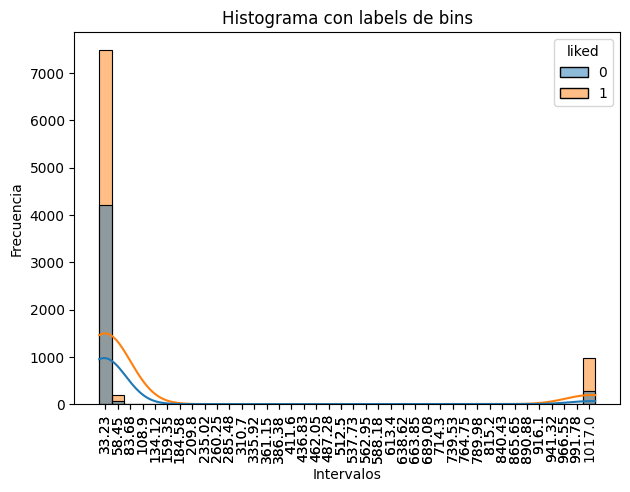

In [52]:
price_subset = recommend_df[[
    "rating", "user_body_diff", "user_tannins_diff", "user_sweetness_diff",
    "user_acidity_diff", "user_price_diff","rating_qty", "has_user_main_pairing",
    "user_price_center",
    "liked"]]
ax = sns.histplot(price_subset, x="user_price_center", hue="liked", kde=True, bins=40)

# Extrae los bins reales usados por seaborn (a través de los patches de matplotlib)
bin_edges = [patch.get_x() for patch in ax.patches]
# Agrega el borde derecho del último bin
bin_edges.append(ax.patches[-1].get_x() + ax.patches[-1].get_width())

# Crea etiquetas
xtick_labels = [f"{round(right,2)}" for right in bin_edges[1:]]
xtick_positions = [(left + right) / 2 for left, right in zip(bin_edges[:-1], bin_edges[1:])]

# Aplica los ticks personalizados
plt.xticks(xtick_positions, xtick_labels, rotation=90)
plt.tight_layout()
plt.xlabel("Intervalos")
plt.ylabel("Frecuencia")
plt.title("Histograma con labels de bins")
plt.show()

### DataFrames For Models Creation

- `model_df`: dataframe base, quitando columnas derivadas de la creación sintética de datos y otras no útiles.

- `model_df_nooh`: dataframe sin columnas one-hot.

- `model_df_nocat`: dataframe sin columnas categóricas.

In [53]:
# Carga de uvas, regions y pairings
grapes = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "grapes.csv"))
grapes_list = list(grapes["grapes"])
region = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "region.csv"))
region_list = list(region["region"])
pairings = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "pairings.csv"))
pairings_list = list(pairings["pairings"])

# Quita columnas no útiles para la predicción
model_df = recommend_df.drop(columns=[
    "event_timestamp", "wine_id", "wine_link", "name", "winery", "style", "image",  # Original df columns
    "user_id", "user_input", "prob_like", "user_main_pairing"                       # Synthetic User data columns
]).copy()      

# Quita columnas one hot (uvas y regions)
model_df_nooh = model_df.drop(columns=(grapes_list + region_list)).copy() # One-hot columns

# Quita columnas categóricas (maridajes)
model_df_nocat = model_df_nooh.drop(columns=pairings_list) # Categorical column

# Evaluación Económica

In [55]:
# Obtención de parámetros para evaluación económica (valoración de Confusion Matrix)
simulation_params = pd.read_pickle(ut.get_project_file_path("src", "data", "synthetic", "simulation_12_params.pkl"))
avg_tkt = model_df_nooh["price"].mean()
churn_like = simulation_params["liked_churn_rate"]
churn_dislike = simulation_params["disliked_churn_rate"]
print("Ticket Promedio:", avg_tkt, "\nChurn Like:", churn_like, "\nChurn Dislike:", churn_dislike)

Ticket Promedio: 22.546994241551747 
Churn Like: 0.008 
Churn Dislike: 0.65


### ✅ True Positive (TP)

Se recomienda un vino y al usuario le gusta.

El usuario tiene mayor probabilidad de quedarse (menor churn), por lo tanto se captura el valor esperado del ticket de recompra.

Fórmula:

$$\text{Valor}_{TP} = \text{AvgTkt} \times (1 - \text{Churn}_{like})$$

### ✅ True Negative (TN)

Se descarta un vino que al usuario no le gustaría, y se recomienda otro que podría gustarle.

Este caso depende de la precisión del modelo (Precision) para acertar la segunda recomendación. Se gana la diferencia entre:

- El valor esperado si se acertara la segunda recomendación.

- El valor perdido si se hubiera ofrecido el vino "malo" original.

Fórmula:
$$ \text{Valor}_{TN} = \text{AvgTkt} \times \left( \left( \left[ (1 - \text{Churn}_{like}) \times \text{Precision} \right] - \left[ \text{Churn}_{dislike} \times (1 - \text{Precision}) \right] \right) - (1 - \text{Churn}_{dislike}) \right)$$

### ❌ False Positive (FP)

Se recomienda un vino que no le gusta al usuario.

Esto aumenta fuertemente la probabilidad de churn, y se pierde el valor del ticket.

Fórmula:

$$\text{Valor}_{FP} = - \text{AvgTkt} \times \text{Churn}_{dislike}$$

### ❌ False Negative (FN)

Se descarta un vino que sí le habría gustado al usuario, y se le recomienda otro con otra probabilidad de acierto.

Se pierde el valor que se habría capturado si se recomendaba el vino correcto, ajustado por la incertidumbre de la nueva recomendación.

Fórmula:

$$\text{Valor}_{FN} = \text{AvgTkt} \times \left( \left( \left[ (1 - \text{Churn}_{like}) \times \text{Precision} \right] - \left[ \text{Churn}_{dislike} \times (1 - \text{Precision}) \right] \right) - (1 - \text{Churn}_{like}) \right)$$

### ⚠️ Notas:

- Precisión representa la probabilidad de que la segunda recomendación, luego de identificar una opción no recomendable, sea acertada.

# 👥 Evaluación de KNN

## KNN Base

### Creación de Modelo Base y Cross Validation

In [10]:
X = model_df_nocat.drop(columns=["liked"])
y = model_df_nocat["liked"]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
        # n_neighbors=15,
        # weights="uniform",
        # algorithm="auto",
        # metric="euclidean"
        # ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef. Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef. Var
roc_auc,0.827015,0.008677,0.010492
accuracy,0.788150,0.008200,0.010404
precision_macro,0.778951,0.010133,0.013008
recall_macro,0.734133,0.010057,0.013700
f1_macro,0.747233,0.010457,0.013995


### Learning Curves
- Validan over/under fitting y si más datos generarían mejor rendimiento.

In [ ]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Performance Curves

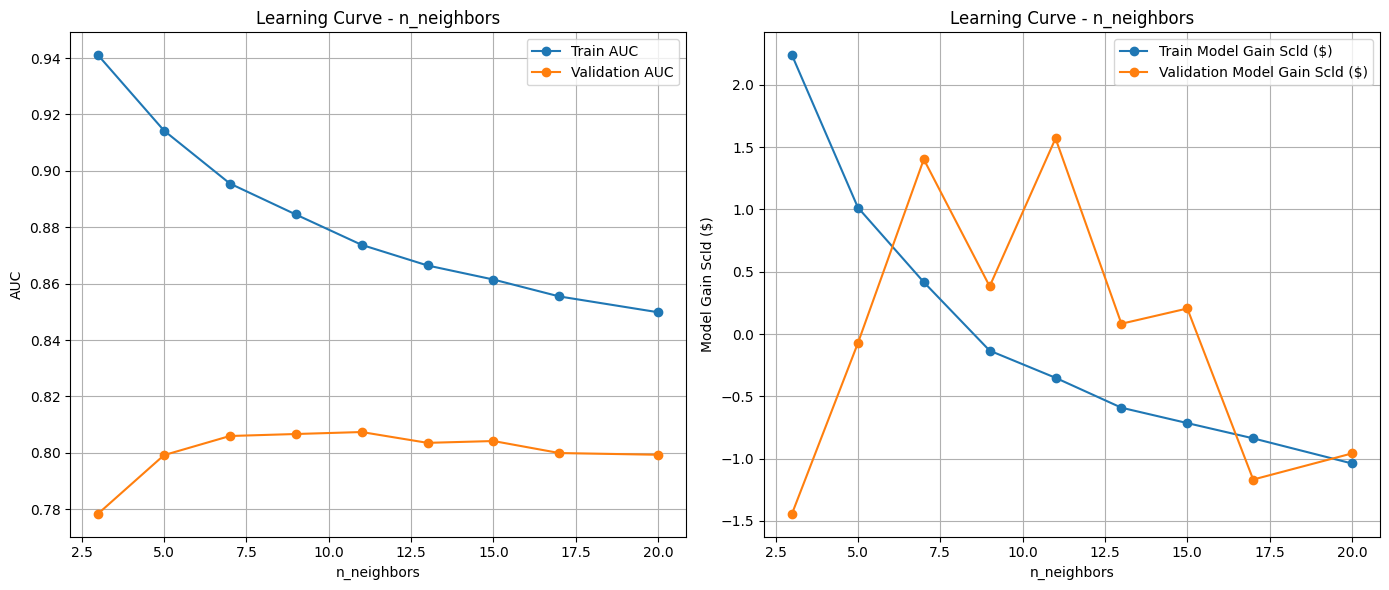

In [ ]:
# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=None)

# Escalado
std_scaler = StandardScaler()
X_train_scld = std_scaler.fit_transform(X_train)
X_val_scld = std_scaler.transform(X_val)
X_test_scld = std_scaler.transform(X_test)

# Modelo
knn_base = KNeighborsClassifier(weights="uniform", metric="manhattan")

# Parámetros
params_dict = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15, 17, 20]
    #"weights": ["uniform", "distance"],
    #"metric": ["euclidean", "manhattan"]
}

# Score Económico
eco_score_dict = {
    "avg_tkt": avg_tkt,
    "churn_like": churn_like,
    "churn_dislike": churn_dislike
}

# Ploteo de curvas de performance
mod_prep.plot_performance_curves(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    base_model=knn_base,
    params_dict=params_dict,
    eco_score_dict=eco_score_dict)

### Feature Selection

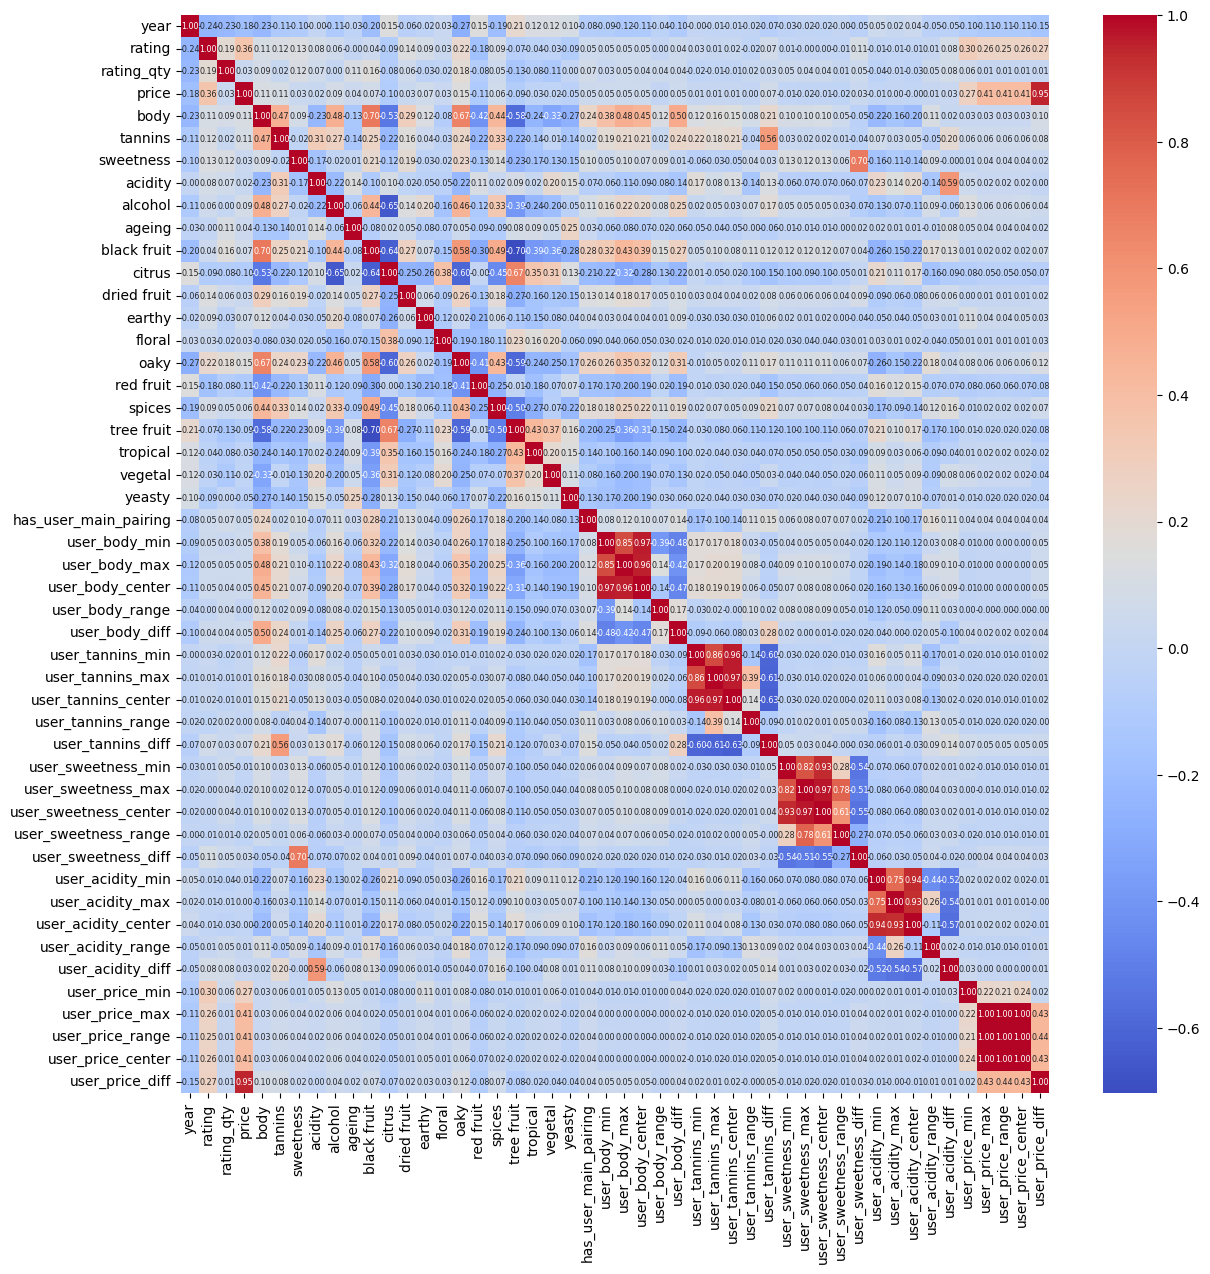

In [ ]:
# Features Generales
X_train_df = pd.DataFrame(X_train_scld, columns=X.columns)
corr_matrix = X_train_df.corr()
plt.figure(figsize=(14, 14))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, annot_kws={"fontsize": "xx-small"}, fmt=".2f")
plt.show()

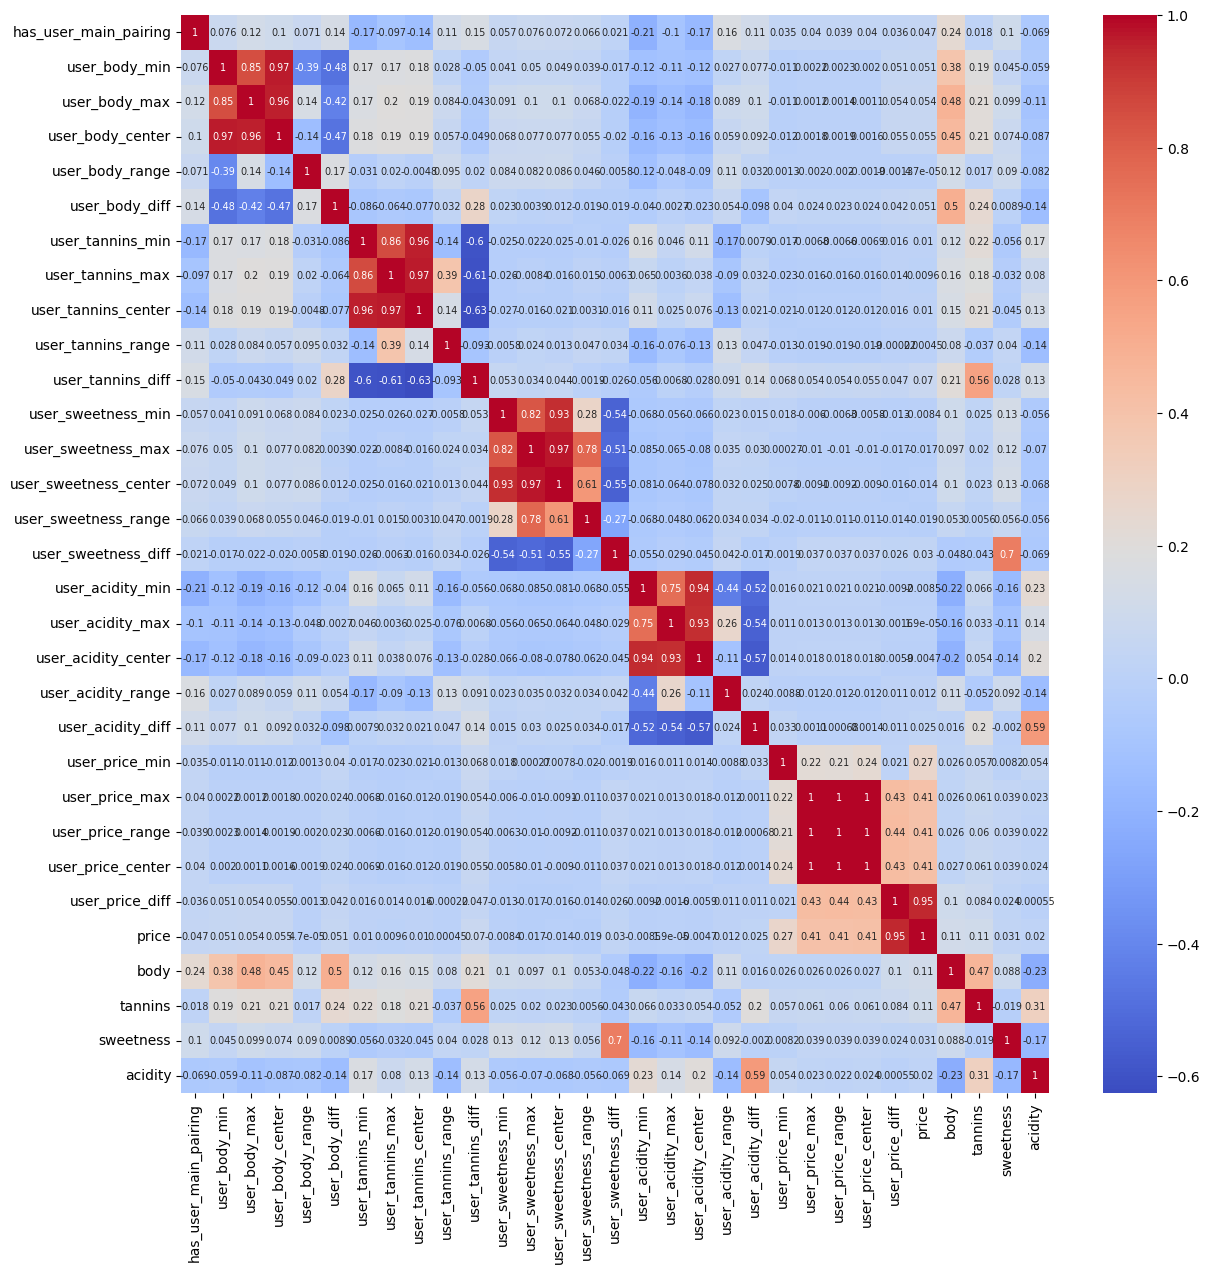

In [ ]:
# User features
user_features = X.loc[:, "has_user_main_pairing":].columns.to_list()
wine_user_features = ["price", "body", "tannins", "sweetness", "acidity"]
user_corr_matrix = X_train_df[user_features + wine_user_features].corr()
plt.figure(figsize=(14, 14))
sns.heatmap(user_corr_matrix, cmap="coolwarm", annot=True, annot_kws={"fontsize": "x-small"})
plt.show()

*1 - Correlación Con Liked*

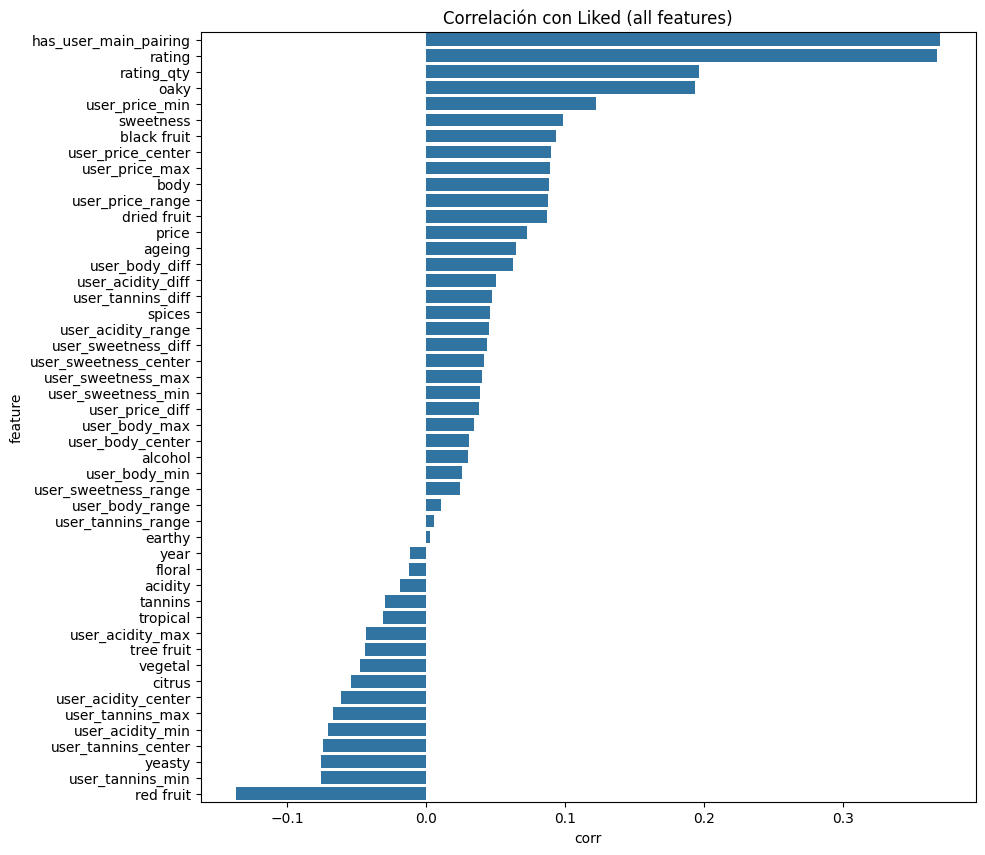

In [ ]:
# Para el precio, la variable más importante es el max o el centro
# Para cada sabor, el valor más importante es la diff

liked_corr = pd.DataFrame(model_df_nocat.corr(method="pearson")["liked"].sort_values(ascending=False)).reset_index()
liked_corr.columns = ["feature", "corr"]
liked_corr = liked_corr.loc[1:, :]

plt.figure(figsize=(10, 10))
sns.barplot(data=liked_corr, y="feature", x="corr")
plt.title("Correlación con Liked (all features)")
plt.show()


*2 - SelectKBest*

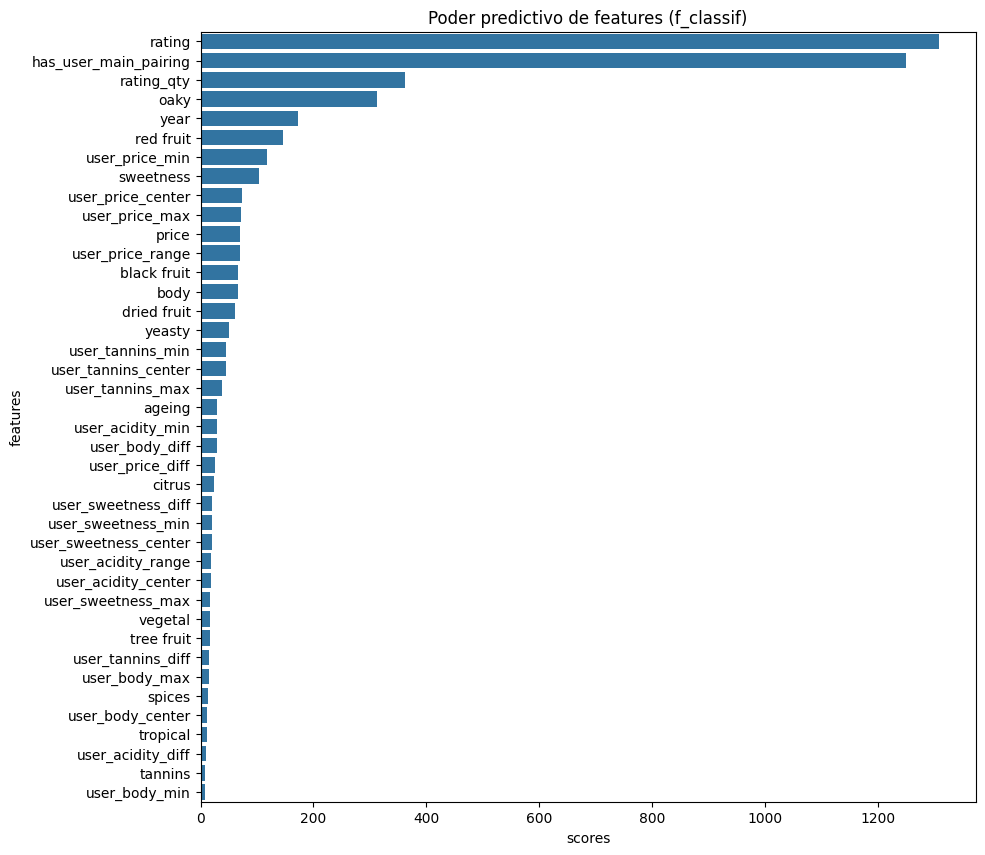

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k="all")

X_train_select = selector.fit_transform(X_train_scld, y_train)

scores = selector.scores_
pvalues = selector.pvalues_

features_scores = pd.DataFrame({
    "features": X.columns,
    "scores": scores,
    "pvalues": pvalues
})

features_scores = features_scores.sort_values(by="scores", ascending=False)
top = features_scores.head(40)

plt.figure(figsize=(10, 10))
sns.barplot(data=top, y="features", x="scores")
plt.title("Poder predictivo de features (f_classif)")
plt.show()

## KNN User Pruned

*Feature Selection*

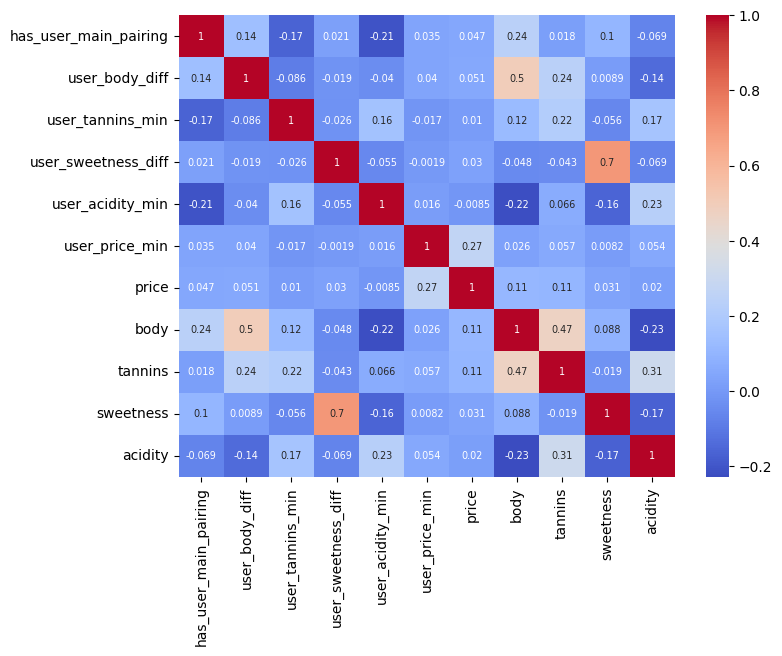

In [ ]:
# Revisamos que no haya fuerte correlación (colinealidad)
user_features_pruned = [
    "has_user_main_pairing", "user_body_diff", "user_tannins_diff",
    "user_sweetness_diff", "user_acidity_diff","user_price_center"
]

user_features_pruned2 = [
    "has_user_main_pairing", "user_body_diff", "user_tannins_min",
    "user_sweetness_diff", "user_acidity_min","user_price_min"
]

wine_user_features = ["price", "body", "tannins", "sweetness", "acidity"]
user_pruned_corr_matrix = X_train_df[user_features_pruned2 + wine_user_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(user_pruned_corr_matrix, cmap="coolwarm", annot=True, annot_kws={"fontsize": "x-small"})
plt.show()

*Feature Prunning*

In [ ]:
user_features = model_df_nocat.loc[:, "has_user_main_pairing":].columns.to_list()

user_features_pruned = [
    "has_user_main_pairing", "user_body_diff", "user_tannins_diff",
    "user_sweetness_diff", "user_acidity_diff","user_price_center"
]

user_features_pruned2 = [
    "has_user_main_pairing", "user_body_diff", "user_tannins_min",
    "user_sweetness_diff", "user_acidity_min","user_price_min"
]

cols_to_prune = [ft for ft in user_features if ft not in user_features_pruned2]


wine_features_pruned = [
    'vegetal',
    'citrus',
    'spices',
    'tree fruit',
    'tropical',
    'alcohol',
    'floral',
    'earthy',
    'year'
]

cols_to_prune = cols_to_prune #+ wine_features_pruned
cols_to_prune.append("liked")
cols_to_prune

['user_body_min',
 'user_body_max',
 'user_body_center',
 'user_body_range',
 'user_tannins_max',
 'user_tannins_center',
 'user_tannins_range',
 'user_tannins_diff',
 'user_sweetness_min',
 'user_sweetness_max',
 'user_sweetness_center',
 'user_sweetness_range',
 'user_acidity_max',
 'user_acidity_center',
 'user_acidity_range',
 'user_acidity_diff',
 'user_price_max',
 'user_price_range',
 'user_price_center',
 'user_price_diff',
 'liked']

*Evaluación de performance*

In [ ]:
X = model_df_nocat.drop(columns=cols_to_prune)
y = model_df_nocat["liked"]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
        # n_neighbors=15,
        # weights="uniform",
        # algorithm="auto",
        # metric="euclidean"
        # ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef. Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef. Var
roc_auc,0.850083,0.005583,0.006568
accuracy,0.796711,0.005831,0.007318
precision_macro,0.782895,0.006999,0.008940
recall_macro,0.752550,0.006885,0.009148
f1_macro,0.763158,0.007033,0.009215


*Learning Curves*

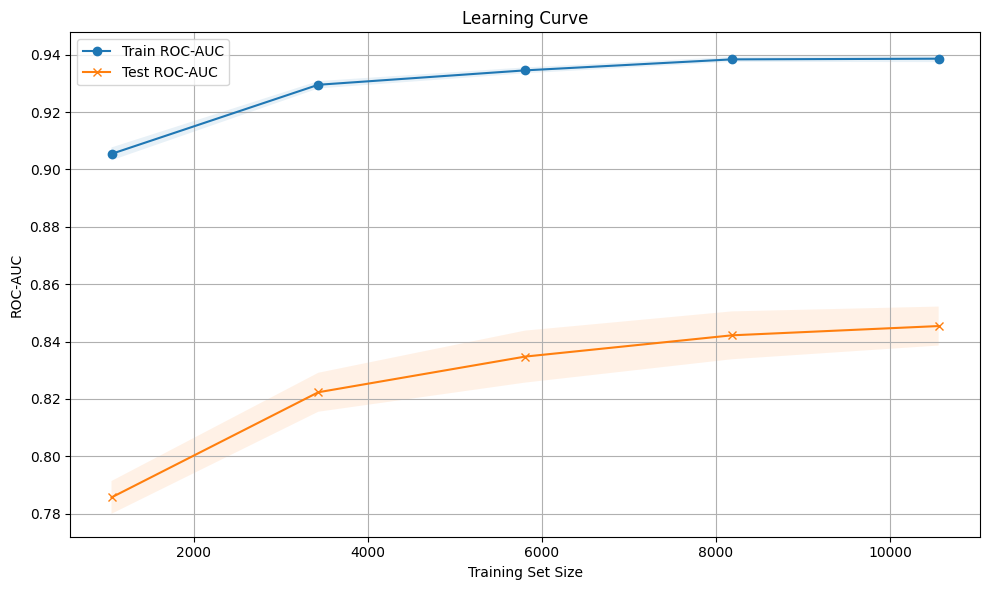

In [ ]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

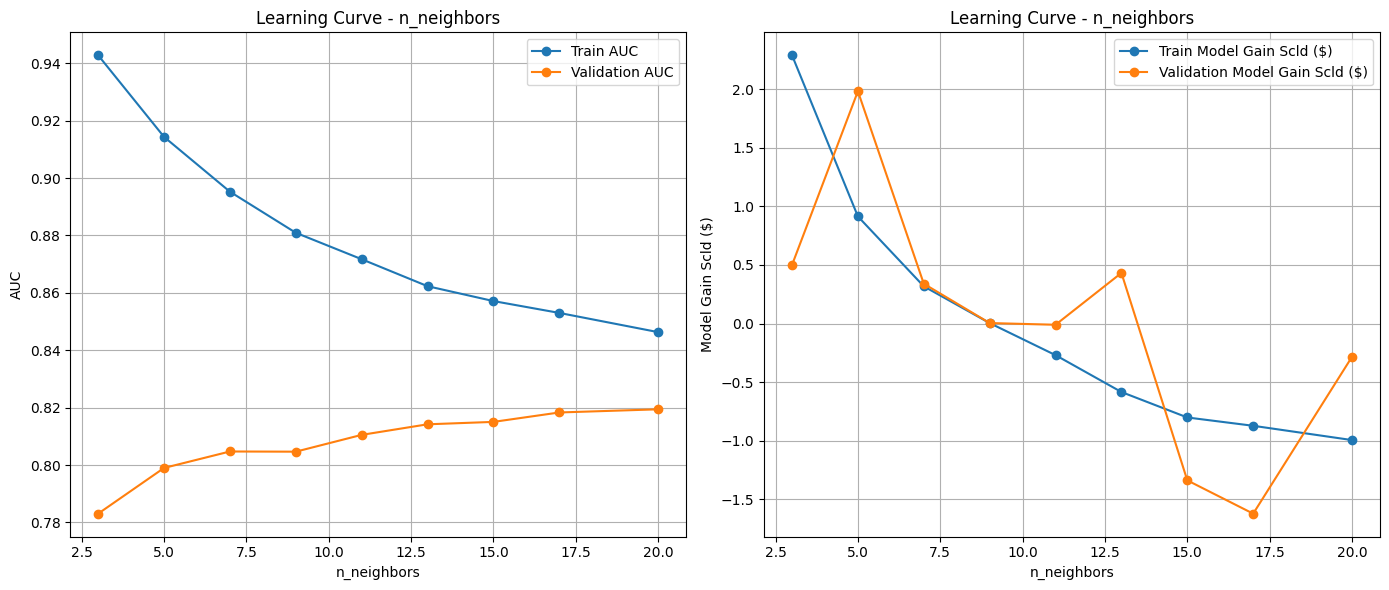

In [ ]:
# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=None)

# Escalado
std_scaler = StandardScaler()
X_train_scld = std_scaler.fit_transform(X_train)
X_val_scld = std_scaler.transform(X_val)
X_test_scld = std_scaler.transform(X_test)

# Modelo
knn_base = KNeighborsClassifier()

# Parámetros
params_dict = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15, 17, 20]
    #"weights": ["uniform", "distance"],
    #"metric": ["euclidean", "manhattan"]
}

# Score Económico
eco_score_dict = {
    "avg_tkt": avg_tkt,
    "churn_like": churn_like,
    "churn_dislike": churn_dislike
}

# Ploteo de curvas de performance
mod_prep.plot_performance_curves(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    base_model=knn_base,
    params_dict=params_dict,
    eco_score_dict=eco_score_dict)

*1 - Correlación con Liked*

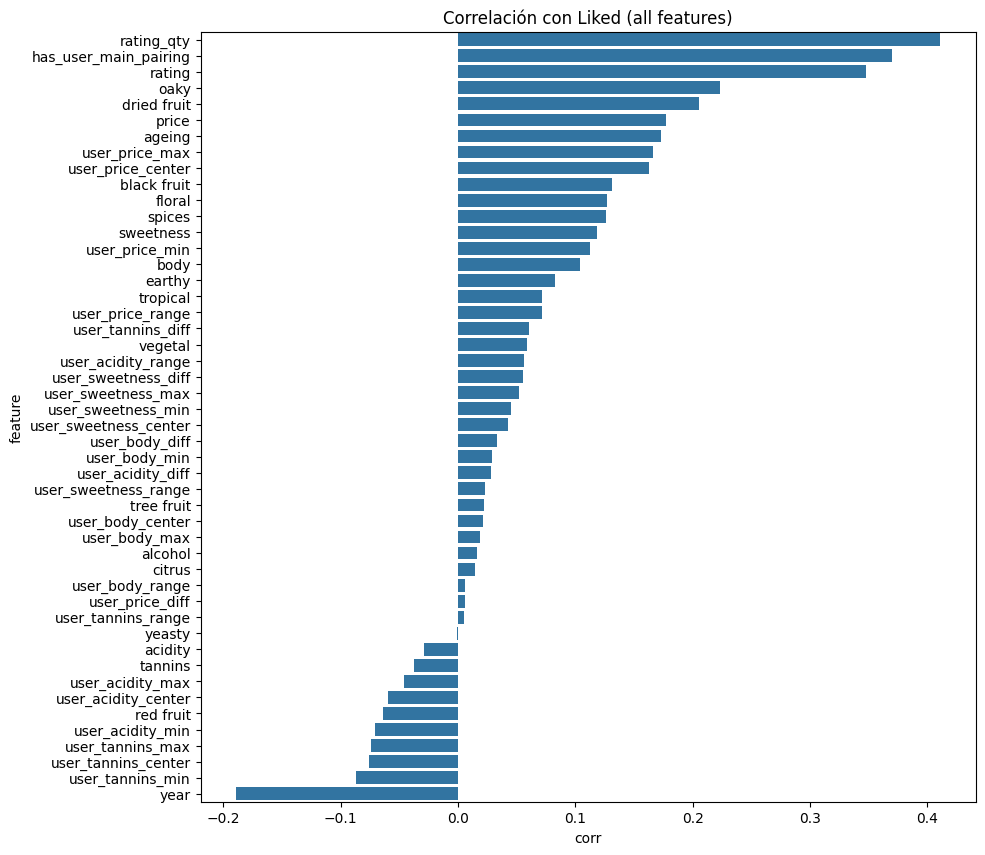

In [ ]:
# Para el precio, la variable más importante es el max o el centro
# Para cada sabor, el valor más importante es la diff

liked_corr = pd.DataFrame(model_df_nocat.corr(method="spearman")["liked"].sort_values(ascending=False)).reset_index()
liked_corr.columns = ["feature", "corr"]
liked_corr = liked_corr.loc[1:, :]

plt.figure(figsize=(10, 10))
sns.barplot(data=liked_corr, y="feature", x="corr")
plt.title("Correlación con Liked (all features)")
plt.show()


*2 - SelectKBest*

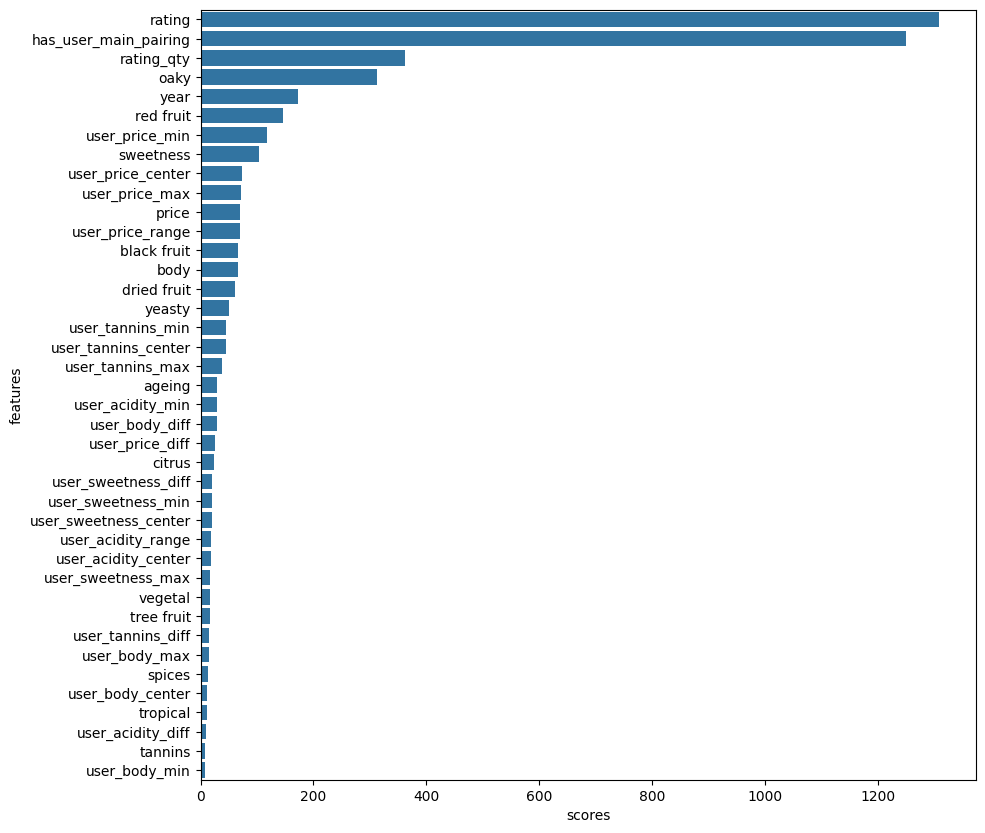

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

selector = SelectKBest(score_func=f_classif, k="all")

X_train_select = selector.fit_transform(X_train_scld, y_train)

scores = selector.scores_
pvalues = selector.pvalues_

features_scores = pd.DataFrame({
    "features": X.columns,
    "scores": scores,
    "pvalues": pvalues
})

features_scores = features_scores.sort_values(by="scores", ascending=False)
features_scores = features_scores

plt.figure(figsize=(10, 10))
sns.barplot(data=top, y="features", x="scores")
plt.show()

*3 - SequentialFeatureSelector*

## KNN SFS Selected

*Feature Selection*

In [ ]:
X = model_df_nocat.drop(columns=["liked"])
y = model_df_nocat["liked"]

# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=None)

# Escalado
std_scaler = StandardScaler()
X_train_scld = std_scaler.fit_transform(X_train)
X_val_scld = std_scaler.transform(X_val)
X_test_scld = std_scaler.transform(X_test)

knn = KNeighborsClassifier()

sfs = SequentialFeatureSelector(
    estimator=knn,
    n_features_to_select=20,
    direction="forward",
    scoring="roc_auc",
    cv=5
)

sfs.fit(X_train_scld, y_train)

SequentialFeatureSelector(estimator=KNeighborsClassifier(),
                          n_features_to_select=20, scoring='roc_auc')

In [ ]:
model_df_nocat

,liked,year,rating,rating_qty,price,body,tannins,sweetness,acidity,alcohol,ageing,black fruit,citrus,dried fruit,earthy,floral,oaky,red fruit,spices,tree fruit,tropical,vegetal,yeasty,has_user_main_pairing,user_body_min,user_body_max,user_body_center,user_body_range,user_body_diff,user_tannins_min,user_tannins_max,user_tannins_center,user_tannins_range,user_tannins_diff,user_sweetness_min,user_sweetness_max,user_sweetness_center,user_sweetness_range,user_sweetness_diff,user_acidity_min,user_acidity_max,user_acidity_center,user_acidity_range,user_acidity_diff,user_price_min,user_price_max,user_price_range,user_price_center,user_price_diff
0,1,2016.0,4.3,3243.0,24.95,0.5392,0.2904,0.2272,0.6372,0.1350,0.0061,0.2825,0.0130,0.0154,0.1242,0.0239,0.3153,0.1100,0.0820,0.0106,0.0028,0.0065,0.0077,1,0.2896,0.519075,0.404338,0.229475,0.020125,0.393100,0.67500,0.534050,0.281900,-0.1027,0.0000,0.15140,0.075700,0.15140,0.0758,0.51470,0.8132,0.663950,0.29850,0.0000,15,46.0,31.0,30.5,-5.55
1,0,2022.0,3.5,102.0,10.99,0.6731,0.2431,0.1652,0.3639,0.1400,0.0097,0.3973,0.0019,0.0058,0.0988,0.0019,0.2578,0.1492,0.0543,0.0039,0.0039,0.0039,0.0116,1,0.3050,0.610000,0.457500,0.305000,0.063100,0.373300,0.50300,0.438150,0.129700,-0.1302,0.1328,0.18270,0.157750,0.04990,0.0000,0.47920,0.8500,0.664600,0.37080,-0.1153,1,15.0,14.0,8.0,2.99
2,1,2016.0,4.0,1520.0,26.99,0.6178,0.4387,0.3087,0.4437,0.1400,0.0154,0.3282,0.0000,0.0154,0.1236,0.0309,0.3205,0.1158,0.0425,0.0000,0.0000,0.0000,0.0077,1,0.3050,0.610000,0.457500,0.305000,0.007800,0.373300,0.50300,0.438150,0.129700,0.0000,0.2106,0.42480,0.317700,0.21420,0.0000,0.36620,0.4157,0.390950,0.04950,0.0280,20,34.0,14.0,27.0,-0.01
3,0,2023.0,3.9,25.0,20.00,0.4022,0.3621,0.0486,0.4250,0.1402,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,0.4528,0.479500,0.466150,0.026700,-0.050600,0.543900,0.57015,0.557025,0.026250,-0.1818,0.1084,0.12820,0.118300,0.01980,-0.0598,0.51410,0.5435,0.528800,0.02940,-0.0891,18,23.0,5.0,20.5,-0.50
4,0,2021.0,3.8,69.0,17.00,0.4671,0.4884,0.1502,0.7551,0.1399,0.0073,0.2763,0.0024,0.0147,0.1394,0.0122,0.2347,0.1663,0.1100,0.0049,0.0000,0.0244,0.0073,1,0.5481,0.725200,0.636650,0.177100,-0.081000,0.304500,0.37010,0.337300,0.065600,0.1183,0.1806,0.38500,0.282800,0.20440,-0.0304,0.45160,0.5262,0.488900,0.07460,0.2289,13,18.0,5.0,15.5,1.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13193,1,2023.0,4.0,25.0,20.24,0.4086,0.3639,0.1287,0.5511,0.1332,0.0030,0.0060,0.2232,0.0060,0.0804,0.0149,0.0030,0.2946,0.0060,0.2679,0.0446,0.0238,0.0268,1,0.4545,0.550800,0.502650,0.096300,-0.045900,0.362475,0.38220,0.372337,0.019725,0.0000,0.1365,0.18195,0.159225,0.04545,-0.0078,0.49635,0.5301,0.513225,0.03375,0.0210,18,23.0,5.0,20.5,-0.26
13194,1,2018.0,4.1,297.0,21.98,0.6503,0.4081,0.2983,0.5225,0.1450,0.0111,0.3344,0.0044,0.0156,0.1422,0.0144,0.2911,0.1033,0.0711,0.0011,0.0000,0.0011,0.0100,1,0.3000,0.640100,0.470050,0.340100,0.010200,0.415000,0.44250,0.428750,0.027500,-0.0069,0.3004,0.42480,0.362600,0.12440,-0.0021,0.52970,0.5504,0.540050,0.02070,-0.0072,13,23.0,10.0,18.0,3.98
13195,1,2010.0,4.2,567.0,45.00,0.7651,0.5452,0.1319,0.5185,0.1406,0.0053,0.2965,0.0021,0.0138,0.1286,0.0096,0.3677,0.0627,0.0956,0.0021,0.0000,0.0032,0.0128,1,0.6898,0.850000,0.769900,0.160200,0.000000,0.304500,0.48050,0.392500,0.176000,0.0647,0.1051,0.14560,0.125350,0.04050,0.0000,0.54990,0.8132,0.681550,0.26330,-0.0314,15,46.0,31.0,30.5,14.50
13196,0,2022.0,3.5,25.0,20.00,0.8500,0.5732,0.0361,0.6704,0.1400,0.0000,0.4194,0.0000,0.0215,0.1075,0.0108,0.2366,0.1183,0.0753,0.0000,0.0000,0.0000,0.0108,1,0.6100,0.649100,0.629550,0.039100,0.200900,0.373300,0.50300,0.438150,0.129700,0.0702,0.0000,0.13280,0.066400,0.13280,0.0000,0.47920,0.8500,0.664600,0.37080,0.0000,15,2000.0,1985.0,1007.5,5.00


*Feature Pruning*

In [ ]:
X = model_df_nocat.drop(columns=["liked"])
y = model_df_nocat["liked"]
sfs_features = X.loc[:, sfs.get_support()].columns.to_list()
# other_features = ["black fruit"]
# sfs_features += [f for f in other_features if f not in sfs_features]
drop_cols = ["user_acidity_min", "user_acidity_max", "user_acidity_center", "tree fruit", "tropical", "sweetness", "body", "ageing", "dried fruit"]
sfs_features = [f for f in sfs_features if f not in drop_cols]
sfs_features

['year',
 'rating',
 'rating_qty',
 'price',
 'red fruit',
 'has_user_main_pairing',
 'user_body_diff',
 'user_tannins_diff',
 'user_sweetness_diff',
 'user_acidity_diff',
 'user_price_diff']

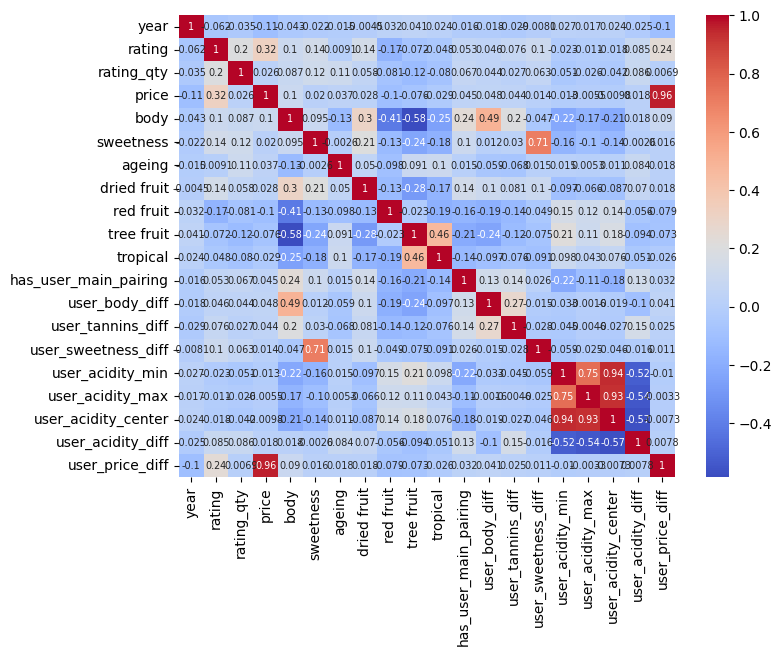

In [ ]:
sfs_features_corr_matrix = X[sfs_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(sfs_features_corr_matrix, cmap="coolwarm", annot=True, annot_kws={"fontsize": "x-small"})
plt.show()

*Performance con CV*

In [ ]:
X = model_df_nocat[sfs_features]
y = model_df_nocat["liked"]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=11))
        # n_neighbors=15,
        # weights="uniform",
        # algorithm="auto",
        # metric="euclidean"
        # ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef. Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef. Var
roc_auc,0.888367,0.004324,0.004868
accuracy,0.820504,0.007907,0.009637
precision_macro,0.815899,0.010141,0.012430
recall_macro,0.775241,0.009129,0.011775
f1_macro,0.788876,0.009456,0.011987


*Evaluación de Performance*


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

           0       0.85      0.66      0.75      2724
           1       0.84      0.94      0.89      5194

    accuracy                           0.84      7918
   macro avg       0.85      0.80      0.82      7918
weighted avg       0.85      0.84      0.84      7918



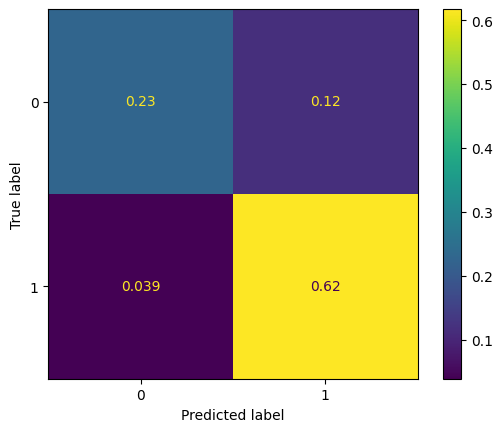

AUC Train: 0.9292427385716152

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

           0       0.81      0.64      0.72       908
           1       0.83      0.92      0.87      1732

    accuracy                           0.83      2640
   macro avg       0.82      0.78      0.79      2640
weighted avg       0.82      0.83      0.82      2640



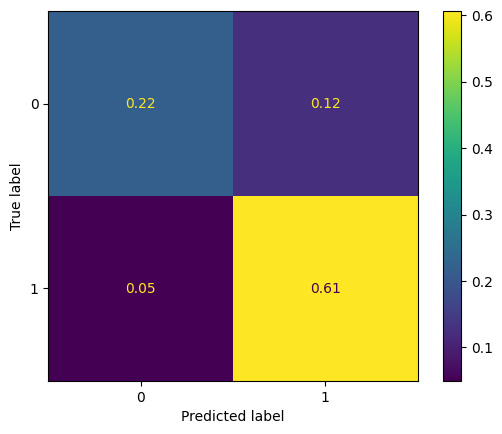

AUC Test: 0.8938916075734298


In [ ]:
X = model_df_nocat[sfs_features]
y = model_df_nocat["liked"]


# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=0)

# Escalado
std_scaler = StandardScaler()
X_train_scld = std_scaler.fit_transform(X_train)
X_val_scld = std_scaler.transform(X_val)
X_test_scld = std_scaler.transform(X_test)


knn = KNeighborsClassifier(n_neighbors=11)

# Entrenamiento
knn.fit(X_train_scld, y_train)

# Predicción de train
y_train_proba = knn.predict_proba(X_train_scld)[:, 1]
y_train_pred = knn.predict(X_train_scld)
cm_train = confusion_matrix(y_train, y_train_pred, normalize="all")
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=knn.classes_)

# Predicción de val
y_val_proba = knn.predict_proba(X_val_scld)[:, 1]
y_val_pred = knn.predict(X_val_scld)
cm_val = confusion_matrix(y_val, y_val_pred, normalize="all")
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=knn.classes_)

# Visualización de resultados
print("\n----------------------------------------------------\n")
print("Train Metrics:\n")
print(classification_report(y_train, y_train_pred))
disp_train.plot()
plt.show()
print("AUC Train:", roc_auc_score(y_train, y_train_proba))
print("\n----------------------------------------------------\n")
print("Test Metrics:\n")
print(classification_report(y_val, y_val_pred))
disp_val.plot()
plt.show()
print("AUC Test:", roc_auc_score(y_val, y_val_proba))

*Learning Curve*

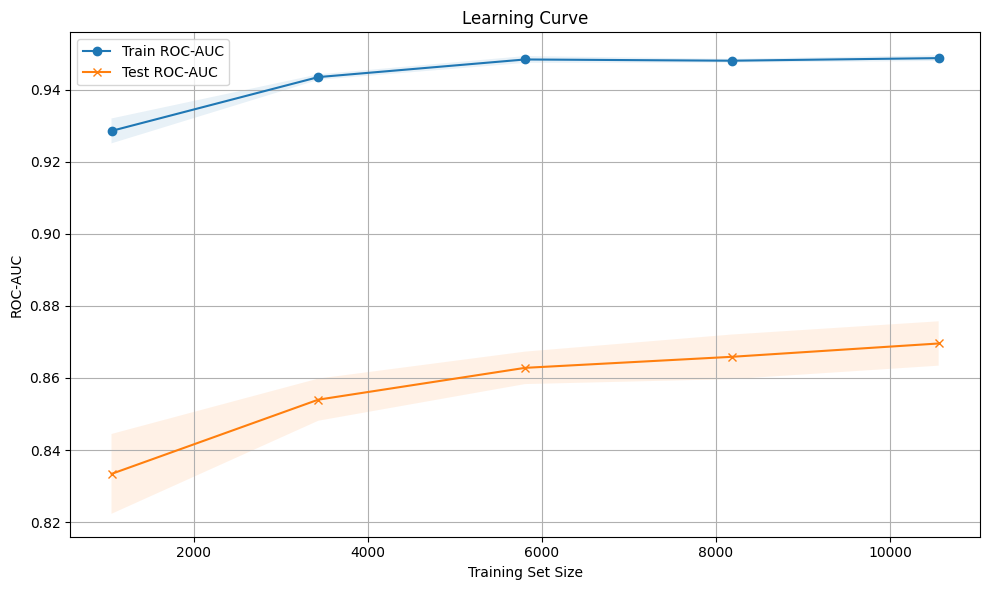

In [ ]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

*Performance Curves*

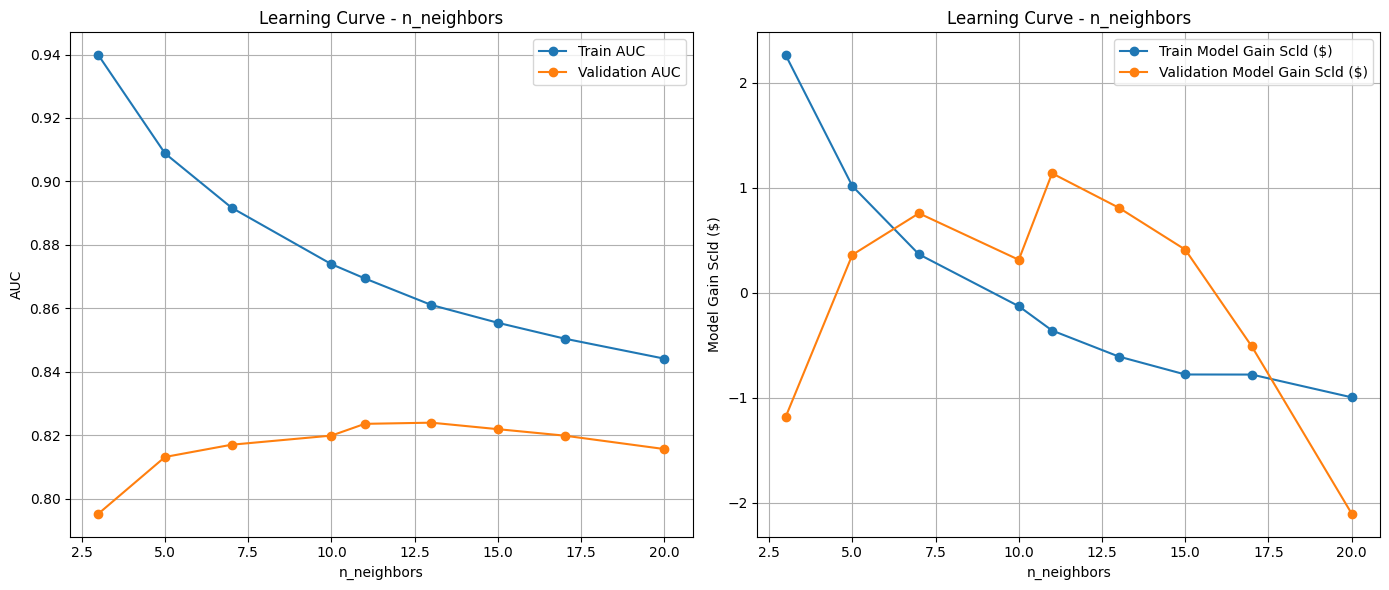

In [ ]:
# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=0)

# Escalado
std_scaler = StandardScaler()
X_train_scld = std_scaler.fit_transform(X_train)
X_val_scld = std_scaler.transform(X_val)
X_test_scld = std_scaler.transform(X_test)

# Modelo
knn_base = KNeighborsClassifier()

# Parámetros
params_dict = {
    "n_neighbors": [3, 5, 7, 10, 11, 13, 15, 17, 20]
    #"weights": ["uniform", "distance"],
    #"metric": ["euclidean", "manhattan"]
}

# Score Económico
eco_score_dict = {
    "avg_tkt": avg_tkt,
    "churn_like": churn_like,
    "churn_dislike": churn_dislike
}

# Ploteo de curvas de performance
mod_prep.plot_performance_curves(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    base_model=knn_base,
    params_dict=params_dict,
    eco_score_dict=eco_score_dict)

# Finetunning KNN

Elegimos el modelo con la selección de features a partir del Sequential Feature Selector (SFS).

Vemos que la mejor combinación de parámetros es alcanzada con 12 neighbors ``(accuracy + roc_auc + economic_score)``

In [12]:
# Creación de score económico personalizado
def economic_score_scorer(y_true, y_pred):
    conf = confusion_matrix(y_true, y_pred)
    return mod_prep.economic_score(
        conf_matrix=conf,
        avg_tkt=avg_tkt,
        churn_like=churn_like,
        churn_dislike=churn_dislike
    )

custom_scorer = make_scorer(economic_score_scorer, greater_is_better=True)

In [13]:
# Elección de features
sfs_features = ['year', 'rating', 'rating_qty', 'price', 'red fruit',
                'has_user_main_pairing', 'user_body_diff', 'user_tannins_diff',
                'user_sweetness_diff', 'user_acidity_diff', 'user_price_diff']

# Obtención de datos (X, y)
X = model_df_nocat[sfs_features]
y = model_df_nocat["liked"]

# Split de datos (train, test)
X_train, X_test, y_train, y_test = mod_prep.train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

# Creación de Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# Cross Validation Stratified
skf = StratifiedKFold(n_splits=5, shuffle=True)

# Parametros del Grid
param_grid = {
    "knn__n_neighbors": range(3, 21)
}

# Scoring
scoring_metrics = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "economic_scorer": custom_scorer
}

# GridSearch
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring=scoring_metrics,
    refit="roc_auc",
    cv=skf,
    n_jobs=1
)

grid.fit(X_train, y_train)

# Resultados
grid_results = pd.DataFrame(grid.cv_results_)
summary_results = grid_results[["mean_test_accuracy", "mean_test_roc_auc", "mean_test_economic_scorer", "params"]].sort_values(by="mean_test_roc_auc", ascending=False)
summary_results


,mean_test_accuracy,mean_test_roc_auc,mean_test_economic_scorer,params
17,0.817673,0.891921,27325.953643,{'knn__n_neighbors': 20}
14,0.814832,0.891404,27122.724053,{'knn__n_neighbors': 17}
15,0.818431,0.891158,27382.585184,{'knn__n_neighbors': 18}
16,0.815306,0.891067,27151.280339,{'knn__n_neighbors': 19}
11,0.820042,0.890929,27529.188999,{'knn__n_neighbors': 14}
13,0.820610,0.890500,27551.392770,{'knn__n_neighbors': 16}
12,0.816537,0.890500,27243.313657,{'knn__n_neighbors': 15}
10,0.817390,0.889833,27307.911058,{'knn__n_neighbors': 13}
9,0.821368,0.888314,27652.650832,{'knn__n_neighbors': 12}
8,0.817484,0.886647,27319.288682,{'knn__n_neighbors': 11}


# Evaluación Final KNN


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

           0       0.83      0.72      0.77      3632
           1       0.86      0.92      0.89      6926

    accuracy                           0.85     10558
   macro avg       0.84      0.82      0.83     10558
weighted avg       0.85      0.85      0.85     10558



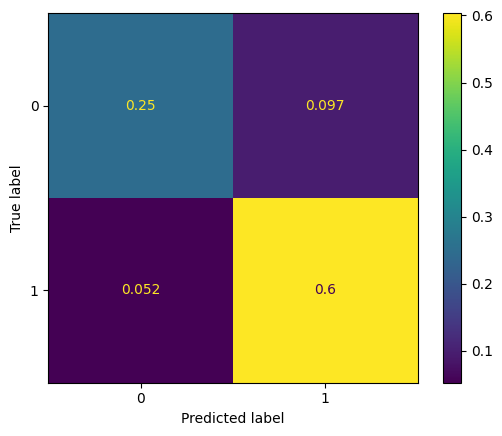

AUC Train: 0.927764709146789
Gain from model: $149245

----------------------------------------------------


----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

           0       0.77      0.69      0.73       908
           1       0.85      0.89      0.87      1732

    accuracy                           0.82      2640
   macro avg       0.81      0.79      0.80      2640
weighted avg       0.82      0.82      0.82      2640



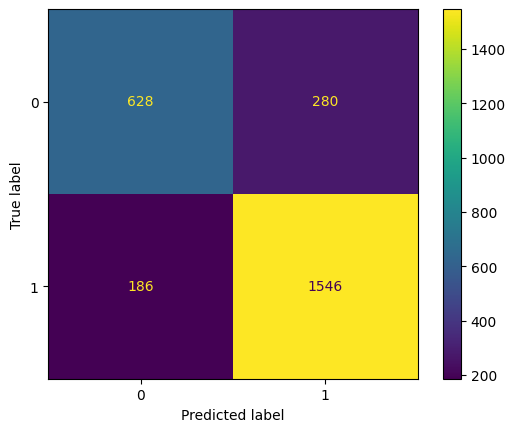

AUC Test: 0.8853074035262638
Gain from model: $34945

----------------------------------------------------



In [87]:
# Nuevo pipeline con hiperparámetros optimizados
pipelinek12 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=12))
])

pipelinek12.fit(X_train, y_train)

# Train
y_train_pred = pipelinek12.predict(X_train)
y_train_proba = pipelinek12.predict_proba(X_train)[:, 1]

cm_train = confusion_matrix(y_train, y_train_pred)
cm_train_norm = confusion_matrix(y_train, y_train_pred, normalize="all")
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train_norm, display_labels=pipelinek12.named_steps["knn"].classes_)

print("\n----------------------------------------------------\n")
print("Train Metrics:\n")
print(classification_report(y_train, y_train_pred))
disp_train.plot()
plt.show()

print("AUC Train:", roc_auc_score(y_train, y_train_proba))

eco_score = mod_prep.economic_score(
    conf_matrix=cm_train,
    avg_tkt=avg_tkt,
    churn_like=churn_like,
    churn_dislike=churn_dislike
    )
print("Gain from model: $", round(eco_score), sep="")

print("\n----------------------------------------------------\n")

# Test
y_test_pred = pipelinek12.predict(X_test)
y_test_proba = pipelinek12.predict_proba(X_test)[:, 1]

cm_test = confusion_matrix(y_test, y_test_pred)
cm_test_norm = confusion_matrix(y_test, y_test_pred, normalize="all")
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=pipelinek12.named_steps["knn"].classes_)

print("\n----------------------------------------------------\n")
print("Test Metrics:\n")
print(classification_report(y_test, y_test_pred))
disp_test.plot()
plt.show()

print("AUC Test:", roc_auc_score(y_test, y_test_proba))

eco_score = mod_prep.economic_score(
    conf_matrix=cm_test,
    avg_tkt=avg_tkt,
    churn_like=churn_like,
    churn_dislike=churn_dislike
    )
print("Gain from model: $", round(eco_score), sep="")

print("\n----------------------------------------------------\n")


# 🌳 Evaluación de Random Forest

## RF Base

In [10]:
X = model_df_nocat.drop(columns=["liked"])
y = model_df_nocat["liked"]

# Pipeline con oversampler y modelo para aplicarlo en cada Fold del CV
pipeline = Pipeline([
    ("rf", RandomForestClassifier())
])

# Aplicación de cross validation y obtención de métricas
skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

# Resumen de métricas del CV
metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

# Media, Desvío Estándar y Coef Var
metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef Var
roc_auc,0.915607,0.002285,0.002496
accuracy,0.841263,0.002481,0.002949
precision_macro,0.828881,0.003269,0.003944
recall_macro,0.813641,0.003371,0.004143
f1_macro,0.820170,0.002856,0.003482


### Learning Curves

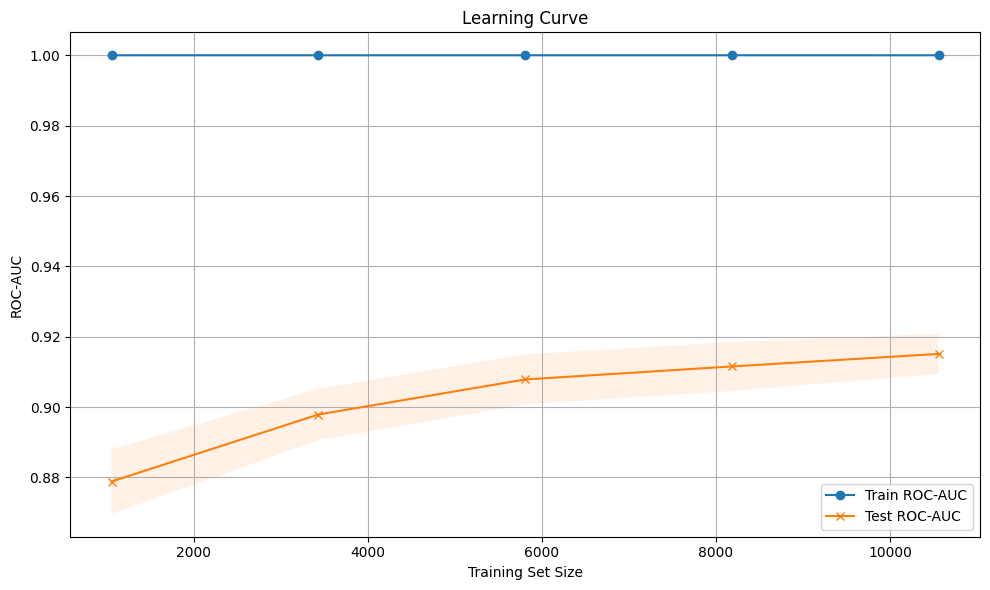

In [14]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Performance Curves

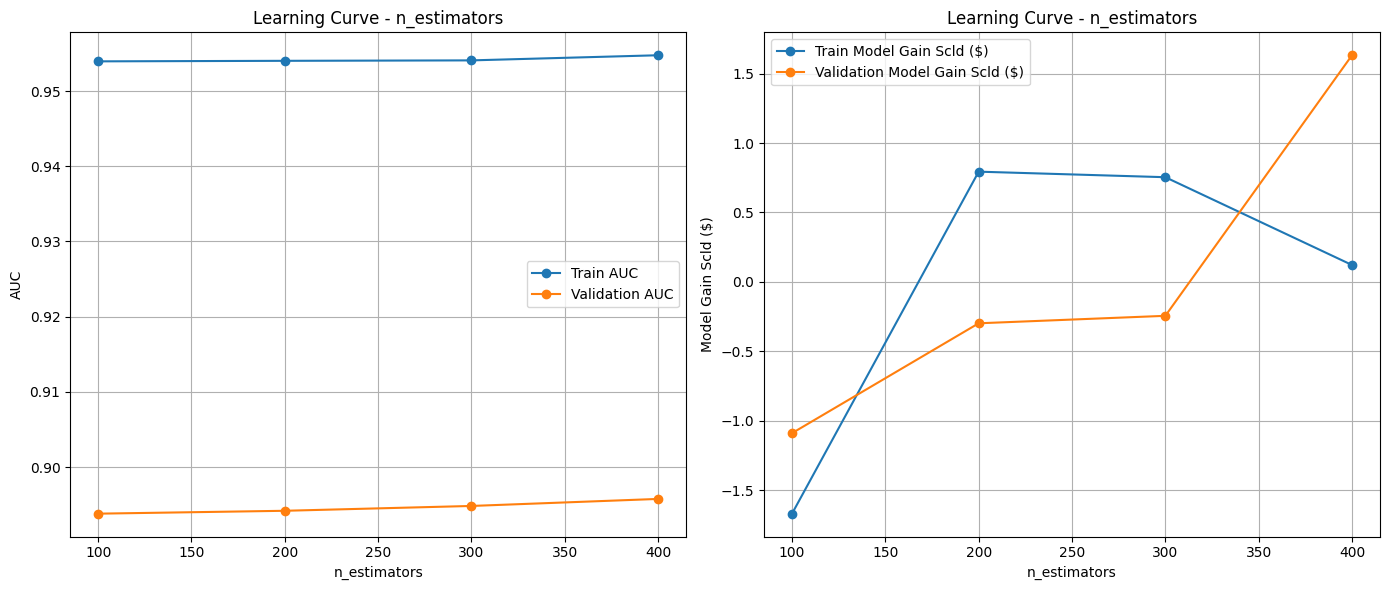

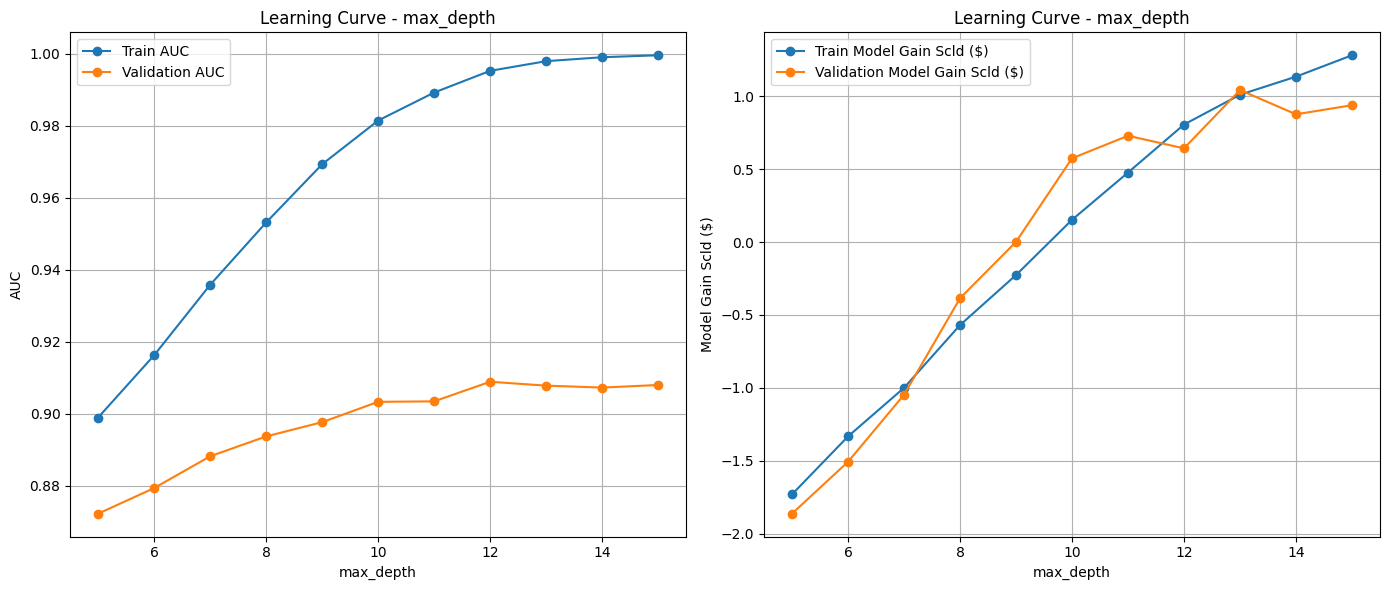

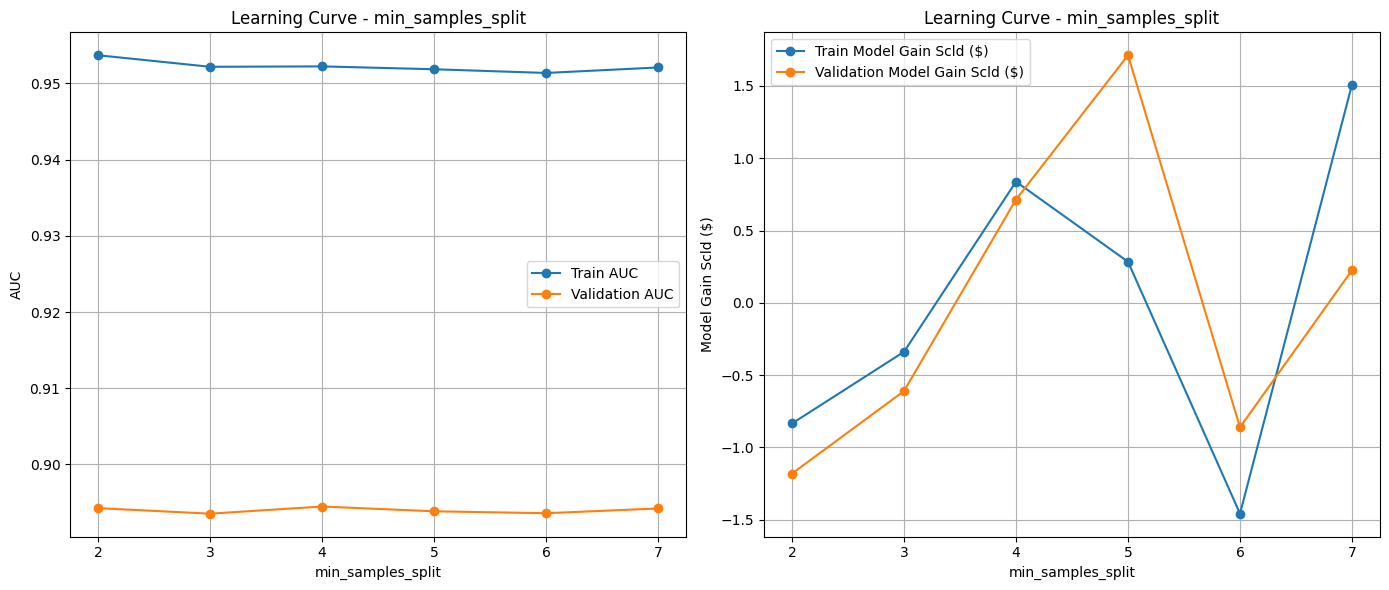

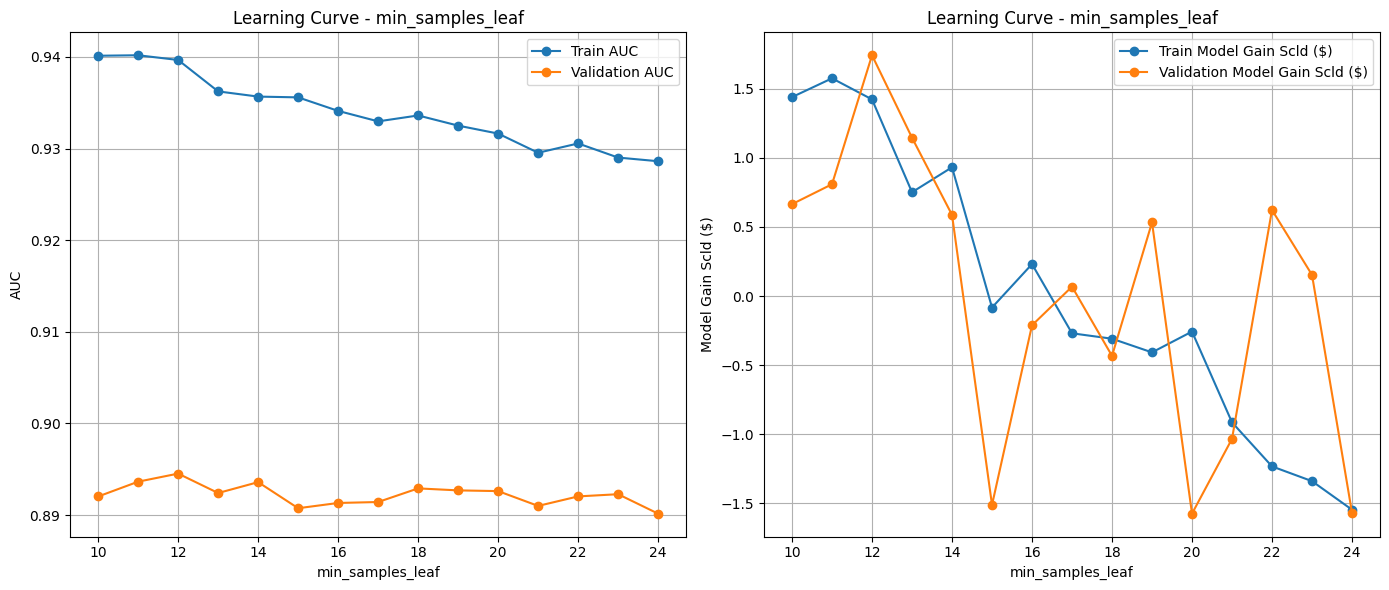

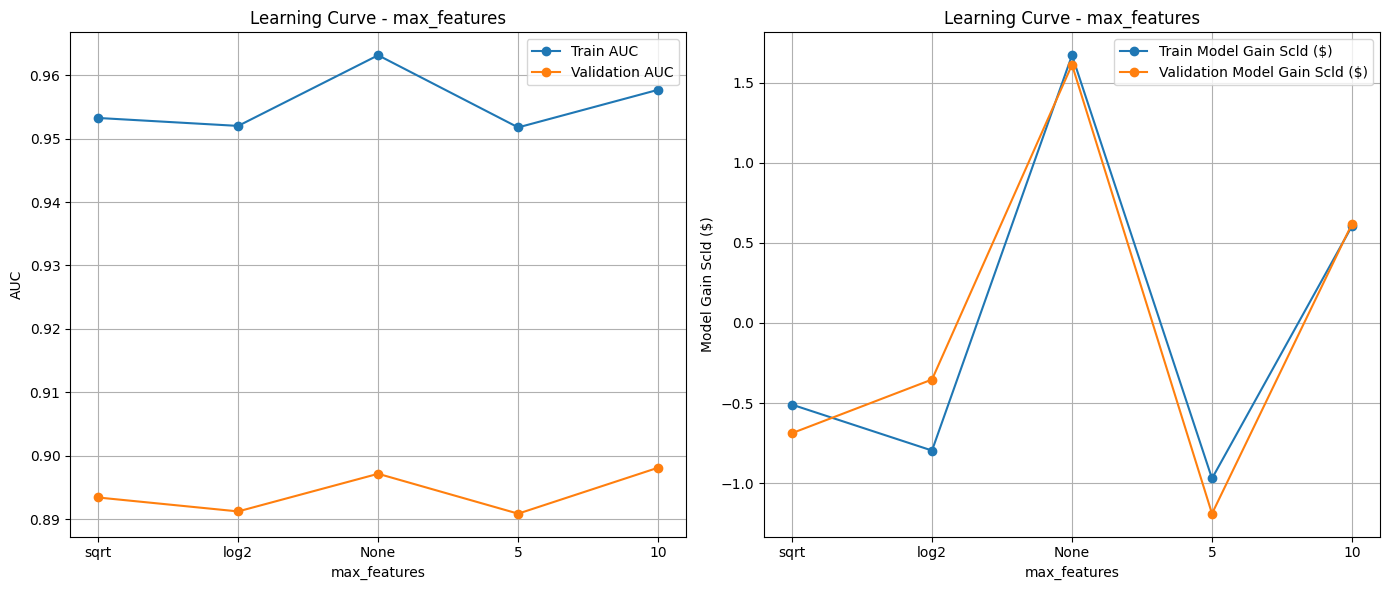

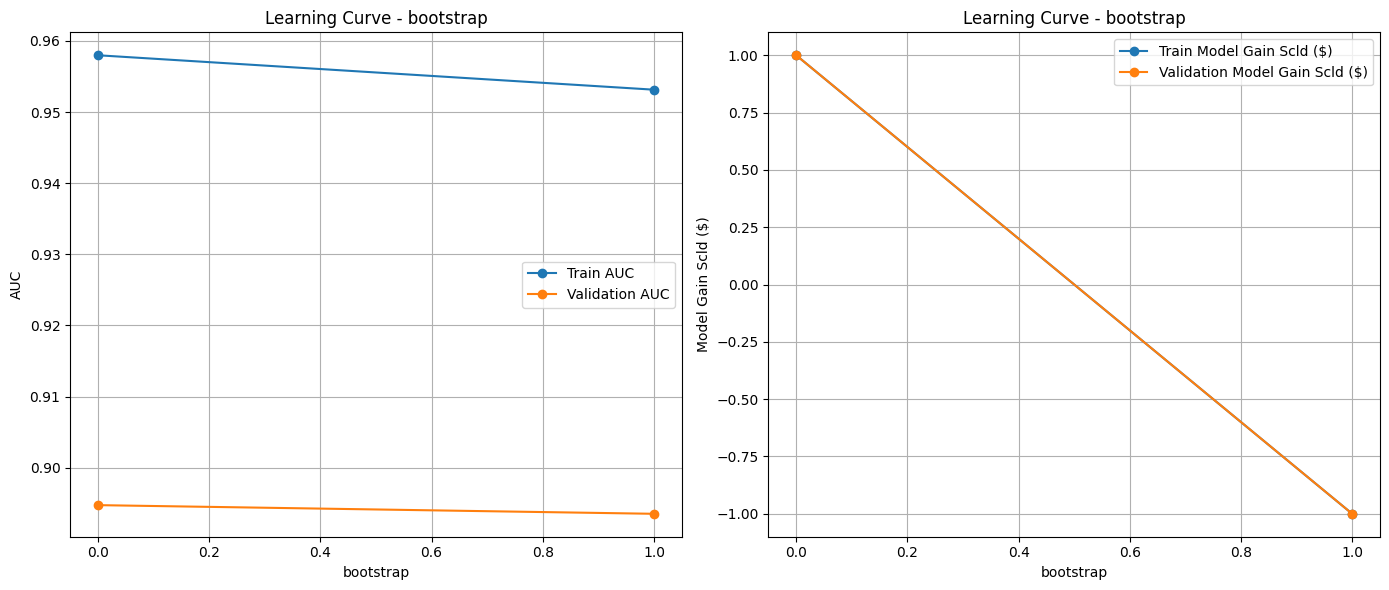

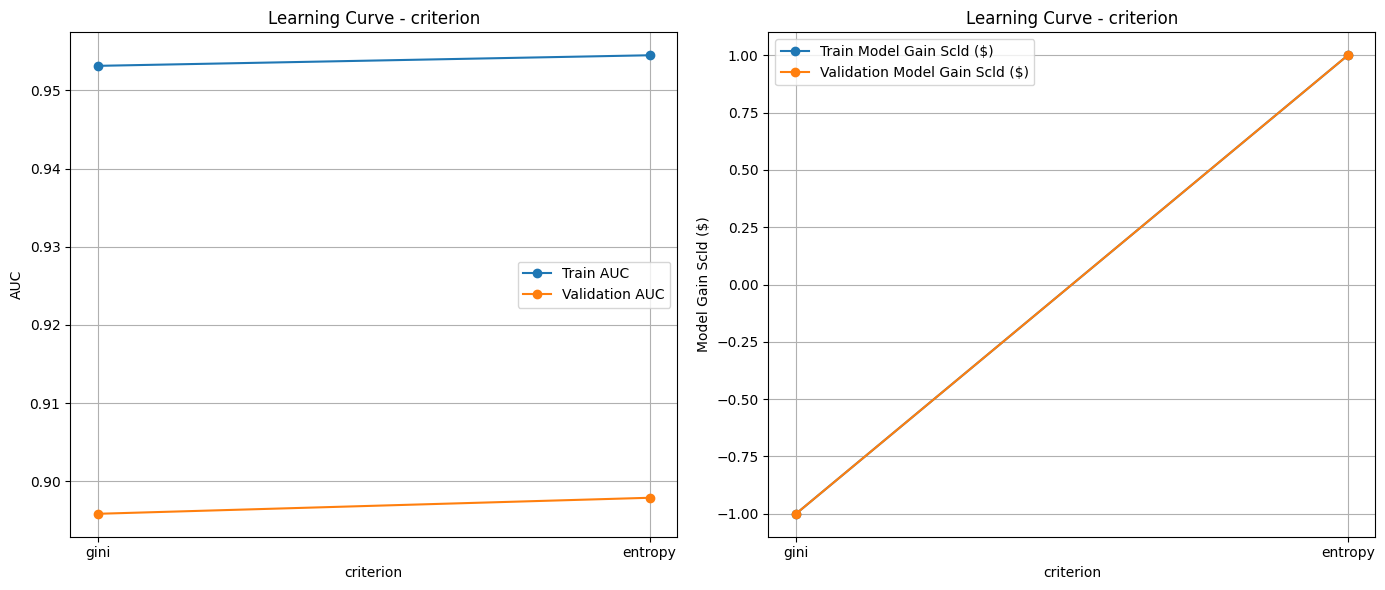

In [29]:
# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=None)

# Escalado
# std_scaler = StandardScaler()
# X_train_scld = std_scaler.fit_transform(X_train)
# X_val_scld = std_scaler.transform(X_val)
# X_test_scld = std_scaler.transform(X_test)

# Modelo
rf_base = RandomForestClassifier(max_depth=8)

# Parámetros
params_dict = {
    'n_estimators': [100, 200, 300, 400],                   # cantidad de árboles
    'max_depth': range(5, 16),                              # profundidad máxima de los árboles -> El que más afecta
    'min_samples_split': range(2, 8),                       # mínimo de muestras para hacer un split
    'min_samples_leaf': range(10, 25),                      # mínimo de muestras en una hoja -> Reduce performance de train, pero no de test
    'max_features': ['sqrt', 'log2', None, 5, 10],          # cantidad de features para dividir -> No afecta mucho
    'bootstrap': [True, False],                             # si usar bootstrap o no -> No afecta mucho
    'criterion': ['gini', 'entropy']                        # función para medir la calidad del split -> No afecta mucho
}


# Score Económico
eco_score_dict = {
    "avg_tkt": avg_tkt,
    "churn_like": churn_like,
    "churn_dislike": churn_dislike
}

# Ploteo de curvas de performance
mod_prep.plot_performance_curves(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    base_model=rf_base,
    params_dict=params_dict,
    eco_score_dict=eco_score_dict)

## RF SelectKBest

*Feature Selection*

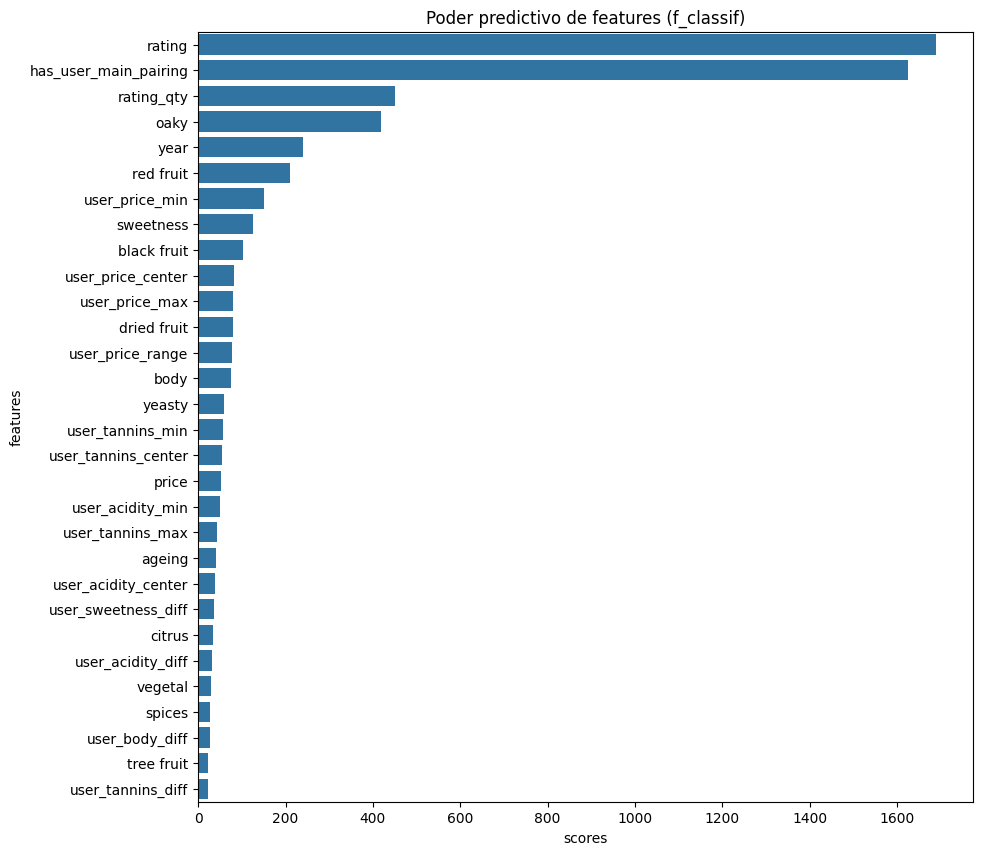

In [33]:
from sklearn.feature_selection import SelectKBest, f_classif

# Obtención de X e y
X = model_df_nocat.drop(columns=["liked"])
y = model_df_nocat["liked"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

# Train de selector
selector = SelectKBest(score_func=f_classif, k=30)
X_train_select = selector.fit_transform(X_train, y_train)

# Obtención de columnas y valores
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
scores = selector.scores_
pvalues = selector.pvalues_

# Formateo en Data Frame
features_scores = pd.DataFrame({
    "features": X.columns,
    "scores": scores,
    "pvalues": pvalues
})

# Selección de K
features_scores = features_scores[features_scores["features"].isin(selected_features)]
features_scores = features_scores.sort_values(by="scores", ascending=False)

# Gráfico
plt.figure(figsize=(10, 10))
sns.barplot(data=features_scores, y="features", x="scores")
plt.title("Poder predictivo de features (f_classif)")
plt.show()

In [51]:
selkbest_features = features_scores["features"].to_list()
drop_cols = ["user_price_center", "user_price_range", "user_tannins_center",
             "user_tannins_max", "user_tannins_diff", "user_acidity_center",
             "user_acidity_diff",
             ]
add_cols = ["acidity", "tannins", "user_price_diff"]
selkbest_features = [f for f in selkbest_features if f not in drop_cols]
selkbest_features += [f for f in add_cols if f not in selkbest_features]
selkbest_features

['rating',
 'has_user_main_pairing',
 'rating_qty',
 'oaky',
 'year',
 'red fruit',
 'user_price_min',
 'sweetness',
 'black fruit',
 'user_price_max',
 'dried fruit',
 'body',
 'yeasty',
 'user_tannins_min',
 'price',
 'user_acidity_min',
 'ageing',
 'user_sweetness_diff',
 'citrus',
 'vegetal',
 'spices',
 'user_body_diff',
 'tree fruit',
 'acidity',
 'tannins',
 'user_price_diff']

*Corr Matrix*

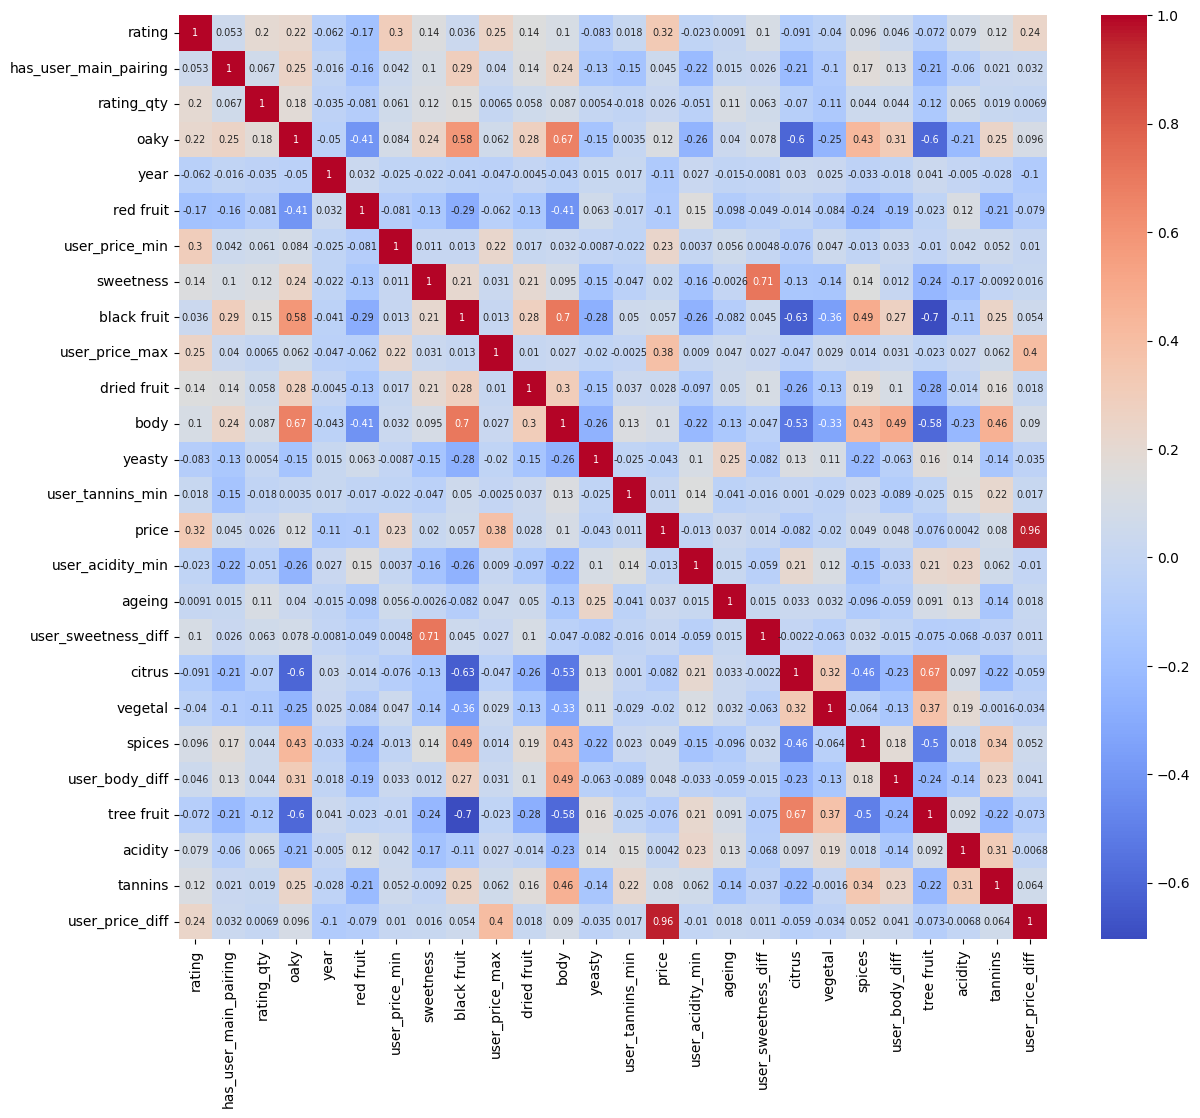

In [53]:
selkbest_rf_corr_matrix = model_df_nocat[selkbest_features].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(selkbest_rf_corr_matrix, cmap="coolwarm", annot=True, annot_kws={"fontsize": "x-small"})
plt.show()

*Performance con CV*

In [54]:
# X = model_df_nocat.drop(columns=["liked"])
X = model_df_nocat[selkbest_features]
y = model_df_nocat["liked"]

# Pipeline con oversampler y modelo para aplicarlo en cada Fold del CV
pipeline = Pipeline([
    ("rf", RandomForestClassifier())
])

# Aplicación de cross validation y obtención de métricas
skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

# Resumen de métricas del CV
metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

# Media, Desvío Estándar y Coef Var
metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef Var
roc_auc,0.911811,0.004054,0.004446
accuracy,0.837249,0.007756,0.009263
precision_macro,0.823567,0.007938,0.009638
recall_macro,0.810266,0.010798,0.013326
f1_macro,0.816015,0.009627,0.011797


*Learning Curves*

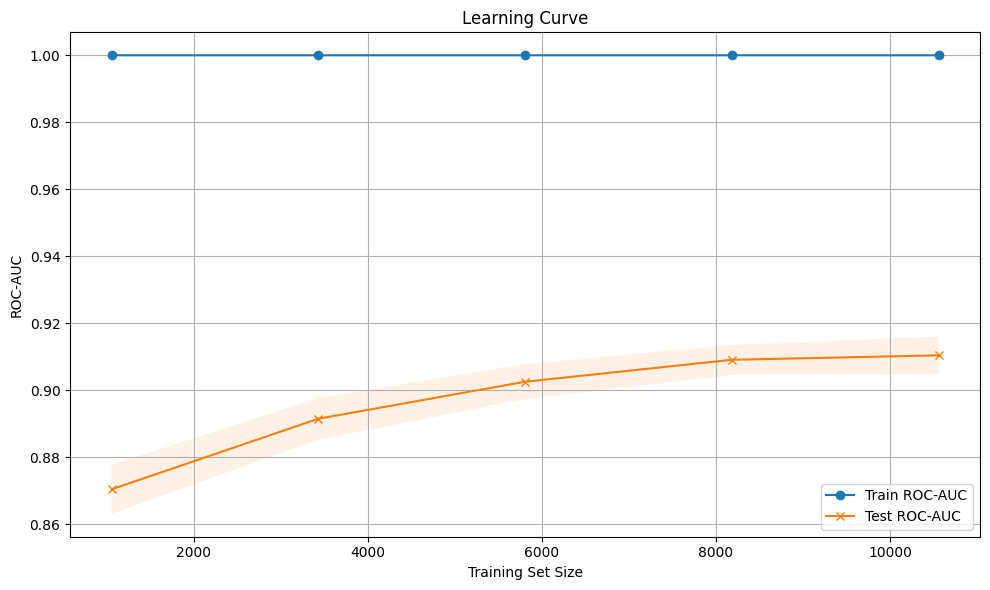

In [55]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

*Performance Curves*

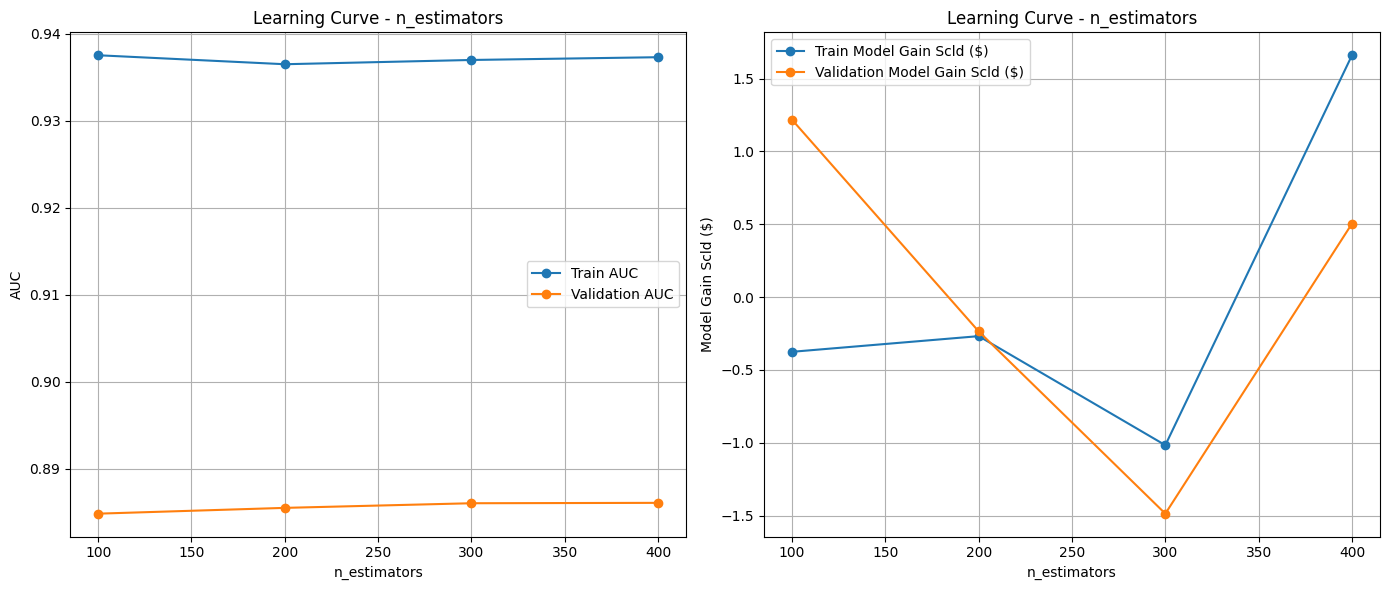

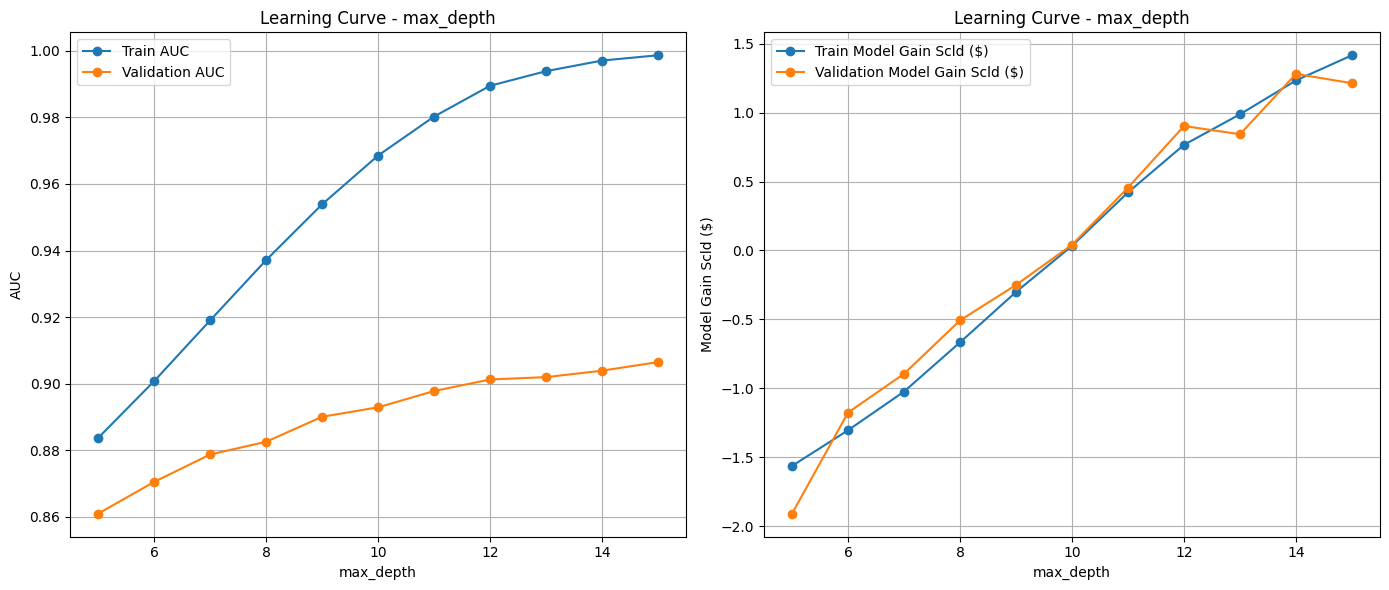

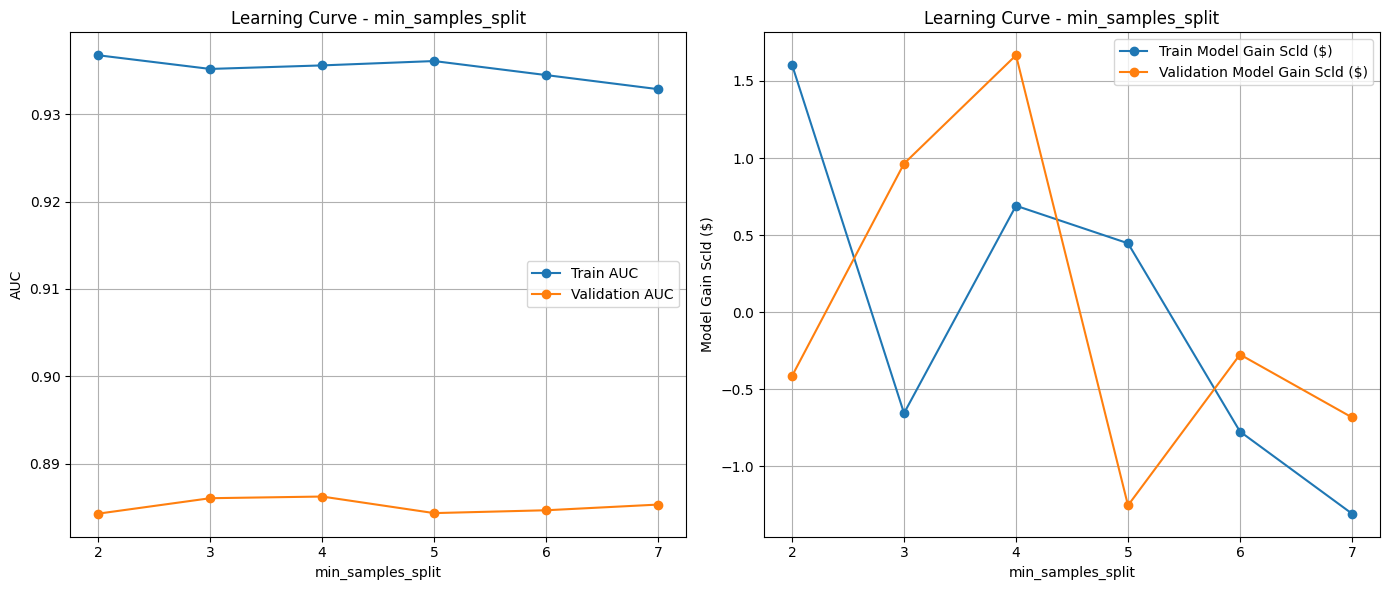

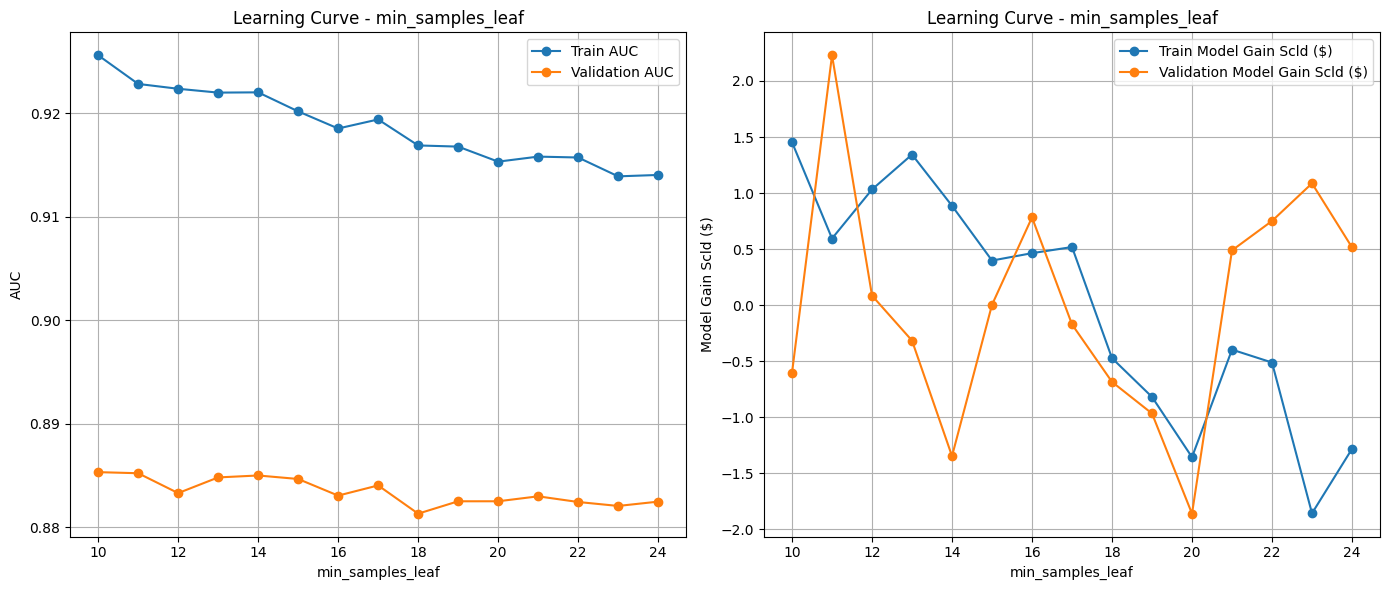

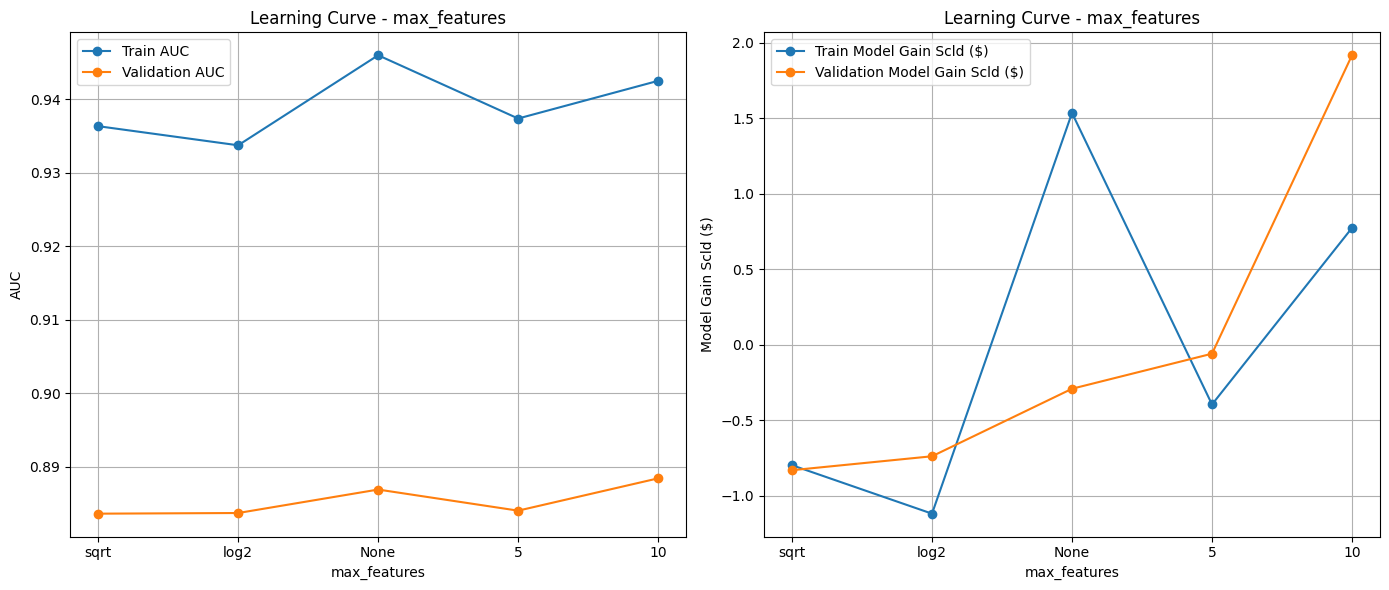

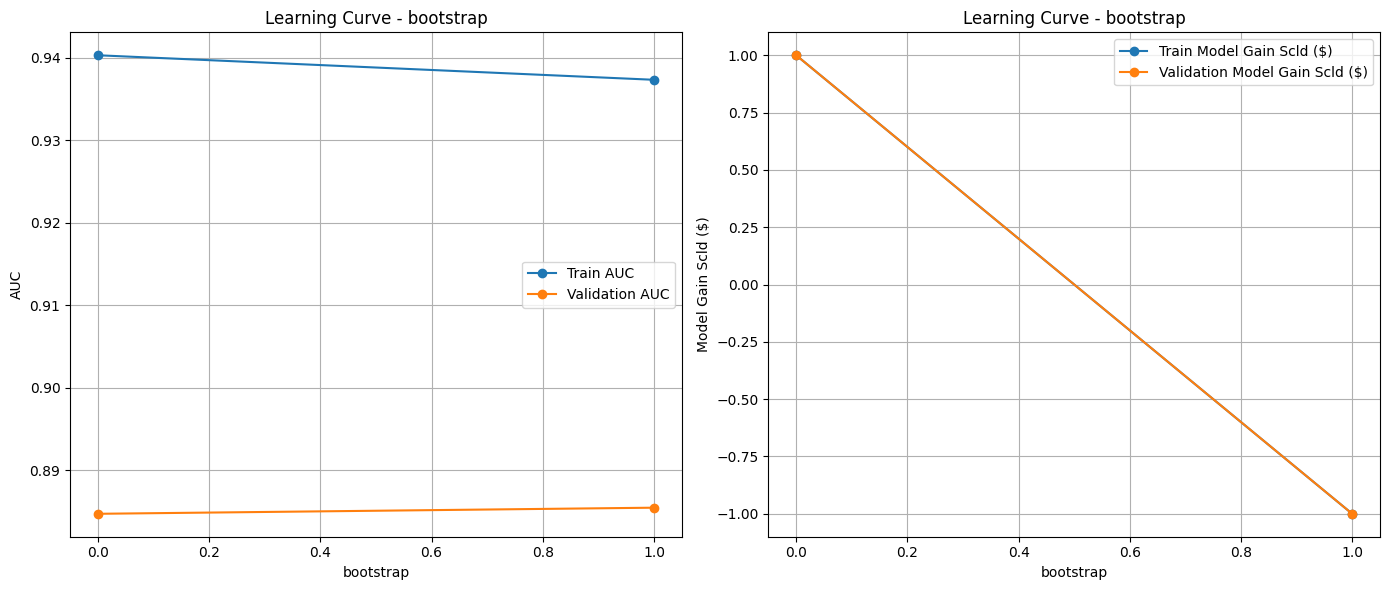

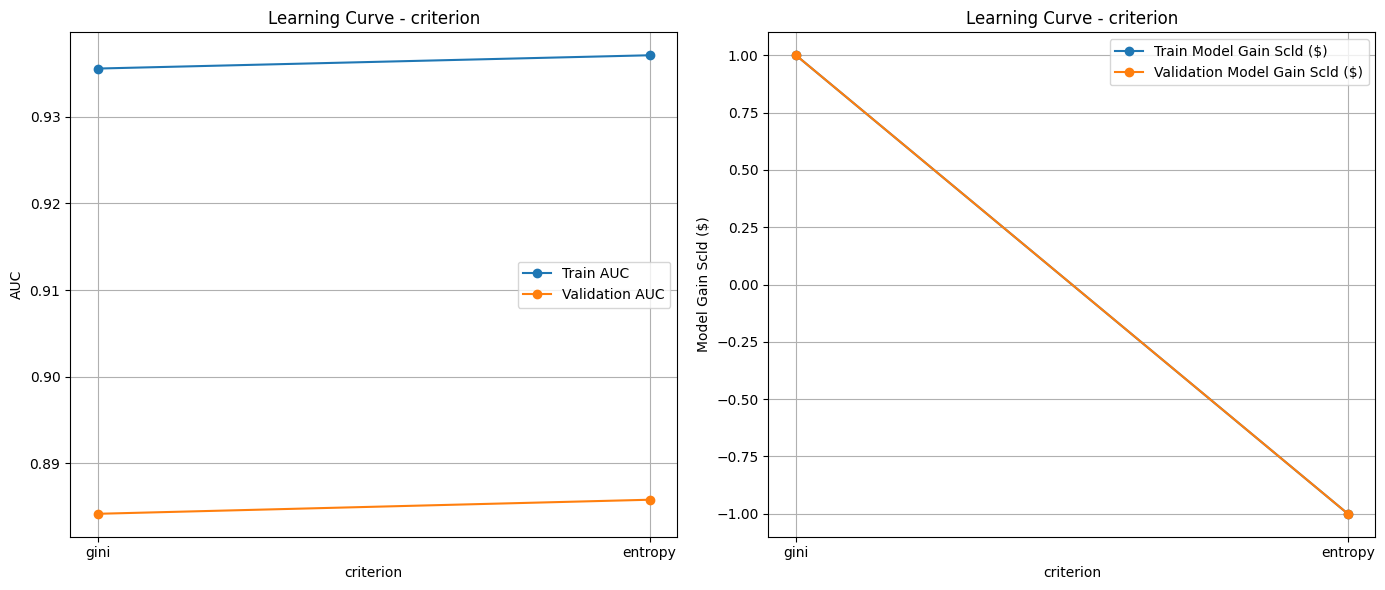

In [56]:
# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=None)

# Escalado
# std_scaler = StandardScaler()
# X_train_scld = std_scaler.fit_transform(X_train)
# X_val_scld = std_scaler.transform(X_val)
# X_test_scld = std_scaler.transform(X_test)

# Modelo
rf_base = RandomForestClassifier(max_depth=8)

# Parámetros
params_dict = {
    'n_estimators': [100, 200, 300, 400],                   # cantidad de árboles
    'max_depth': range(5, 16),                              # profundidad máxima de los árboles -> El que más afecta
    'min_samples_split': range(2, 8),                       # mínimo de muestras para hacer un split
    'min_samples_leaf': range(10, 25),                      # mínimo de muestras en una hoja -> Reduce performance de train, pero no de test
    'max_features': ['sqrt', 'log2', None, 5, 10],          # cantidad de features para dividir -> No afecta mucho
    'bootstrap': [True, False],                             # si usar bootstrap o no -> No afecta mucho
    'criterion': ['gini', 'entropy']                        # función para medir la calidad del split -> No afecta mucho
}


# Score Económico
eco_score_dict = {
    "avg_tkt": avg_tkt,
    "churn_like": churn_like,
    "churn_dislike": churn_dislike
}

# Ploteo de curvas de performance
mod_prep.plot_performance_curves(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    base_model=rf_base,
    params_dict=params_dict,
    eco_score_dict=eco_score_dict)

## RF SFS Selected

- Realizar el SFS con RandomForest y todas las features tarda muchísimo. Lo realizamos luego de SelectKBest.

*Feature Selection*

In [57]:
# Depende del step anterior
selected_k_best_features = features_scores["features"]

X = model_df_nocat[selected_k_best_features]
y = model_df_nocat["liked"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

rf = RandomForestClassifier(max_depth=8)

sfs = SequentialFeatureSelector(
    estimator=rf,
    n_features_to_select=15,
    direction="forward",
    scoring="roc_auc",
    cv=5
)

sfs.fit(X_train, y_train)

SequentialFeatureSelector(estimator=RandomForestClassifier(max_depth=8),
                          n_features_to_select=15, scoring='roc_auc')

In [59]:
X = model_df_nocat[selected_k_best_features]
y = model_df_nocat["liked"]
sfs_features = X.loc[:, sfs.get_support()].columns.to_list()
# other_features = ["black fruit"]
# sfs_features += [f for f in other_features if f not in sfs_features]
# drop_cols = ["user_acidity_min", "user_acidity_max", "user_acidity_center", "tree fruit", "tropical", "sweetness", "body", "ageing", "dried fruit"]
# sfs_features = [f for f in sfs_features if f not in drop_cols]
sfs_features

['rating',
 'has_user_main_pairing',
 'rating_qty',
 'user_price_min',
 'user_price_center',
 'user_price_max',
 'body',
 'user_tannins_min',
 'price',
 'user_acidity_min',
 'user_tannins_max',
 'user_sweetness_diff',
 'user_acidity_diff',
 'user_body_diff',
 'user_tannins_diff']

In [10]:
# Manual para evitar ejecutar el código (20min+)
sfs_features = ['rating',
 'has_user_main_pairing',
 'rating_qty',
 'user_price_min',
 'user_price_center',
 'user_price_max',
 'body',
 'user_tannins_min',
 'price',
 'user_acidity_min',
 'user_tannins_max',
 'user_sweetness_diff',
 'user_acidity_diff',
 'user_body_diff',
 'user_tannins_diff']

# other_features = ["black fruit"]
# sfs_features += [f for f in other_features if f not in sfs_features]
# drop_cols = ["user_acidity_min", "user_acidity_max", "user_acidity_center", "tree fruit", "tropical", "sweetness", "body", "ageing", "dried fruit"]
# sfs_features = [f for f in sfs_features if f not in drop_cols]

X = model_df_nocat[sfs_features]
y = model_df_nocat["liked"]

*Corr Matrix*

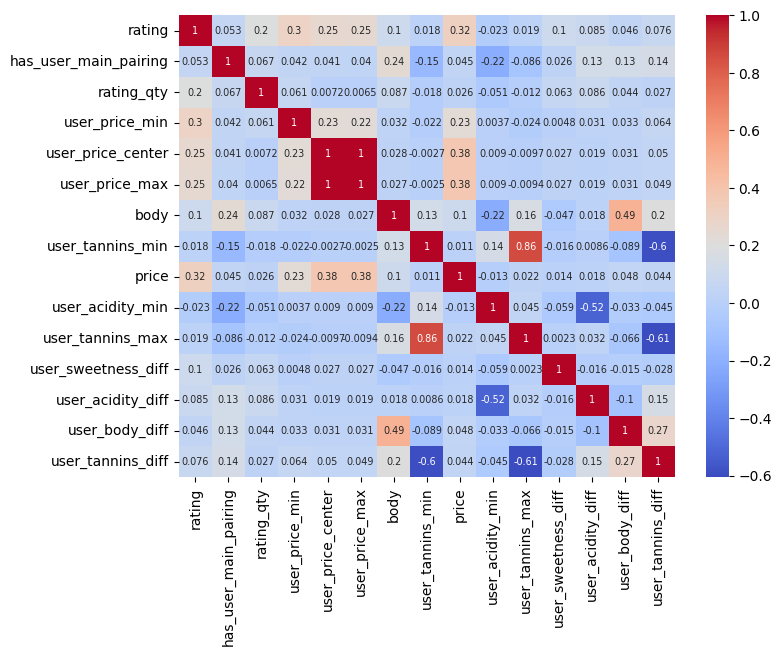

In [11]:
# Revisamos que no haya fuerte correlación (colinealidad)
sfs_rf_corr_matrix = X[sfs_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(sfs_rf_corr_matrix, cmap="coolwarm", annot=True, annot_kws={"fontsize": "x-small"})
plt.show()

*Performance con CV*

In [12]:
X = model_df_nocat[sfs_features]
y = model_df_nocat["liked"]

# Pipeline con oversampler y modelo para aplicarlo en cada Fold del CV
pipeline = Pipeline([
    ("rf", RandomForestClassifier())
])

# Aplicación de cross validation y obtención de métricas
skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

# Resumen de métricas del CV
metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

# Media, Desvío Estándar y Coef Var
metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef Var
roc_auc,0.924281,0.004879,0.005279
accuracy,0.849371,0.003761,0.004428
precision_macro,0.836829,0.004743,0.005667
recall_macro,0.825163,0.005105,0.006186
f1_macro,0.830301,0.004346,0.005234


*Learning Curves*

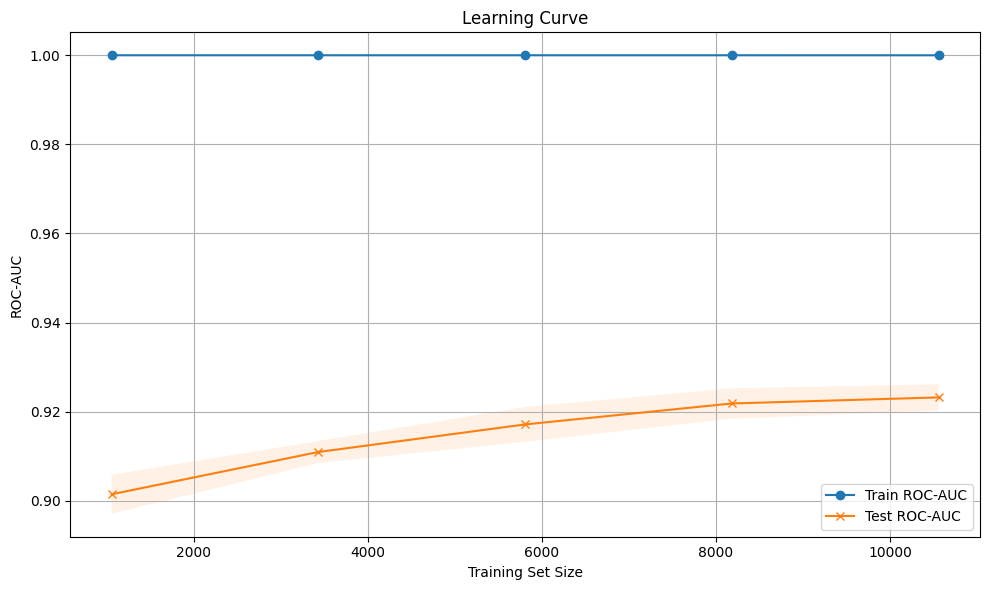

In [16]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

*Performance Curves*

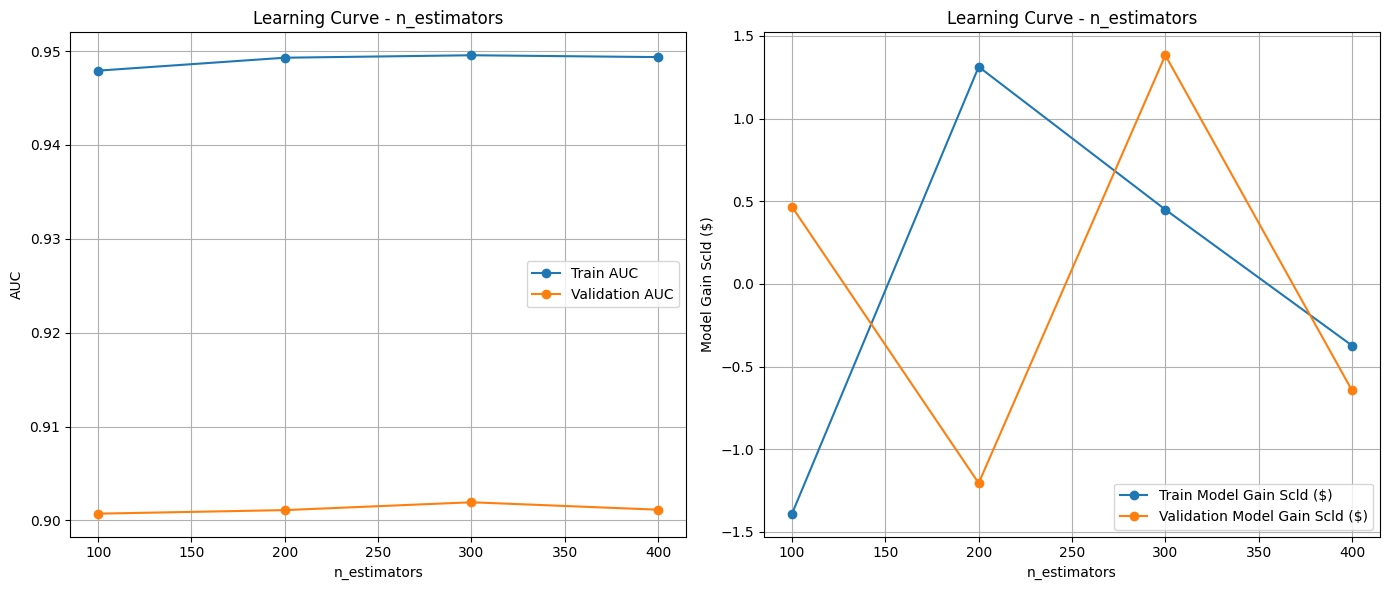

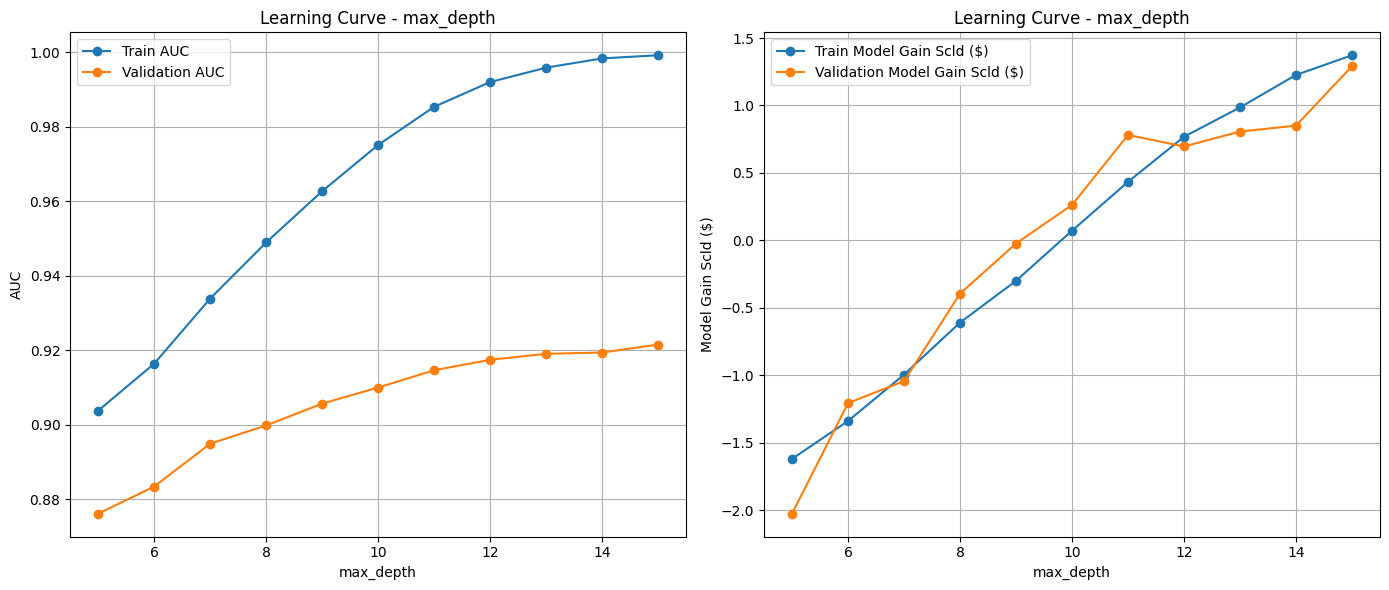

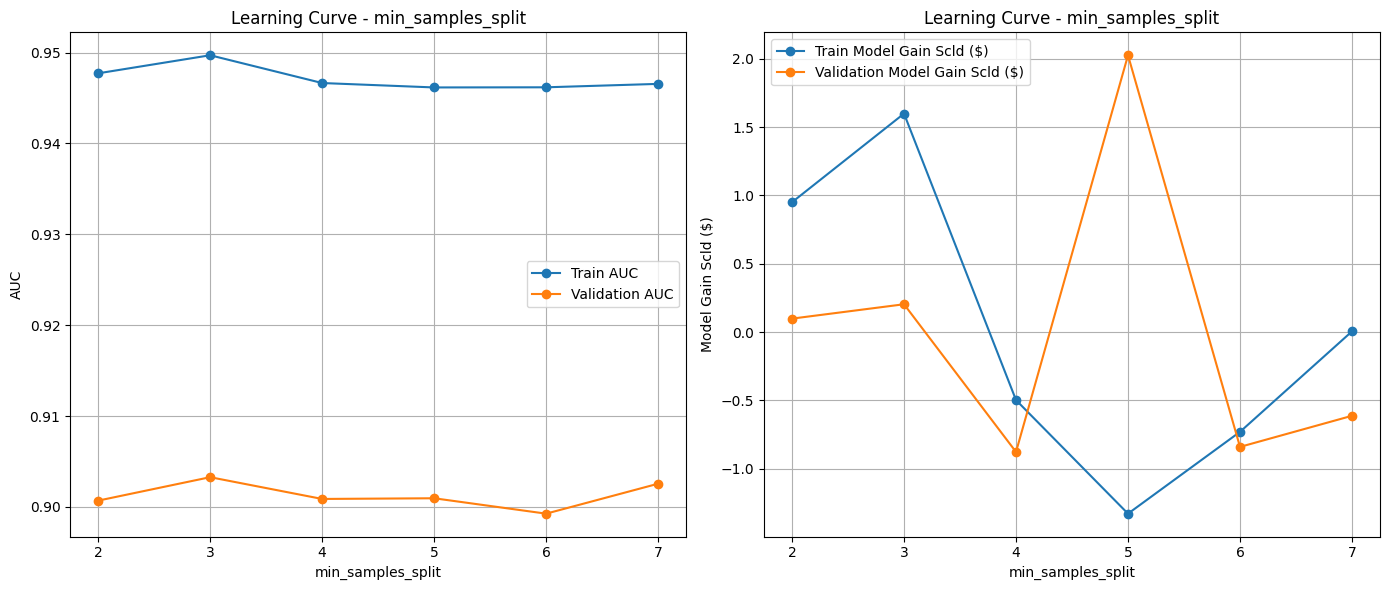

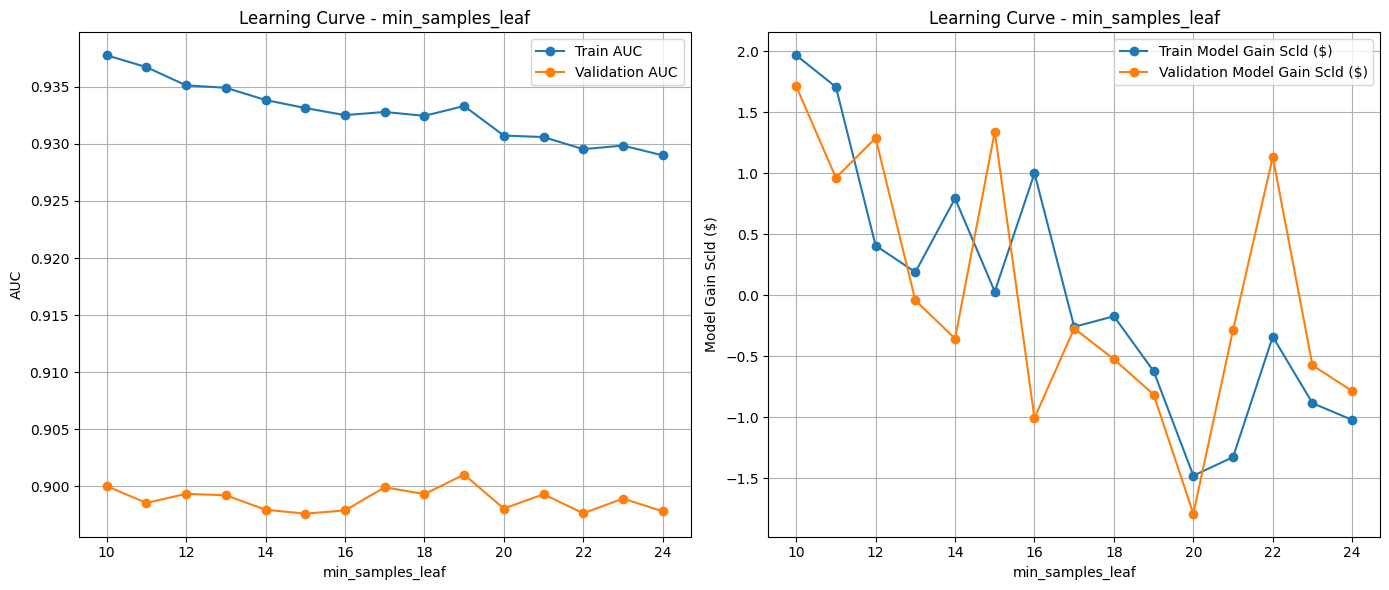

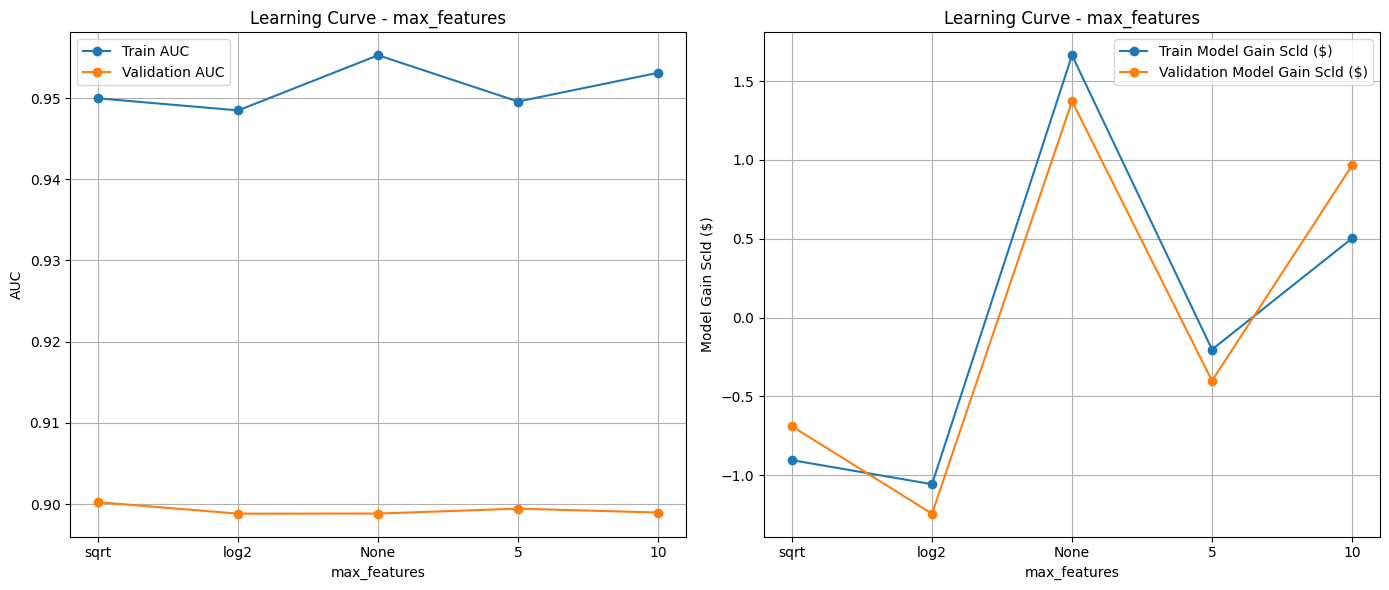

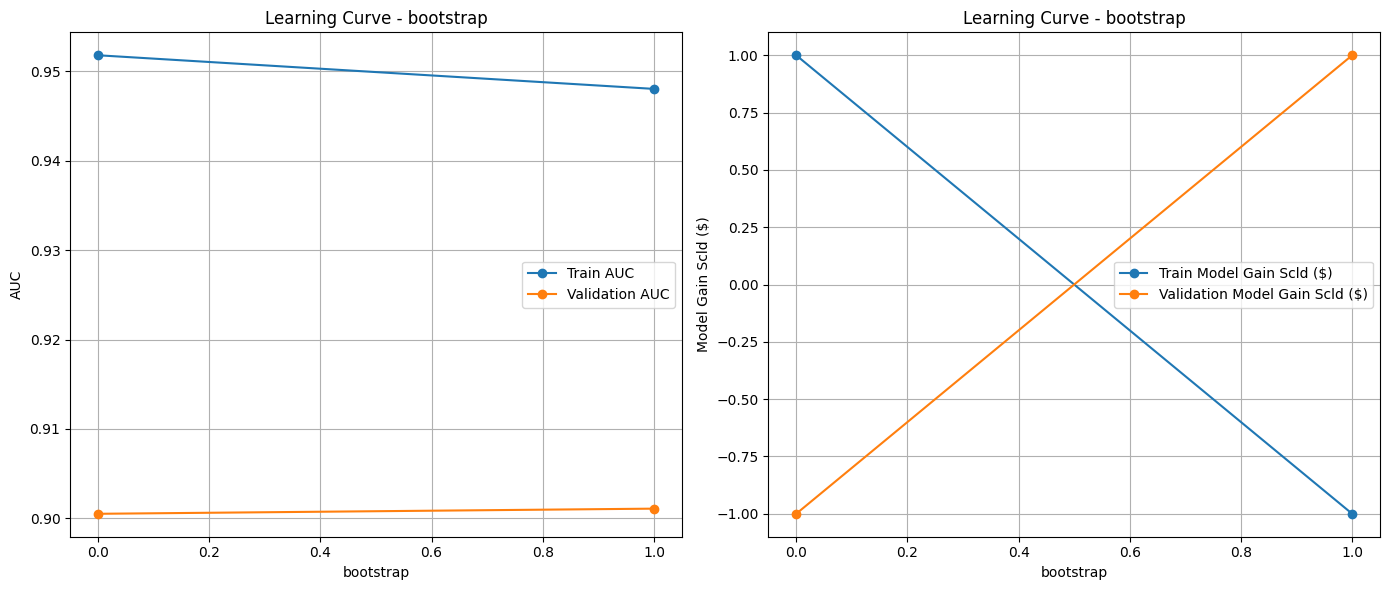

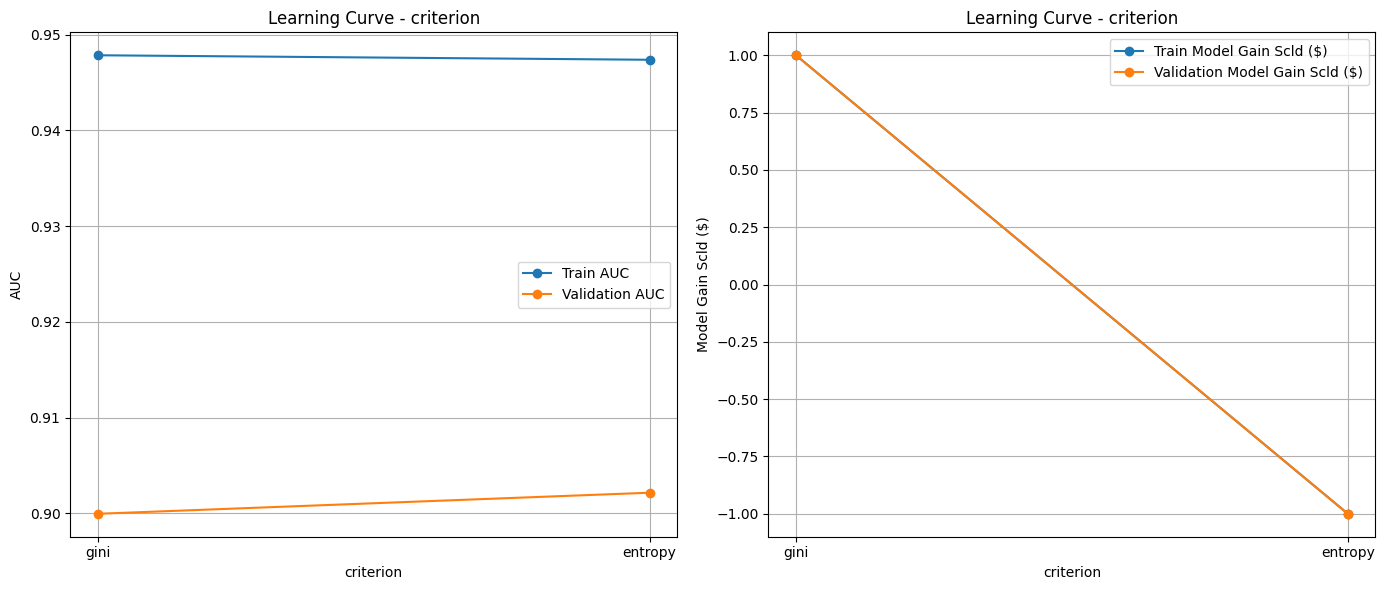

In [ ]:
# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=None)

# Escalado
# std_scaler = StandardScaler()
# X_train_scld = std_scaler.fit_transform(X_train)
# X_val_scld = std_scaler.transform(X_val)
# X_test_scld = std_scaler.transform(X_test)

# Modelo
rf = RandomForestClassifier(max_depth=8)

# Parámetros
params_dict = {
    'n_estimators': [100, 200, 300, 400],                   # cantidad de árboles
    'max_depth': range(5, 16),                              # profundidad máxima de los árboles -> El que más afecta
    'min_samples_split': range(2, 8),                       # mínimo de muestras para hacer un split
    'min_samples_leaf': range(10, 25),                      # mínimo de muestras en una hoja -> Reduce performance de train, pero no de test
    'max_features': ['sqrt', 'log2', None, 5, 10],          # cantidad de features para dividir -> No afecta mucho
    'bootstrap': [True, False],                             # si usar bootstrap o no -> No afecta mucho
    'criterion': ['gini', 'entropy']                        # función para medir la calidad del split -> No afecta mucho
}


# Score Económico
eco_score_dict = {
    "avg_tkt": avg_tkt,
    "churn_like": churn_like,
    "churn_dislike": churn_dislike
}

# Ploteo de curvas de performance
mod_prep.plot_performance_curves(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    base_model=rf_base,
    params_dict=params_dict,
    eco_score_dict=eco_score_dict)

## RF Feature Importance Selected

*Feature Selection*

In [13]:
X = model_df_nocat.drop(columns=["liked"])
y = model_df_nocat["liked"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

#  DataFrame de Feature Importance
feature_importance = pd.DataFrame({
    "features": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance = feature_importance.reset_index(drop=True)
feature_importance

,features,importance
0,rating_qty,0.087152
1,has_user_main_pairing,0.066855
2,rating,0.048848
3,user_body_diff,0.048793
4,user_acidity_diff,0.046338
5,user_sweetness_diff,0.044434
6,user_tannins_diff,0.035459
7,user_price_diff,0.034724
8,user_price_center,0.022579
9,sweetness,0.021222


In [49]:
fisel_features = feature_importance.head(17)["features"]

drop_cols = ["user_body_center", "user_price_range", "user_acidity_center", "user_tannins_center", "user_body_max", "sweetness", "floral", "user_body_min", "oaky"]
fisel_features = [f for f in fisel_features if f not in drop_cols]

#add_cols = [
    #"acidity",
    #"tannins",
    #"body",
    #"price"]
    
#fisel_features += [f for f in add_cols if f not in fisel_features]

fisel_features

['rating_qty',
 'has_user_main_pairing',
 'rating',
 'user_body_diff',
 'user_acidity_diff',
 'user_sweetness_diff',
 'user_tannins_diff',
 'user_price_diff',
 'user_price_center',
 'price']

*Corr Matrix*

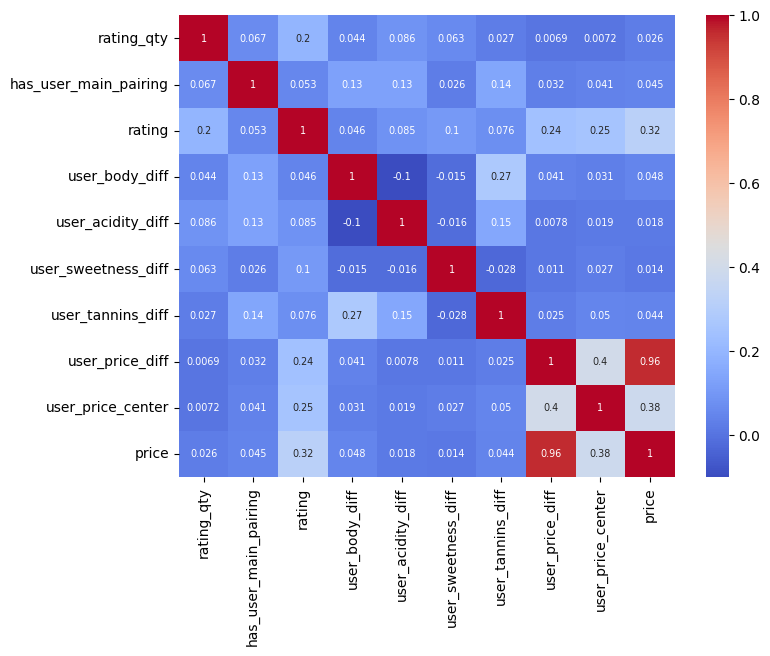

In [50]:
# Revisamos que no haya fuerte correlación (colinealidad)
fisel_corr_matrix = model_df_nocat[fisel_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(fisel_corr_matrix, cmap="coolwarm", annot=True, annot_kws={"fontsize": "x-small"})
plt.show()

*Performance con CV*

In [51]:
X = model_df_nocat[fisel_features]
y = model_df_nocat["liked"]

# Pipeline con oversampler y modelo para aplicarlo en cada Fold del CV
pipeline = Pipeline([
    ("rf", RandomForestClassifier())
])

# Aplicación de cross validation y obtención de métricas
skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

# Resumen de métricas del CV
metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

# Media, Desvío Estándar y Coef Var
metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef Var
roc_auc,0.930330,0.003369,0.003621
accuracy,0.855432,0.005470,0.006394
precision_macro,0.843363,0.005189,0.006152
recall_macro,0.832454,0.008348,0.010028
f1_macro,0.837308,0.006934,0.008281


*Learning Curves*

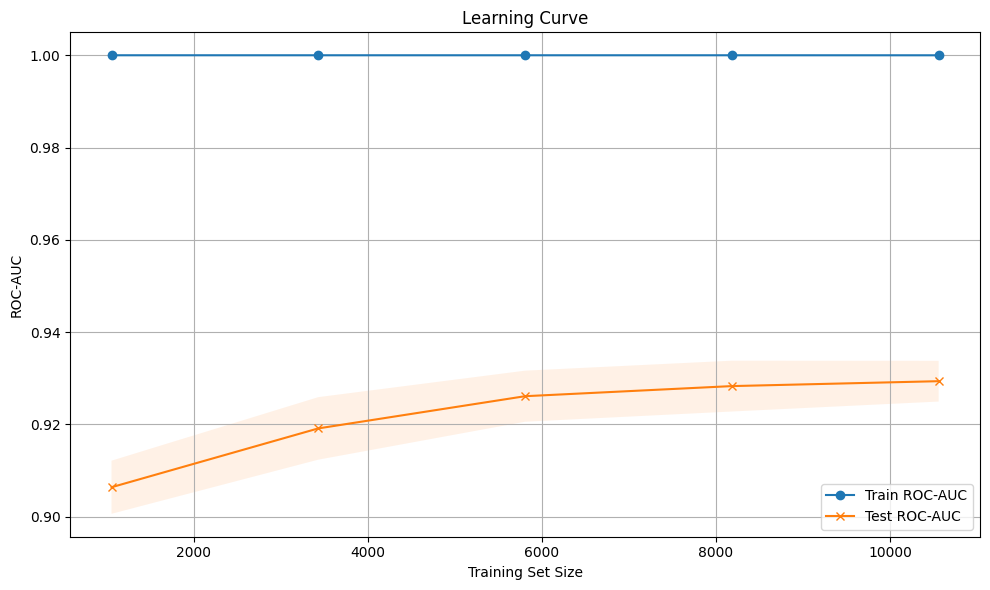

In [52]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

*Performance Curves*

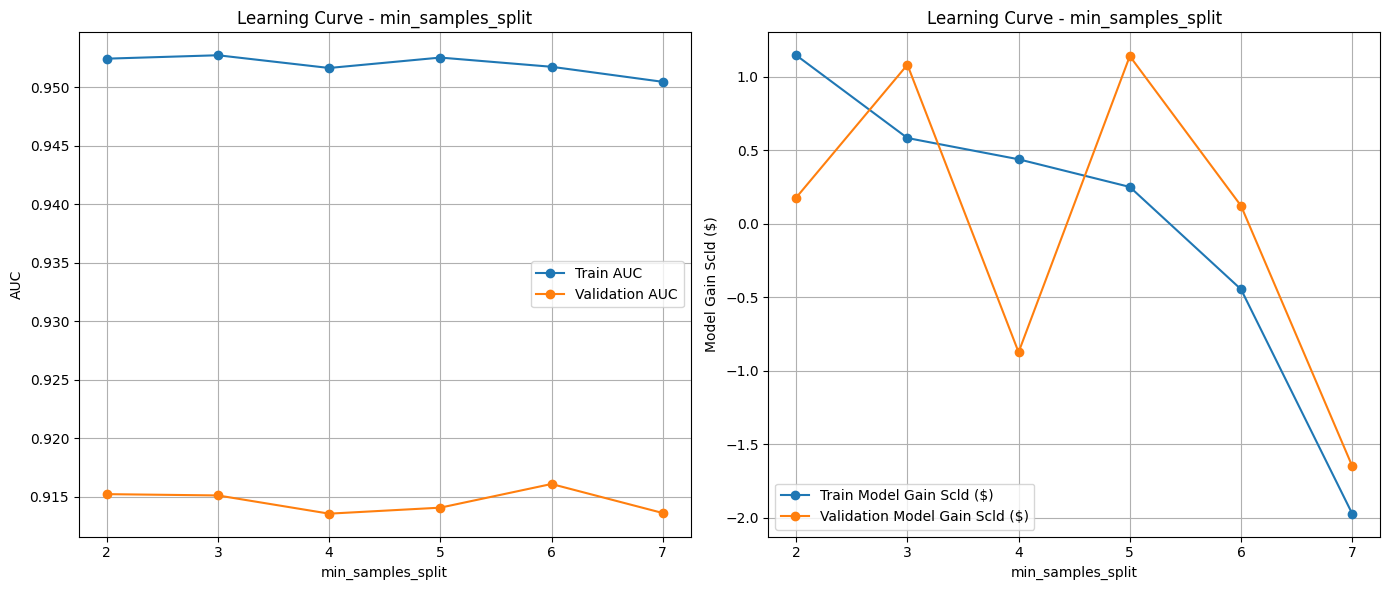

In [58]:
# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=None)

# Escalado
# std_scaler = StandardScaler()
# X_train_scld = std_scaler.fit_transform(X_train)
# X_val_scld = std_scaler.transform(X_val)
# X_test_scld = std_scaler.transform(X_test)

# Modelo
rf = RandomForestClassifier(max_depth=8)

# Parámetros
params_dict = {
    # 'n_estimators': [100, 200, 300, 400],                   # cantidad de árboles
    # 'max_depth': range(5, 16),                              # profundidad máxima de los árboles -> El que más afecta
     'min_samples_split': range(2, 8),                       # mínimo de muestras para hacer un split
    #'min_samples_leaf': range(1, 25),                      # mínimo de muestras en una hoja -> Reduce performance de train, pero no de test
    # 'max_features': ['sqrt', 'log2', None, 5, 10],          # cantidad de features para dividir -> No afecta mucho
    # 'bootstrap': [True, False],                             # si usar bootstrap o no -> No afecta mucho
    # 'criterion': ['gini', 'entropy']                        # función para medir la calidad del split -> No afecta mucho
}


# Score Económico
eco_score_dict = {
    "avg_tkt": avg_tkt,
    "churn_like": churn_like,
    "churn_dislike": churn_dislike
}

# Ploteo de curvas de performance
mod_prep.plot_performance_curves(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    base_model=rf,
    params_dict=params_dict,
    eco_score_dict=eco_score_dict)

# Finetunning RF

In [73]:
# Creación de score económico personalizado
def economic_score_scorer(y_true, y_pred):
    conf = confusion_matrix(y_true, y_pred)
    return mod_prep.economic_score(
        conf_matrix=conf,
        avg_tkt=avg_tkt,
        churn_like=churn_like,
        churn_dislike=churn_dislike
    )

custom_scorer = make_scorer(economic_score_scorer, greater_is_better=True)

In [ ]:
# Búsqueda inicial de parámetros con Randomized Search
from sklearn.model_selection import RandomizedSearchCV

# Elección de features
fisel_features = [
    'rating_qty',
    'has_user_main_pairing',
    'rating',
    'user_body_diff',
    'user_acidity_diff',
    'user_sweetness_diff',
    'user_tannins_diff',
    'user_price_diff',
    'user_price_center',
    'price'
]

# Obtención de datos (X, y)
X = model_df_nocat[fisel_features]
y = model_df_nocat["liked"]

# Split de datos (train, test)
X_train, X_test, y_train, y_test = mod_prep.train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

# Creación de Pipeline
pipeline = Pipeline([
    ("rf", RandomForestClassifier(
        n_estimators=100,
        max_features='log2',
        bootstrap=True,
        criterion='entropy'
    ))
])

# Cross Validation Stratified
skf = StratifiedKFold(n_splits=5, shuffle=True)

# Parametros del Grid
param_distribs= {
    #'rf__n_estimators': [100, 150, 200, 250, 300],                   # cantidad de árboles
    'rf__max_depth': range(5, 13),                              # profundidad máxima de los árboles -> El que más afecta
    'rf__min_samples_split': range(2, 8),                       # mínimo de muestras para hacer un split
    'rf__min_samples_leaf': range(5, 15),                      # mínimo de muestras en una hoja -> Reduce performance de train, pero no de test
    #'rf__max_features': ['sqrt', 'log2', None, 5, 10],          # cantidad de features para dividir -> No afecta mucho
    #'rf__bootstrap': [True, False],                             # si usar bootstrap o no -> No afecta mucho
    #'rf__criterion': ['gini', 'entropy']                        # función para medir la calidad del split -> No afecta mucho
}

# Scoring
scoring_metrics = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "economic_scorer": custom_scorer
}

# Random Search
random_search = RandomizedSearchCV(
    pipeline,
    param_distribs,
    n_iter=20,
    scoring=scoring_metrics,
    refit="roc_auc",
    cv=skf,
    n_jobs=1
)

random_search.fit(X_train, y_train)

# Resultados
grid_results = pd.DataFrame(random_search.cv_results_)
summary_results = grid_results[["mean_test_accuracy", "mean_test_roc_auc", "mean_test_economic_scorer", "param_rf__min_samples_split", "param_rf__min_samples_leaf", "param_rf__max_depth"]].sort_values(by="mean_test_roc_auc", ascending=False)
summary_results = summary_results.reset_index(drop=True)
summary_results

,mean_test_accuracy,mean_test_roc_auc,mean_test_economic_scorer,params
13,0.852056,0.930798,29945.685439,"{'rf__min_samples_split': 3, 'rf__min_samples_..."
18,0.850256,0.929771,29807.694567,"{'rf__min_samples_split': 6, 'rf__min_samples_..."
4,0.850445,0.927753,29785.064470,"{'rf__min_samples_split': 4, 'rf__min_samples_..."
8,0.848077,0.927438,29661.478995,"{'rf__min_samples_split': 4, 'rf__min_samples_..."
7,0.851581,0.927364,29844.934947,"{'rf__min_samples_split': 5, 'rf__min_samples_..."
19,0.849593,0.926931,29746.100563,"{'rf__min_samples_split': 3, 'rf__min_samples_..."
14,0.847603,0.925989,29610.920596,"{'rf__min_samples_split': 7, 'rf__min_samples_..."
0,0.847319,0.925894,29548.856202,"{'rf__min_samples_split': 4, 'rf__min_samples_..."
9,0.847793,0.924935,29561.854106,"{'rf__min_samples_split': 6, 'rf__min_samples_..."
15,0.846278,0.924683,29473.259068,"{'rf__min_samples_split': 4, 'rf__min_samples_..."


In [96]:
# Búsqueda Fina con GridSearch

# Elección de features
fisel_features = [
    'rating_qty',
    'has_user_main_pairing',
    'rating',
    'user_body_diff',
    'user_acidity_diff',
    'user_sweetness_diff',
    'user_tannins_diff',
    'user_price_diff',
    'user_price_center',
    'price'
]

# Obtención de datos (X, y)
X = model_df_nocat[fisel_features]
y = model_df_nocat["liked"]

# Split de datos (train, test)
X_train, X_test, y_train, y_test = mod_prep.train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

# Creación de Pipeline
pipeline = Pipeline([
    ("rf", RandomForestClassifier(
        n_estimators=100,
        max_features='log2',
        bootstrap=True,
        criterion='entropy'
    ))
])

# Cross Validation Stratified
skf = StratifiedKFold(n_splits=5, shuffle=True)

# Parametros del Grid
param_grid= {
    #'rf__n_estimators': [100, 150, 200, 250, 300],                   # cantidad de árboles
    'rf__max_depth': [10],                              # profundidad máxima de los árboles -> El que más afecta
    'rf__min_samples_split': [7, 8, 9],                       # mínimo de muestras para hacer un split
    'rf__min_samples_leaf': [7, 10, 12],                      # mínimo de muestras en una hoja -> Reduce performance de train, pero no de test
    #'rf__max_features': ['sqrt', 'log2', None, 5, 10],          # cantidad de features para dividir -> No afecta mucho
    #'rf__bootstrap': [True, False],                             # si usar bootstrap o no -> No afecta mucho
    #'rf__criterion': ['gini', 'entropy']                        # función para medir la calidad del split -> No afecta mucho
}

# Scoring
scoring_metrics = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "economic_scorer": custom_scorer
}

# Random Search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring=scoring_metrics,
    refit="roc_auc",
    cv=skf,
    n_jobs=1
)

grid_search.fit(X_train, y_train)

# Resultados
grid_results = pd.DataFrame(grid_search.cv_results_)
summary_results = grid_results[["mean_test_accuracy", "mean_test_roc_auc", "mean_test_economic_scorer", "param_rf__min_samples_split", "param_rf__min_samples_leaf", "param_rf__max_depth"]].sort_values(by="mean_test_roc_auc", ascending=False)
summary_results = summary_results.reset_index(drop=True)
summary_results

,mean_test_accuracy,mean_test_roc_auc,mean_test_economic_scorer,param_rf__min_samples_split,param_rf__min_samples_leaf,param_rf__max_depth
0,0.848834,0.925801,29641.865159,9,7,10
1,0.849403,0.925601,29689.512551,7,7,10
2,0.848834,0.925429,29667.087007,8,7,10
3,0.848740,0.925301,29642.100091,7,10,10
4,0.848361,0.925198,29629.679870,9,10,10
5,0.846845,0.925053,29524.931809,8,10,10
6,0.848360,0.924687,29617.213630,9,12,10
7,0.846466,0.924342,29502.135199,8,12,10
8,0.847508,0.923887,29557.543572,7,12,10


# Evaluación Final RF


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      3632
           1       0.89      0.95      0.92      6926

    accuracy                           0.89     10558
   macro avg       0.89      0.86      0.87     10558
weighted avg       0.89      0.89      0.89     10558



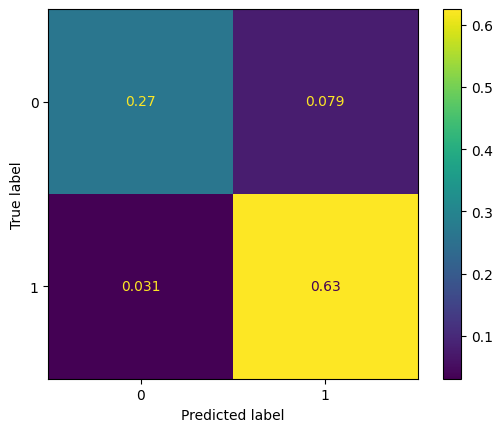

AUC Train: 0.9611450810710074
Gain from model: $162923

----------------------------------------------------


----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

           0       0.85      0.71      0.77       908
           1       0.86      0.93      0.89      1732

    accuracy                           0.86      2640
   macro avg       0.85      0.82      0.83      2640
weighted avg       0.86      0.86      0.85      2640



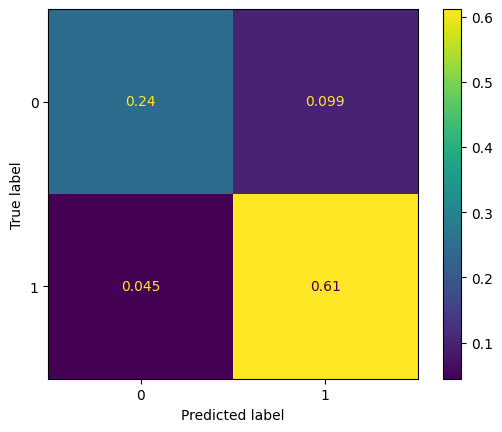

AUC Test: 0.9258235748949548
Gain from model: $37661

----------------------------------------------------



In [97]:
# Elección de features
fisel_features = [
    'rating_qty',
    'has_user_main_pairing',
    'rating',
    'user_body_diff',
    'user_acidity_diff',
    'user_sweetness_diff',
    'user_tannins_diff',
    'user_price_diff',
    'user_price_center',
    'price'
]

# Obtención de datos (X, y)
X = model_df_nocat[fisel_features]
y = model_df_nocat["liked"]

# Split de datos (train, test)
X_train, X_test, y_train, y_test = mod_prep.train_test_split(X, y, test_size=0.2, stratify=y)

# Nuevo pipeline con hiperparámetros optimizados
pipeline_fined = Pipeline([
    ("rf", RandomForestClassifier(
        max_depth=10,
        min_samples_split=9,
        min_samples_leaf=7,
        n_estimators=100,
        max_features='log2',
        bootstrap=True,
        criterion='entropy'
    ))
])

pipeline_fined.fit(X_train, y_train)

# Train
y_train_pred = pipeline_fined.predict(X_train)
y_train_proba = pipeline_fined.predict_proba(X_train)[:, 1]

cm_train = confusion_matrix(y_train, y_train_pred)
cm_train_norm = confusion_matrix(y_train, y_train_pred, normalize="all")
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train_norm, display_labels=pipeline_fined.named_steps["rf"].classes_)

print("\n----------------------------------------------------\n")
print("Train Metrics:\n")
print(classification_report(y_train, y_train_pred))
disp_train.plot()
plt.show()

print("AUC Train:", roc_auc_score(y_train, y_train_proba))

eco_score = mod_prep.economic_score(
    conf_matrix=cm_train,
    avg_tkt=avg_tkt,
    churn_like=churn_like,
    churn_dislike=churn_dislike
    )
print("Gain from model: $", round(eco_score), sep="")

print("\n----------------------------------------------------\n")

# Test
y_test_pred = pipeline_fined.predict(X_test)
y_test_proba = pipeline_fined.predict_proba(X_test)[:, 1]

cm_test = confusion_matrix(y_test, y_test_pred)
cm_test_norm = confusion_matrix(y_test, y_test_pred, normalize="all")
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test_norm, display_labels=pipeline_fined.named_steps["rf"].classes_)

print("\n----------------------------------------------------\n")
print("Test Metrics:\n")
print(classification_report(y_test, y_test_pred))
disp_test.plot()
plt.show()

print("AUC Test:", roc_auc_score(y_test, y_test_proba))

eco_score = mod_prep.economic_score(
    conf_matrix=cm_test,
    avg_tkt=avg_tkt,
    churn_like=churn_like,
    churn_dislike=churn_dislike
    )
print("Gain from model: $", round(eco_score), sep="")

print("\n----------------------------------------------------\n")


# 📈 Evaluación de Logistic Regression

## LR Base

*Creación de modelo base y CV*

In [32]:
X = model_df_nocat.drop(columns=["liked"])
y = model_df_nocat["liked"]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression())
        # n_neighbors=15,
        # weights="uniform",
        # algorithm="auto",
        # metric="euclidean"
        # ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef. Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef. Var
roc_auc,0.826196,0.006777,0.008203
accuracy,0.775270,0.006235,0.008042
precision_macro,0.762171,0.006862,0.009004
recall_macro,0.719654,0.009414,0.013082
f1_macro,0.731655,0.009195,0.012567


*Learning Curves*

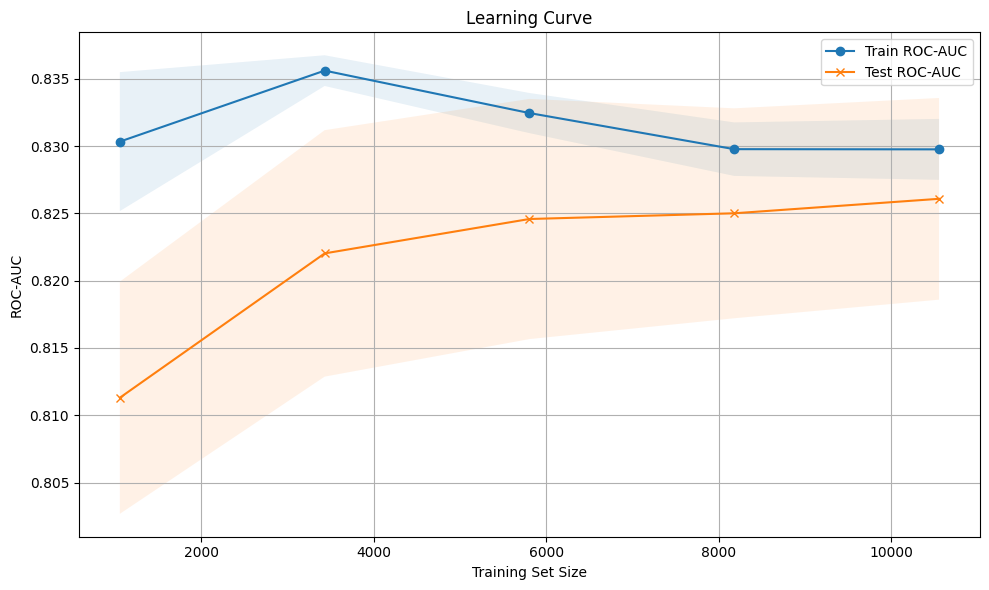

In [33]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

*Performance Curves*

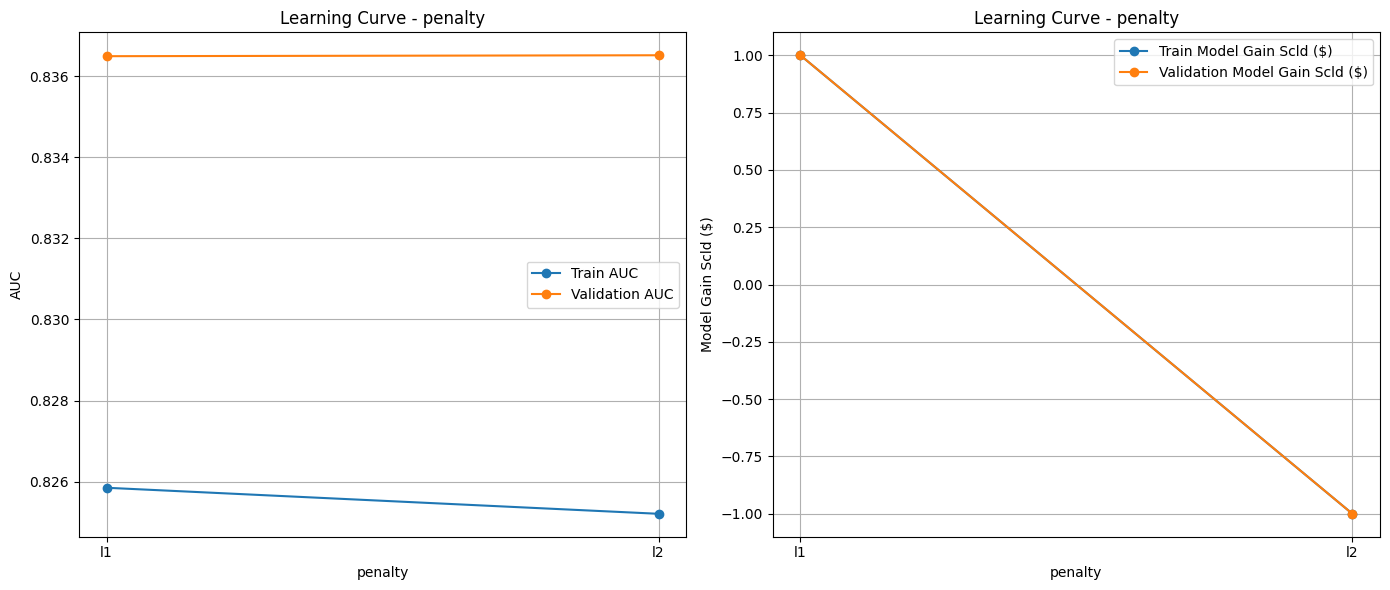

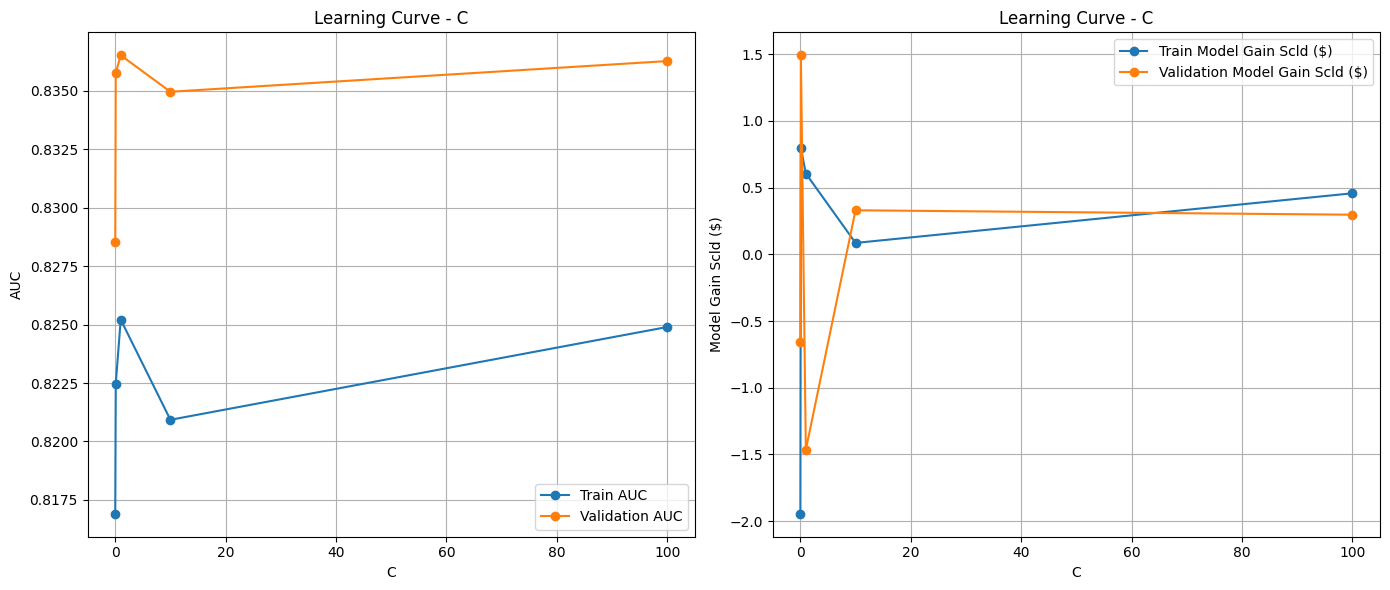

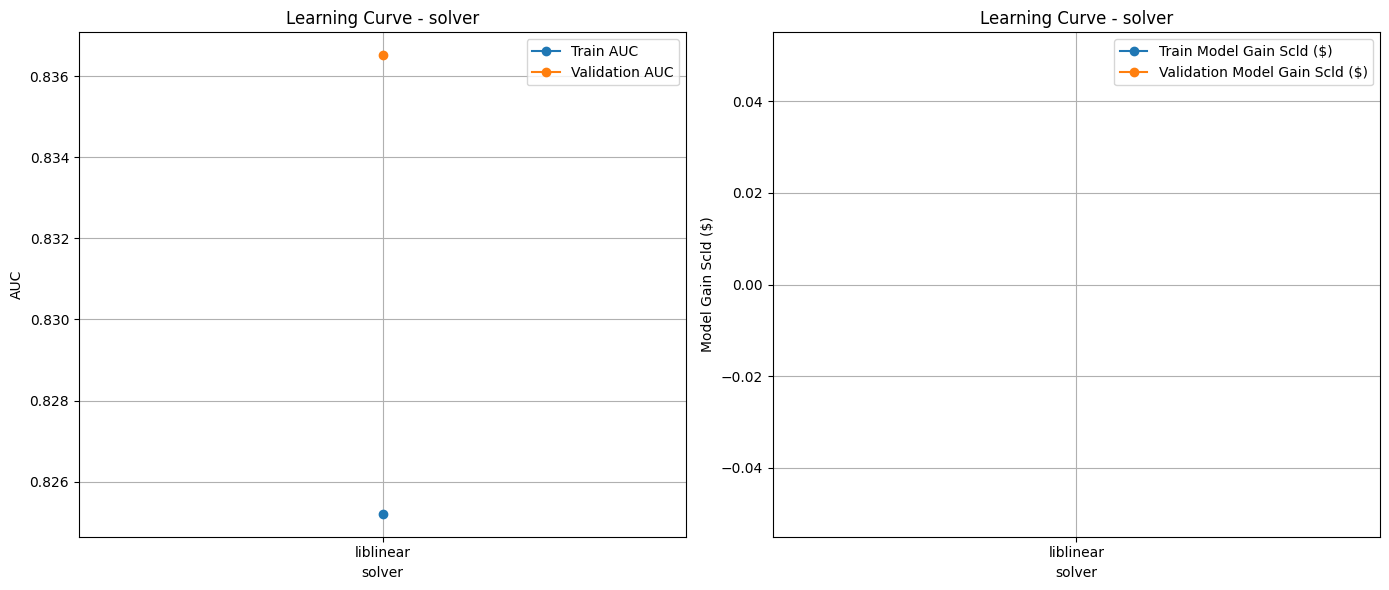

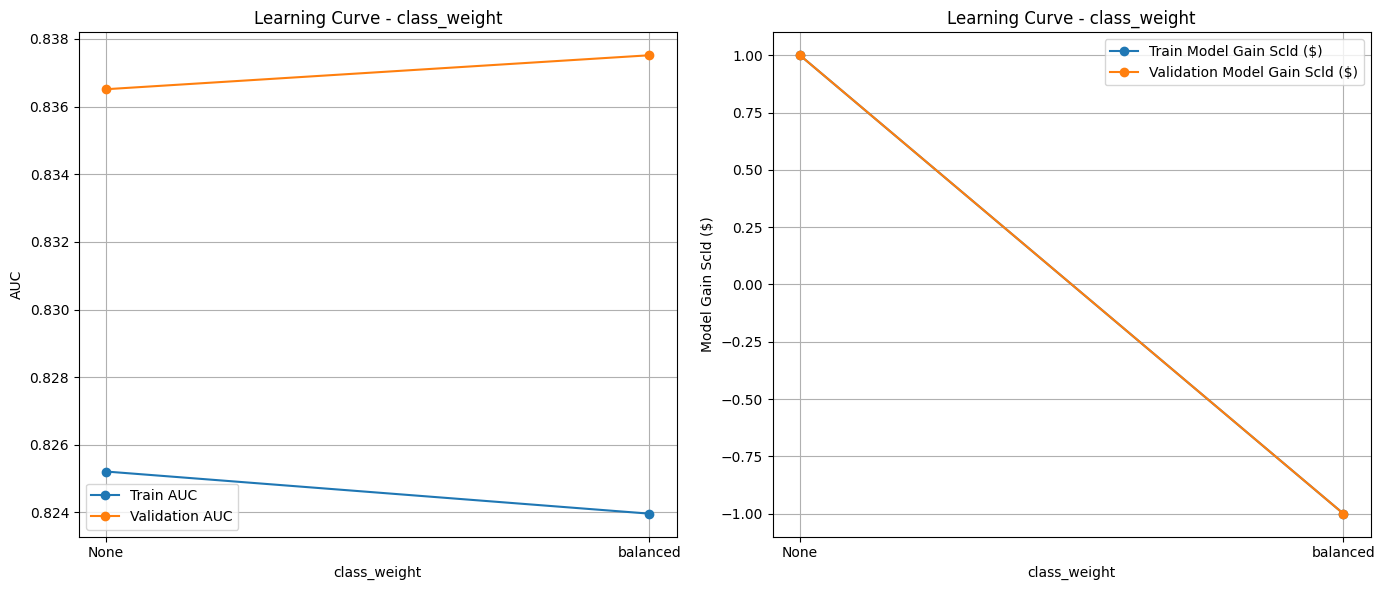

In [34]:
# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=None)

# Escalado
std_scaler = StandardScaler()
X_train_scld = std_scaler.fit_transform(X_train)
X_val_scld = std_scaler.transform(X_val)
X_test_scld = std_scaler.transform(X_test)

# Parámetros
params_dict =  {
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear"],
        "class_weight": [None, "balanced"],

        # "penalty": ["l1", "l2", None],
        # "C": [0.01, 0.1, 1, 10, 100],
        # "solver": ["saga"],
        # "class_weight": [None, "balanced"],

        # "penalty": ["l2", None],
        # "C": [0.01, 0.1, 1, 10, 100],
        # "solver": ["lbfgs", "sag", "newton-cg"],
        # "class_weight": [None, "balanced"],
    }

# Modelo
lr_base = LogisticRegression(solver=params_dict["solver"][0])


# Score Económico
eco_score_dict = {
    "avg_tkt": avg_tkt,
    "churn_like": churn_like,
    "churn_dislike": churn_dislike
}

# Ploteo de curvas de performance
mod_prep.plot_performance_curves(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    base_model=lr_base,
    params_dict=params_dict,
    eco_score_dict=eco_score_dict)

## LR SelectKBest

*Feature Selection*

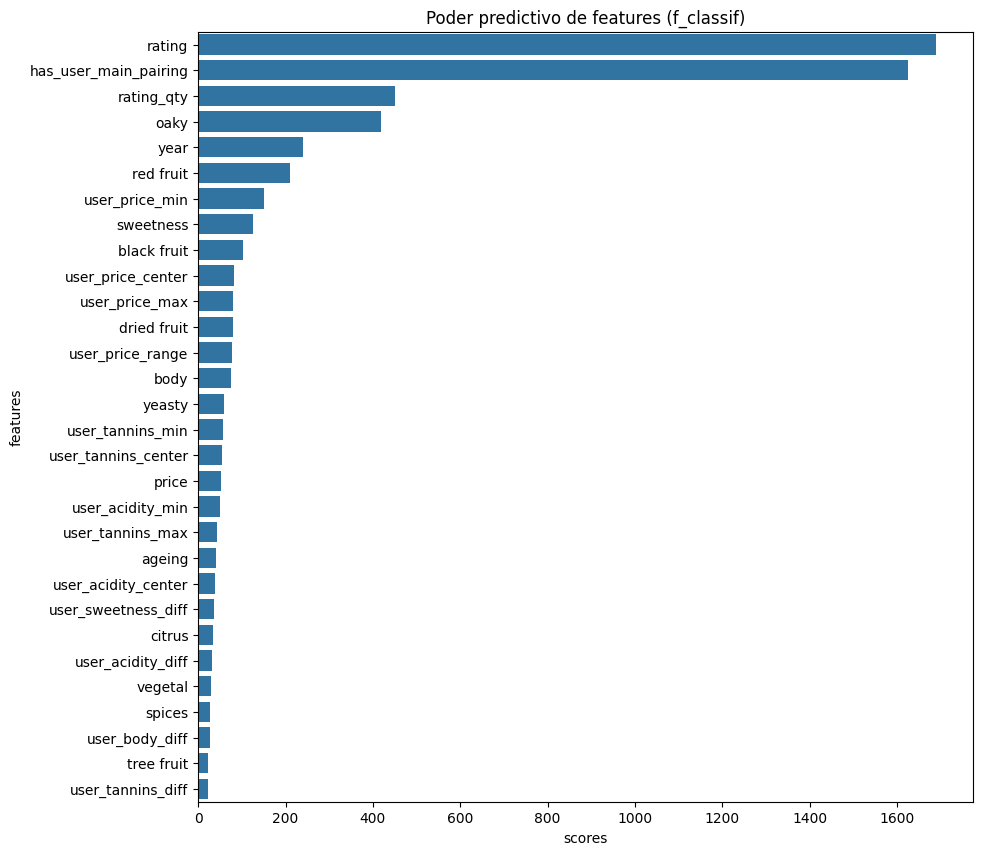

In [35]:
from sklearn.feature_selection import SelectKBest, f_classif

# Obtención de X e y
X = model_df_nocat.drop(columns=["liked"])
y = model_df_nocat["liked"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

# Train de selector
selector = SelectKBest(score_func=f_classif, k=30)
X_train_select = selector.fit_transform(X_train, y_train)

# Obtención de columnas y valores
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
scores = selector.scores_
pvalues = selector.pvalues_

# Formateo en Data Frame
features_scores = pd.DataFrame({
    "features": X.columns,
    "scores": scores,
    "pvalues": pvalues
})

# Selección de K
features_scores = features_scores[features_scores["features"].isin(selected_features)]
features_scores = features_scores.sort_values(by="scores", ascending=False)

# Gráfico
plt.figure(figsize=(10, 10))
sns.barplot(data=features_scores, y="features", x="scores")
plt.title("Poder predictivo de features (f_classif)")
plt.show()

In [36]:
selkbest_features = features_scores["features"].to_list()
drop_cols = ["user_price_center", "user_price_range", "user_tannins_center",
             "user_tannins_max", "user_tannins_diff", "user_acidity_center",
             "user_acidity_diff", "price",
             ]
add_cols = ["acidity", "tannins", "user_price_diff"]
selkbest_features = [f for f in selkbest_features if f not in drop_cols]
selkbest_features += [f for f in add_cols if f not in selkbest_features]
selkbest_features

['rating',
 'has_user_main_pairing',
 'rating_qty',
 'oaky',
 'year',
 'red fruit',
 'user_price_min',
 'sweetness',
 'black fruit',
 'user_price_max',
 'dried fruit',
 'body',
 'yeasty',
 'user_tannins_min',
 'user_acidity_min',
 'ageing',
 'user_sweetness_diff',
 'citrus',
 'vegetal',
 'spices',
 'user_body_diff',
 'tree fruit',
 'acidity',
 'tannins',
 'user_price_diff']

*Corr Matrix*

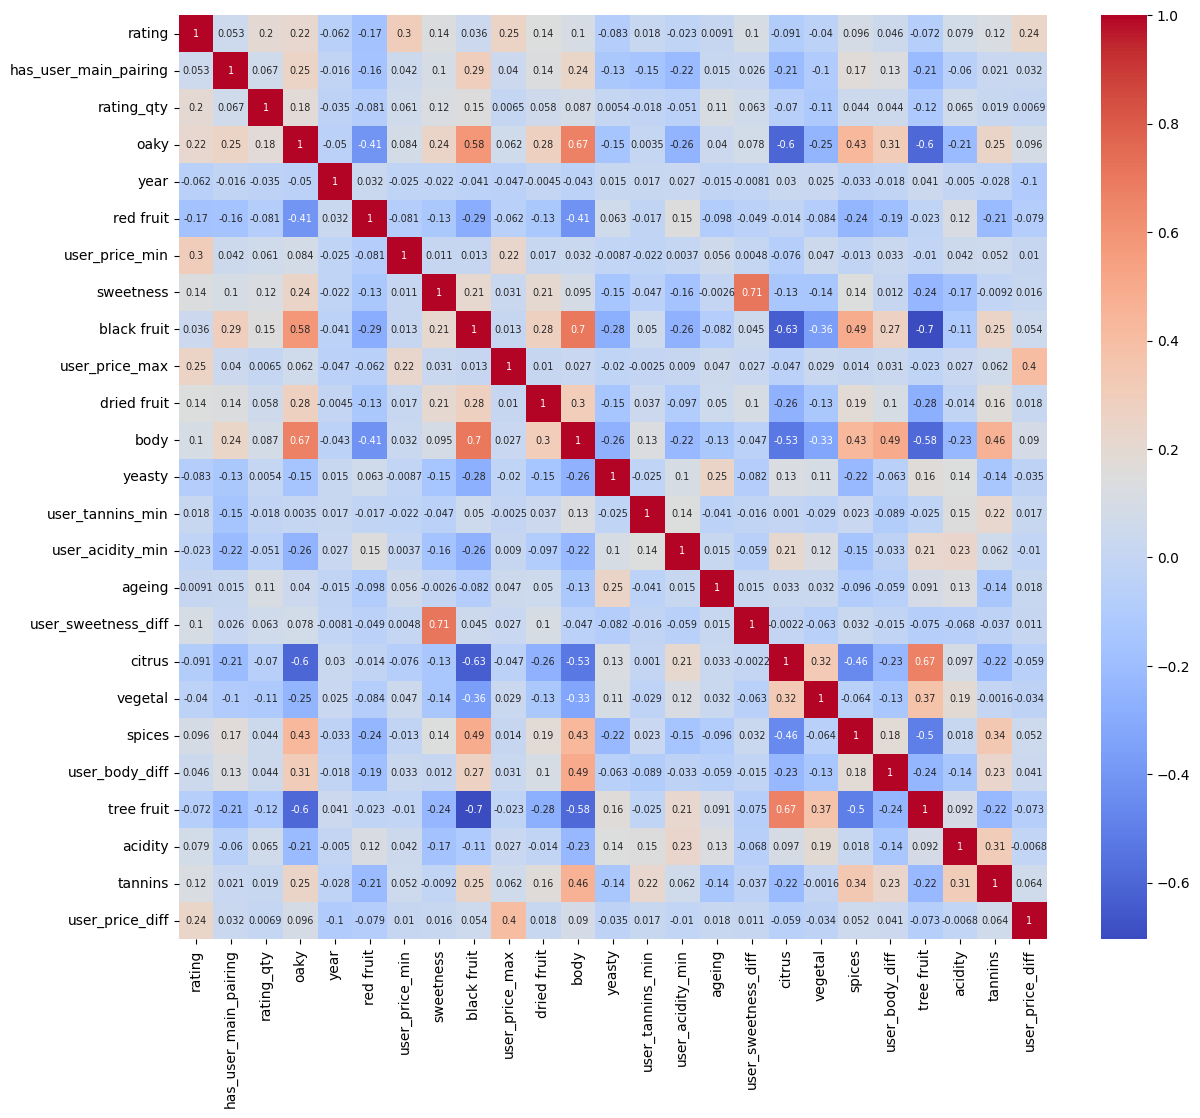

In [37]:
selkbest_rf_corr_matrix = model_df_nocat[selkbest_features].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(selkbest_rf_corr_matrix, cmap="coolwarm", annot=True, annot_kws={"fontsize": "x-small"})
plt.show()

*Evaluación con CV*

In [38]:
# X = model_df_nocat.drop(columns=["liked"])
X = model_df_nocat[selkbest_features]
y = model_df_nocat["liked"]

# Pipeline con oversampler y modelo para aplicarlo en cada Fold del CV
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression())
])

# Aplicación de cross validation y obtención de métricas
skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

# Resumen de métricas del CV
metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

# Media, Desvío Estándar y Coef Var
metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef Var
roc_auc,0.824530,0.005215,0.006325
accuracy,0.776254,0.002834,0.003651
precision_macro,0.764200,0.003759,0.004918
recall_macro,0.719828,0.003692,0.005129
f1_macro,0.732226,0.003740,0.005108


*Learning Curves*

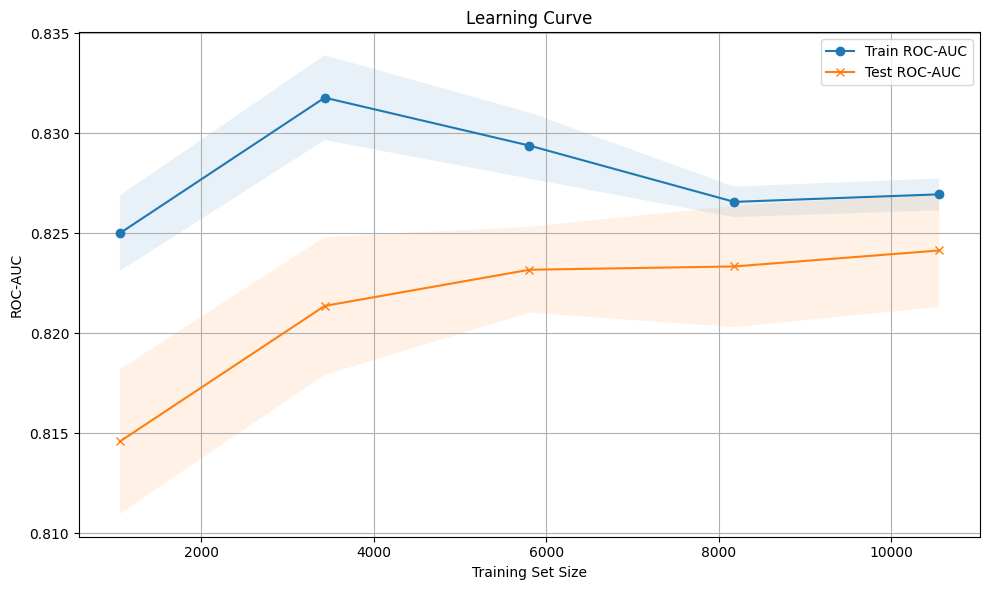

In [39]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

*Performance Curves*

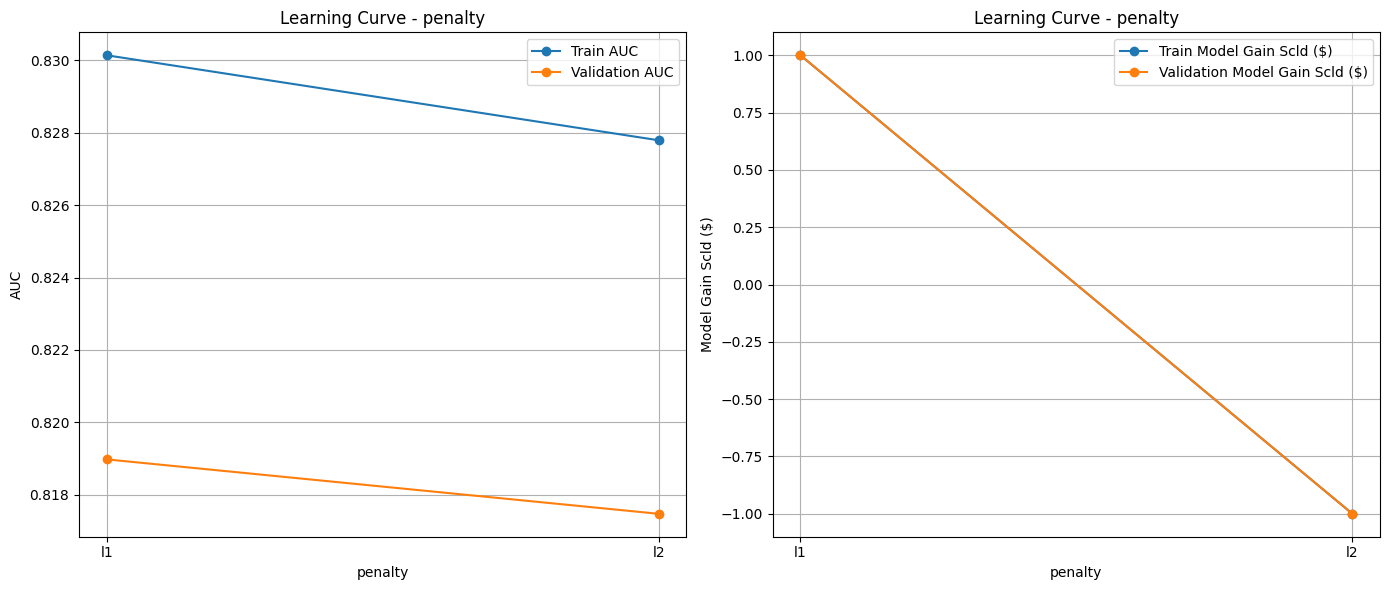

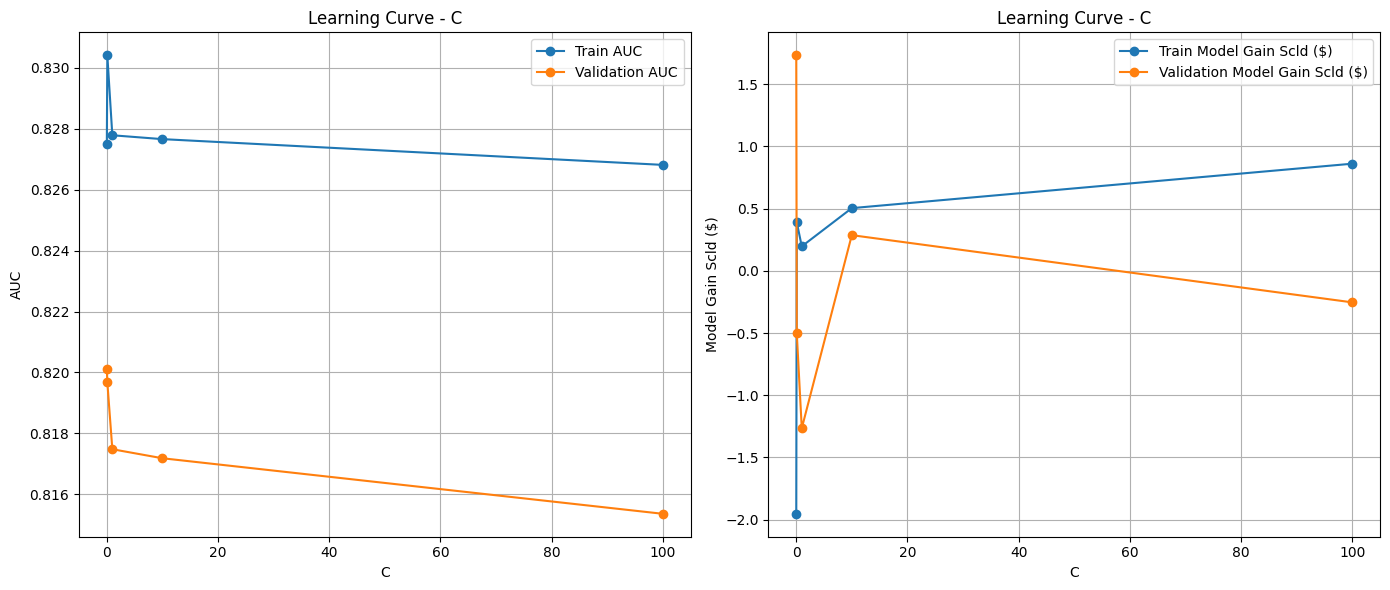

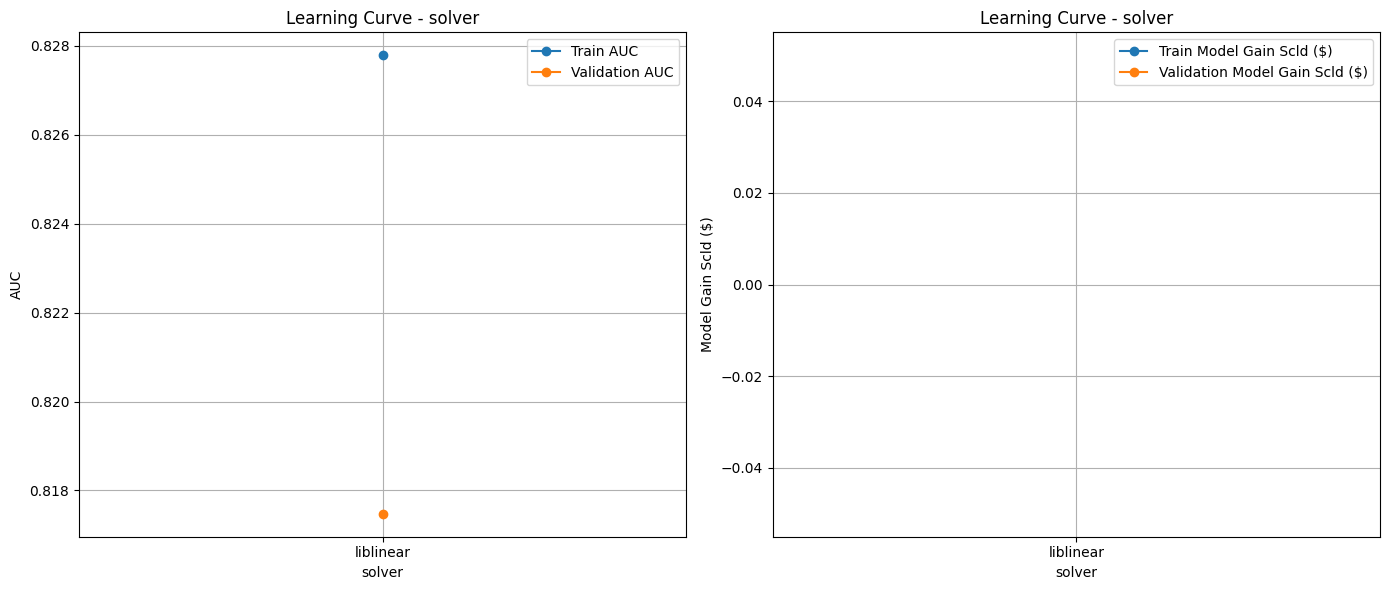

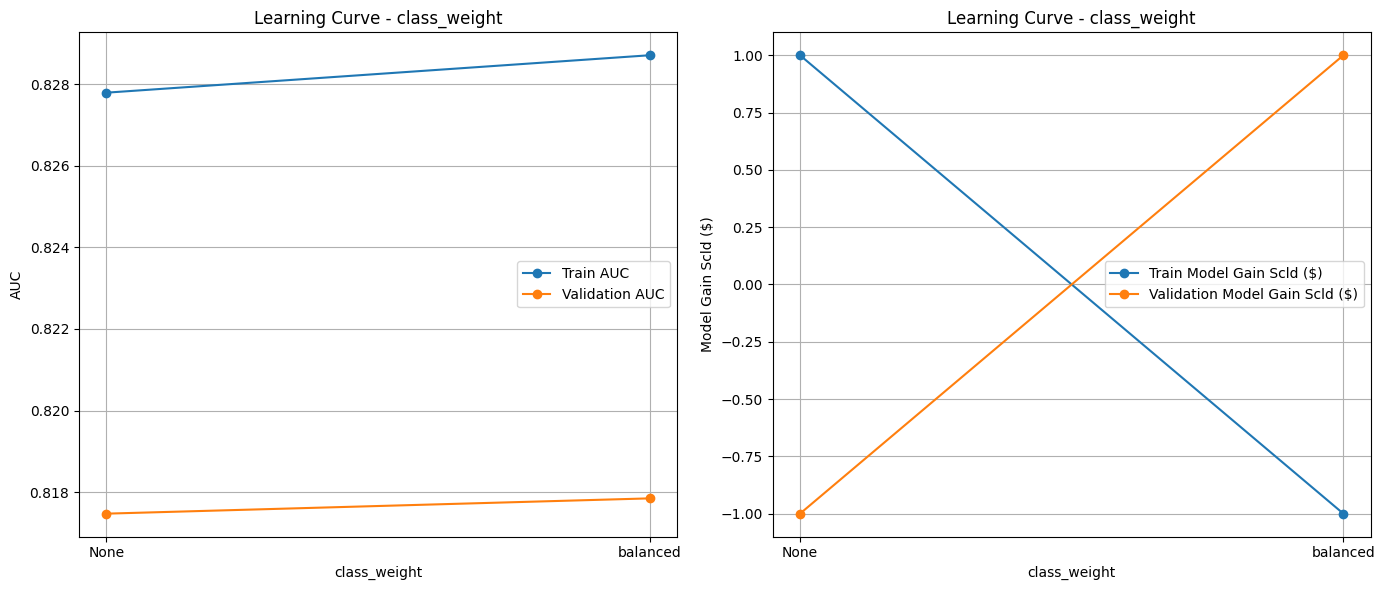

In [40]:
# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=None)

# Escalado
std_scaler = StandardScaler()
X_train_scld = std_scaler.fit_transform(X_train)
X_val_scld = std_scaler.transform(X_val)
X_test_scld = std_scaler.transform(X_test)

# Parámetros
params_dict =  {
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear"],
        "class_weight": [None, "balanced"],

        # "penalty": ["l1", "l2", None],
        # "C": [0.01, 0.1, 1, 10, 100],
        # "solver": ["saga"],
        # "class_weight": [None, "balanced"],

        # "penalty": ["l2", None],
        # "C": [0.01, 0.1, 1, 10, 100],
        # "solver": ["lbfgs", "sag", "newton-cg"],
        # "class_weight": [None, "balanced"],
    }

# Modelo
lr_base = LogisticRegression(solver=params_dict["solver"][0])


# Score Económico
eco_score_dict = {
    "avg_tkt": avg_tkt,
    "churn_like": churn_like,
    "churn_dislike": churn_dislike
}

# Ploteo de curvas de performance
mod_prep.plot_performance_curves(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    base_model=lr_base,
    params_dict=params_dict,
    eco_score_dict=eco_score_dict)

## LR Feature Importance Selected

*Feature Selection*

In [41]:
# Features tomadas de Evaluación de Random Forest
fisel_features = [
    'rating_qty',
    'has_user_main_pairing',
    'rating',
    'user_body_diff',
    'user_acidity_diff',
    'user_sweetness_diff',
    'user_tannins_diff',
    'user_price_diff',
    'user_price_center'
]

*Corr Matrix*

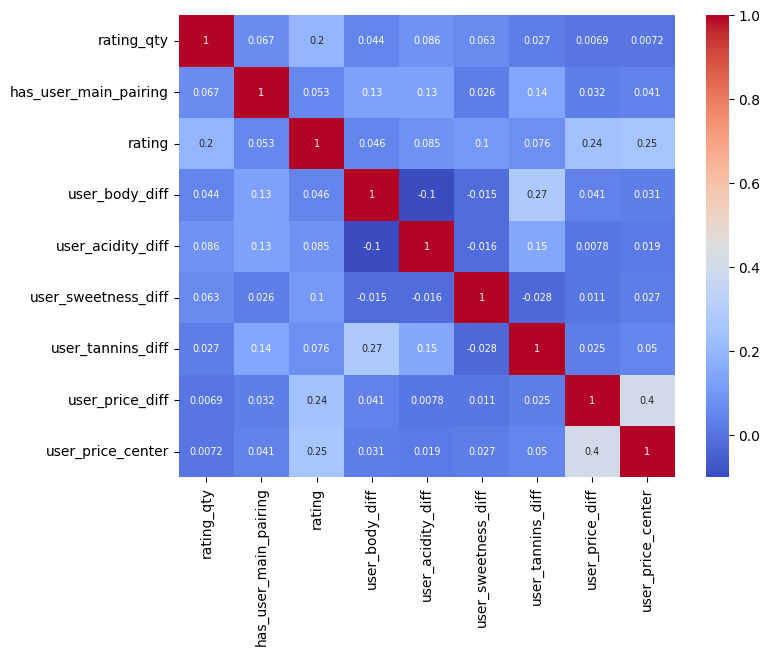

In [42]:
# Revisamos que no haya fuerte correlación (colinealidad)
fisel_corr_matrix = model_df_nocat[fisel_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(fisel_corr_matrix, cmap="coolwarm", annot=True, annot_kws={"fontsize": "x-small"})
plt.show()

*Evaluación con CV*

In [43]:
X = model_df_nocat[fisel_features]
y = model_df_nocat["liked"]

# Pipeline con oversampler y modelo para aplicarlo en cada Fold del CV
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression())
])

# Aplicación de cross validation y obtención de métricas
skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

# Resumen de métricas del CV
metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

# Media, Desvío Estándar y Coef Var
metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef Var
roc_auc,0.817130,0.006622,0.008104
accuracy,0.773451,0.004310,0.005572
precision_macro,0.760916,0.005763,0.007574
recall_macro,0.716173,0.005191,0.007248
f1_macro,0.728450,0.005445,0.007475


*Learning Curves*

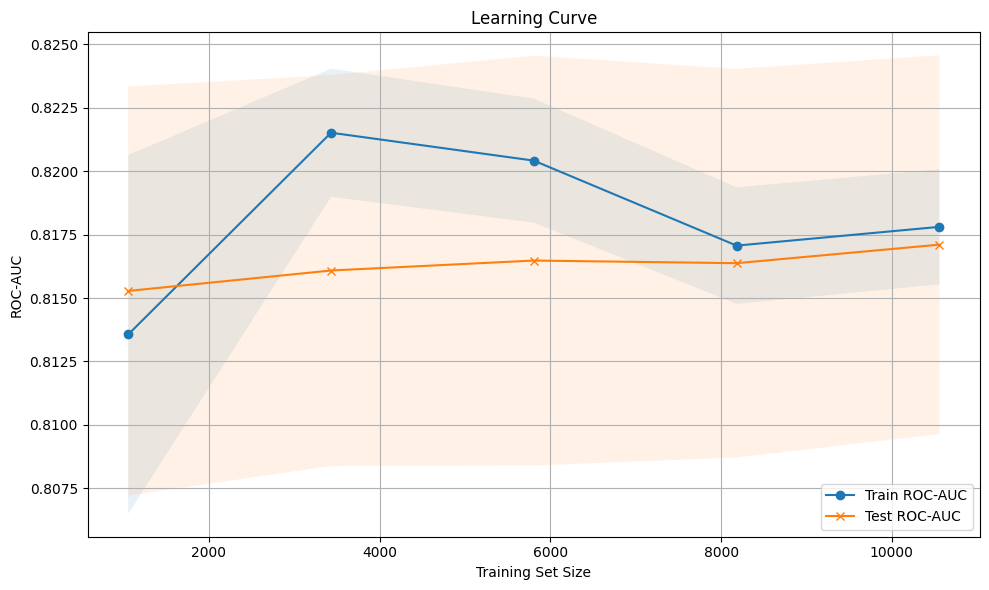

In [44]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

*Performance Curves*

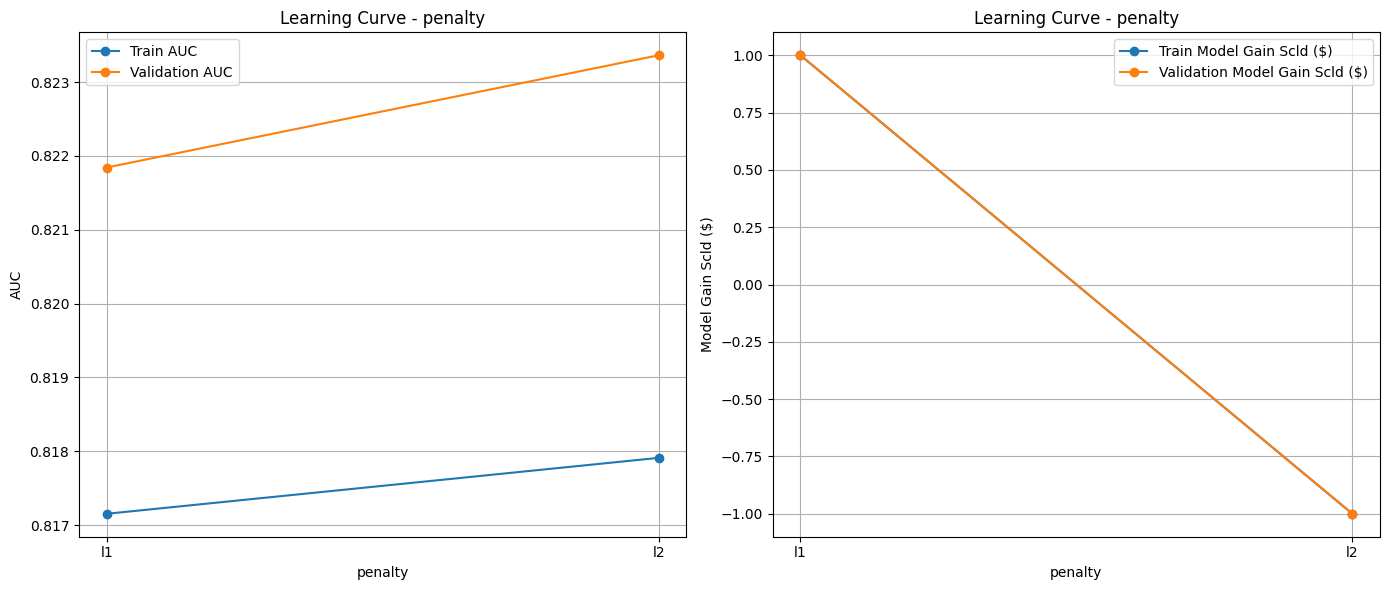

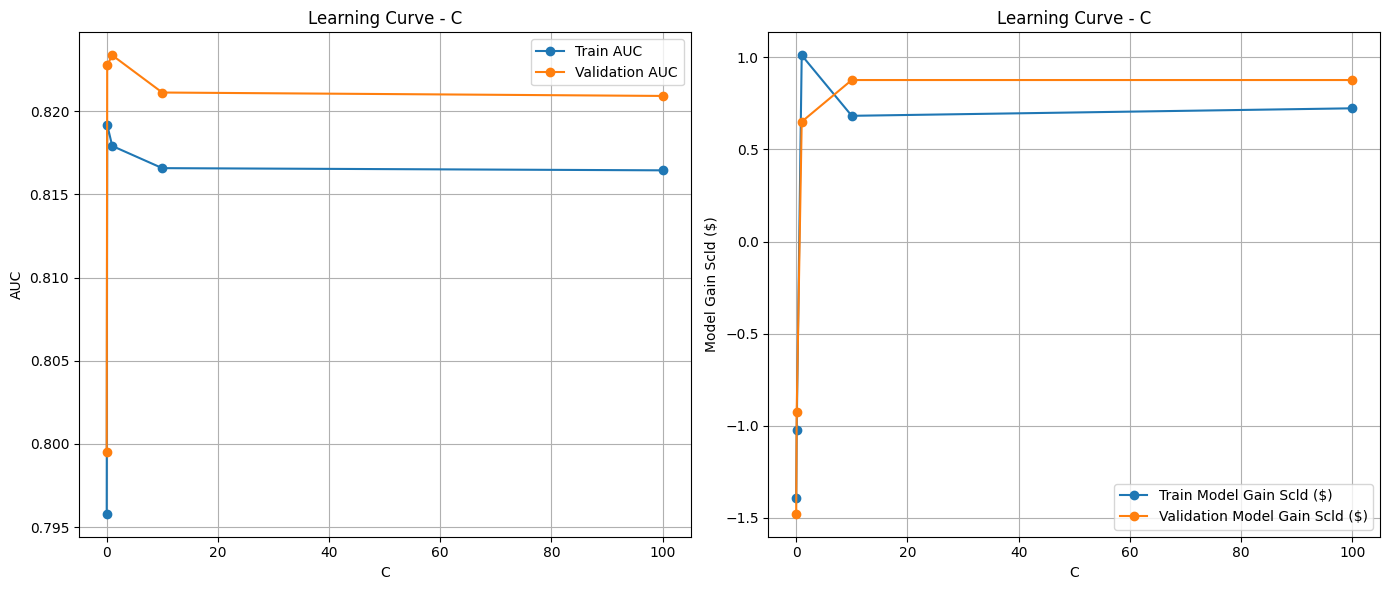

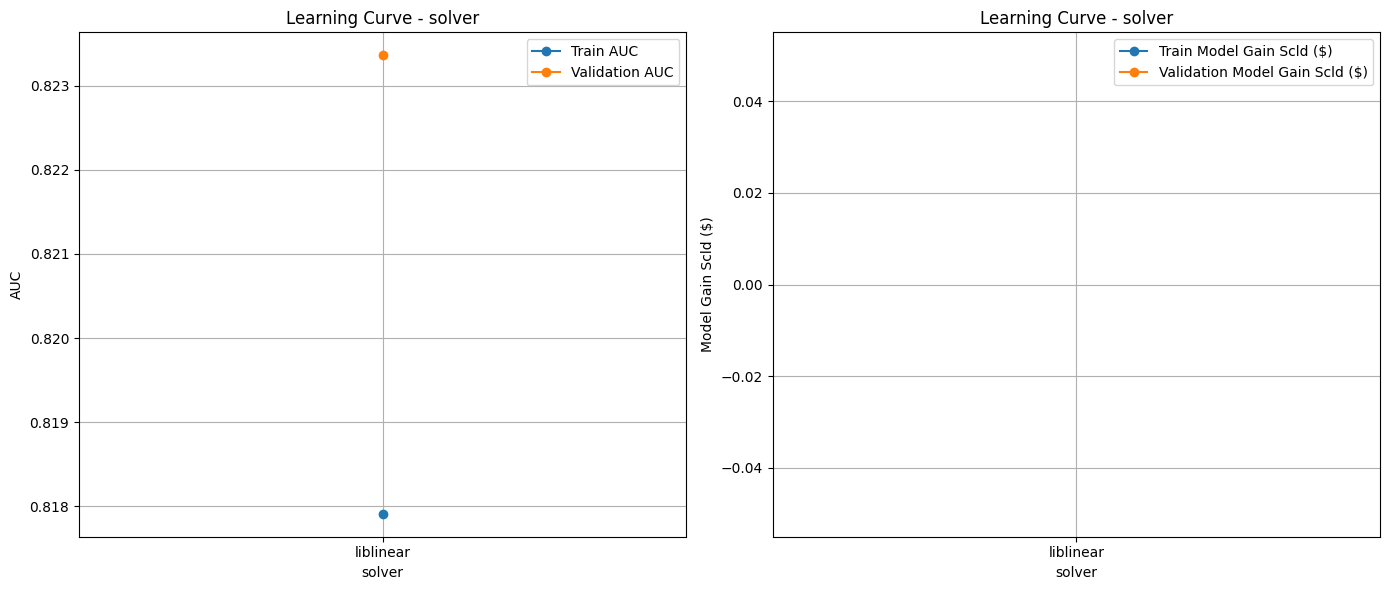

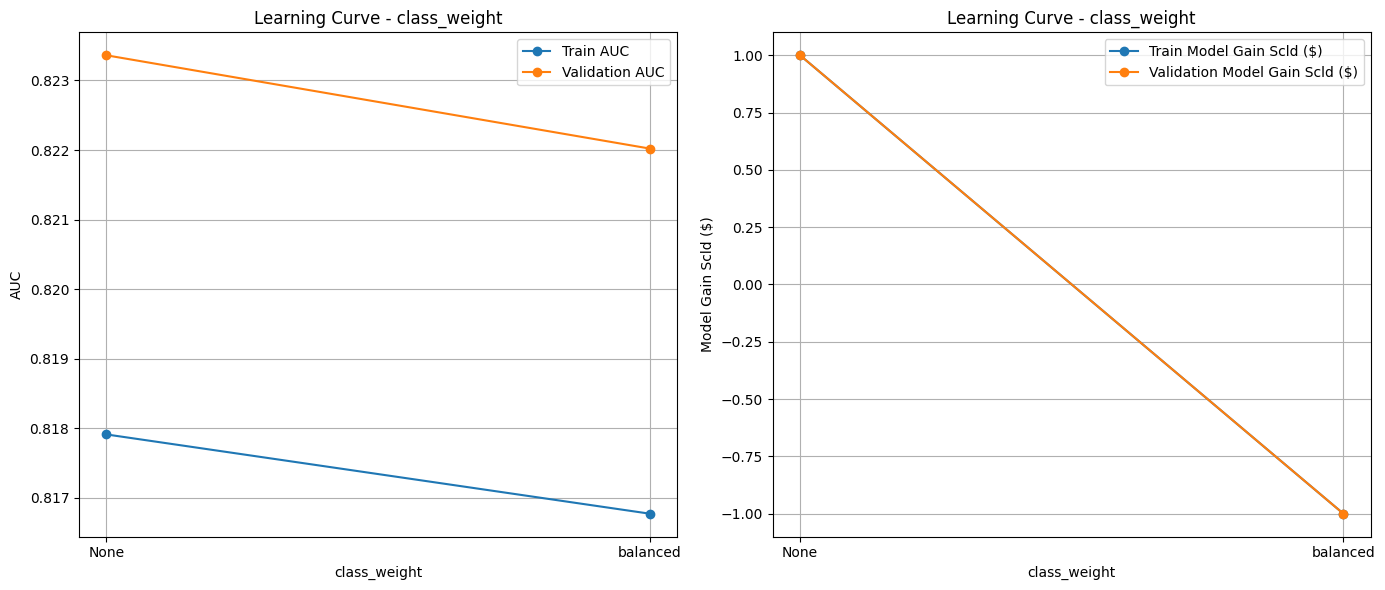

In [45]:
# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=None)

# Escalado
std_scaler = StandardScaler()
X_train_scld = std_scaler.fit_transform(X_train)
X_val_scld = std_scaler.transform(X_val)
X_test_scld = std_scaler.transform(X_test)

# Parámetros
params_dict =  {
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear"],
        "class_weight": [None, "balanced"],

        # "penalty": ["l1", "l2", None],
        # "C": [0.01, 0.1, 1, 10, 100],
        # "solver": ["saga"],
        # "class_weight": [None, "balanced"],

        # "penalty": ["l2", None],
        # "C": [0.01, 0.1, 1, 10, 100],
        # "solver": ["lbfgs", "sag", "newton-cg"],
        # "class_weight": [None, "balanced"],
    }

# Modelo
lr_base = LogisticRegression(solver=params_dict["solver"][0])


# Score Económico
eco_score_dict = {
    "avg_tkt": avg_tkt,
    "churn_like": churn_like,
    "churn_dislike": churn_dislike
}

# Ploteo de curvas de performance
mod_prep.plot_performance_curves(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    base_model=lr_base,
    params_dict=params_dict,
    eco_score_dict=eco_score_dict)

# Finetunning LR

In [56]:
# Creación de score económico personalizado
def economic_score_scorer(y_true, y_pred):
    conf = confusion_matrix(y_true, y_pred)
    return mod_prep.economic_score(
        conf_matrix=conf,
        avg_tkt=avg_tkt,
        churn_like=churn_like,
        churn_dislike=churn_dislike
    )

custom_scorer = make_scorer(economic_score_scorer, greater_is_better=True)

In [58]:
# Búsqueda de parámetros con GridSearch

# Elección de features
selected_k_best_features = ['rating',
 'has_user_main_pairing',
 'rating_qty',
 'oaky',
 'year',
 'red fruit',
 'user_price_min',
 'sweetness',
 'black fruit',
 'user_price_max',
 'dried fruit',
 'body',
 'yeasty',
 'user_tannins_min',
 'user_acidity_min',
 'ageing',
 'user_sweetness_diff',
 'citrus',
 'vegetal',
 'spices',
 'user_body_diff',
 'tree fruit',
 'acidity',
 'tannins',
 'user_price_diff']

# Obtención de datos (X, y)
X = model_df_nocat[selected_k_best_features]
y = model_df_nocat["liked"]

# Split de datos (train, test)
X_train, X_test, y_train, y_test = mod_prep.train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

# Creación de Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression())
])

# Cross Validation Stratified
skf = StratifiedKFold(n_splits=5, shuffle=True)

# Parametros del Grid
param_distribs= {
    "lr__penalty": ["l1", "l2"],
    "lr__C": [0.01, 0.1, 1, 10, 100],
    "lr__solver": ["liblinear"],
    "lr__class_weight": [None, "balanced"],
}

# Scoring
scoring_metrics = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "economic_scorer": custom_scorer
}

# Random Search
grid_search = GridSearchCV(
    pipeline,
    param_distribs,
    scoring=scoring_metrics,
    refit="roc_auc",
    cv=skf
)

grid_search.fit(X_train, y_train)

# Resultados
grid_results = pd.DataFrame(grid_search.cv_results_)
summary_results = grid_results[["mean_test_accuracy", "mean_test_roc_auc", "mean_test_economic_scorer", "param_lr__penalty", "param_lr__C", "param_lr__solver", "param_lr__class_weight"]].sort_values(by="mean_test_roc_auc", ascending=False)
summary_results = summary_results.reset_index(drop=True)
summary_results

,mean_test_accuracy,mean_test_roc_auc,mean_test_economic_scorer,param_lr__penalty,param_lr__C,param_lr__solver,param_lr__class_weight
0,0.777135,0.825515,24577.373652,l1,1.00,liblinear,None
1,0.776756,0.825503,24551.236982,l1,10.00,liblinear,None
2,0.776756,0.825503,24551.236982,l2,100.00,liblinear,None
3,0.776756,0.825503,24551.236982,l1,100.00,liblinear,None
4,0.776756,0.825501,24551.236982,l2,10.00,liblinear,None
5,0.776756,0.825476,24551.236982,l2,1.00,liblinear,None
6,0.777135,0.825431,24581.259085,l1,0.10,liblinear,None
7,0.776945,0.825281,24565.033636,l2,0.10,liblinear,None
8,0.762360,0.824647,23995.264091,l1,100.00,liblinear,balanced
9,0.762360,0.824647,23995.264091,l2,100.00,liblinear,balanced


# Evaluación Final LR


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

           0       0.74      0.54      0.63      3632
           1       0.79      0.90      0.84      6926

    accuracy                           0.78     10558
   macro avg       0.77      0.72      0.73     10558
weighted avg       0.77      0.78      0.77     10558



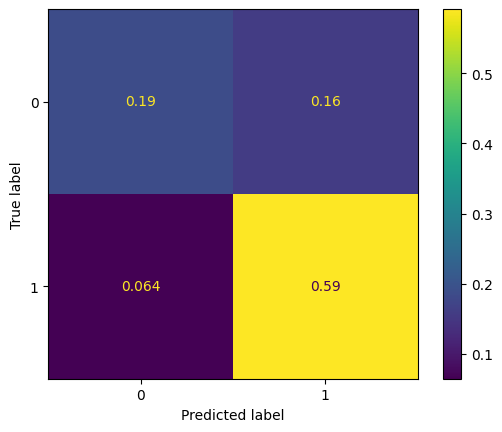

AUC Train: 0.8231838211629294
Gain from model: $123243

----------------------------------------------------


----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

           0       0.74      0.51      0.61       908
           1       0.78      0.90      0.84      1732

    accuracy                           0.77      2640
   macro avg       0.76      0.71      0.72      2640
weighted avg       0.77      0.77      0.76      2640



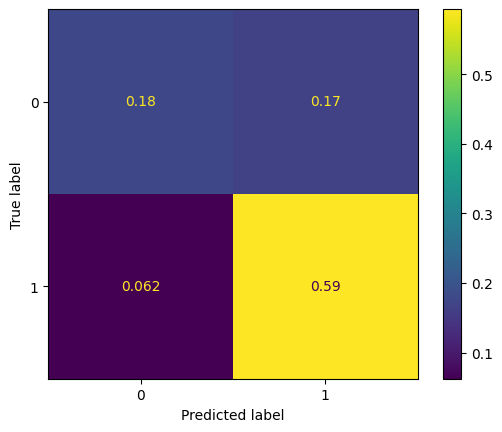

AUC Test: 0.8280202409172762
Gain from model: $30207

----------------------------------------------------



In [60]:
# Elección de features
selected_k_best_features = ['rating',
 'has_user_main_pairing',
 'rating_qty',
 'oaky',
 'year',
 'red fruit',
 'user_price_min',
 'sweetness',
 'black fruit',
 'user_price_max',
 'dried fruit',
 'body',
 'yeasty',
 'user_tannins_min',
 'user_acidity_min',
 'ageing',
 'user_sweetness_diff',
 'citrus',
 'vegetal',
 'spices',
 'user_body_diff',
 'tree fruit',
 'acidity',
 'tannins',
 'user_price_diff']

# Obtención de datos (X, y)
X = model_df_nocat[selected_k_best_features]
y = model_df_nocat["liked"]

# Split de datos (train, test)
X_train, X_test, y_train, y_test = mod_prep.train_test_split(X, y, test_size=0.2, stratify=y)

# Nuevo pipeline con hiperparámetros optimizados
pipeline_fined = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        penalty="l1",
        C=0.1,
        solver="liblinear",
        class_weight=None
    ))
])

pipeline_fined.fit(X_train, y_train)

# Train
y_train_pred = pipeline_fined.predict(X_train)
y_train_proba = pipeline_fined.predict_proba(X_train)[:, 1]

cm_train = confusion_matrix(y_train, y_train_pred)
cm_train_norm = confusion_matrix(y_train, y_train_pred, normalize="all")
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train_norm, display_labels=pipeline_fined.named_steps["lr"].classes_)

print("\n----------------------------------------------------\n")
print("Train Metrics:\n")
print(classification_report(y_train, y_train_pred))
disp_train.plot()
plt.show()

print("AUC Train:", roc_auc_score(y_train, y_train_proba))

eco_score = mod_prep.economic_score(
    conf_matrix=cm_train,
    avg_tkt=avg_tkt,
    churn_like=churn_like,
    churn_dislike=churn_dislike
    )
print("Gain from model: $", round(eco_score), sep="")

print("\n----------------------------------------------------\n")

# Test
y_test_pred = pipeline_fined.predict(X_test)
y_test_proba = pipeline_fined.predict_proba(X_test)[:, 1]

cm_test = confusion_matrix(y_test, y_test_pred)
cm_test_norm = confusion_matrix(y_test, y_test_pred, normalize="all")
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test_norm, display_labels=pipeline_fined.named_steps["lr"].classes_)

print("\n----------------------------------------------------\n")
print("Test Metrics:\n")
print(classification_report(y_test, y_test_pred))
disp_test.plot()
plt.show()

print("AUC Test:", roc_auc_score(y_test, y_test_proba))

eco_score = mod_prep.economic_score(
    conf_matrix=cm_test,
    avg_tkt=avg_tkt,
    churn_like=churn_like,
    churn_dislike=churn_dislike
    )
print("Gain from model: $", round(eco_score), sep="")

print("\n----------------------------------------------------\n")
